In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from typing import NamedTuple

import numpy as np
from numpy.typing import NDArray
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera, codedmask, count, decode
from bloodmoon.optim import model_shadowgram, model_sky

import darksun as ds
from darksun.types import Tag
from darksun.data import Log, DataLoader
from darksun.optim import bkg_smoothing
from darksun.show import slices_plot

from var import sky_variance, sky_significance


class Candidate(NamedTuple):
    """
    Source candidate main info container.

    Attributes:
        shift_x (float):
            Coded-mask camera local frame sky-coord along the x-axis [mm].
        shift_y (float):
            Coded-mask camera local frame sky-coord along the y-axis [mm].
        fluence (float):
            Observed candidate fluence [ph].
        snr (float):
            Candidate significance [adim].
    """
    shift_x: float
    shift_y: float
    fluence: float
    snr: float


def source_profile_during_IROS(
    candidates: tuple[Candidate],
    true_sky: NDArray,
    variance: NDArray,
    lock_source: Tag | tuple[Tag],
    crp: tuple[int, int],
    camera: CodedMaskCamera,
    *,
    vignetting: bool = True,
    psfy: bool = True,
) -> None:
    """
    Displays the locked sources profile behaviour during the IROS reconstruction.
    """
    true_sky_ = true_sky.copy()
    lock_source_ = (lock_source,) if isinstance(lock_source, Tag) else lock_source

    for idx, (sx, sy, f, _) in enumerate(candidates):

        # simulate source
        modeled = model_sky(
            camera=camera,
            shift_x=sx,
            shift_y=sy,
            fluence=f,
            vignetting=vignetting,
            psfy=psfy,
        ).astype(np.int32)

        # locked sources profiles before subtraction (sky and significance)
        for tag in lock_source_:
            slices_plot(
                sky=true_sky_,
                pos=(tag.y, tag.x),
                crp=crp,
                source=f'{tag.ID} it. {idx}',
                ylabel='counts [ph]',
            )
            #slices_plot(
            #    sky=sky_significance(true_sky_, variance),
            #    pos=(tag.y, tag.x),
            #    crp=crp,
            #    source=f'{tag.ID} it. {idx}',
            #    ylabel='significance',
            #    cameraID='SNR',
            #)
        
        # remove source from True sky
        true_sky_ -= modeled
    
    for tag in lock_source_:
        slices_plot(
            sky=true_sky_,
            pos=(tag.y, tag.x),
            crp=crp,
            source=f'{tag.ID} it. {idx + 1}',
            ylabel='counts [ph]',
        )
        #slices_plot(
        #    sky=sky_significance(true_sky_, variance),
        #    pos=(tag.y, tag.x),
        #    crp=crp,
        #    source=f'{tag.ID} it. {idx + 1}',
        #    ylabel='significance',
        #    cameraID='SNR',
        #)

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


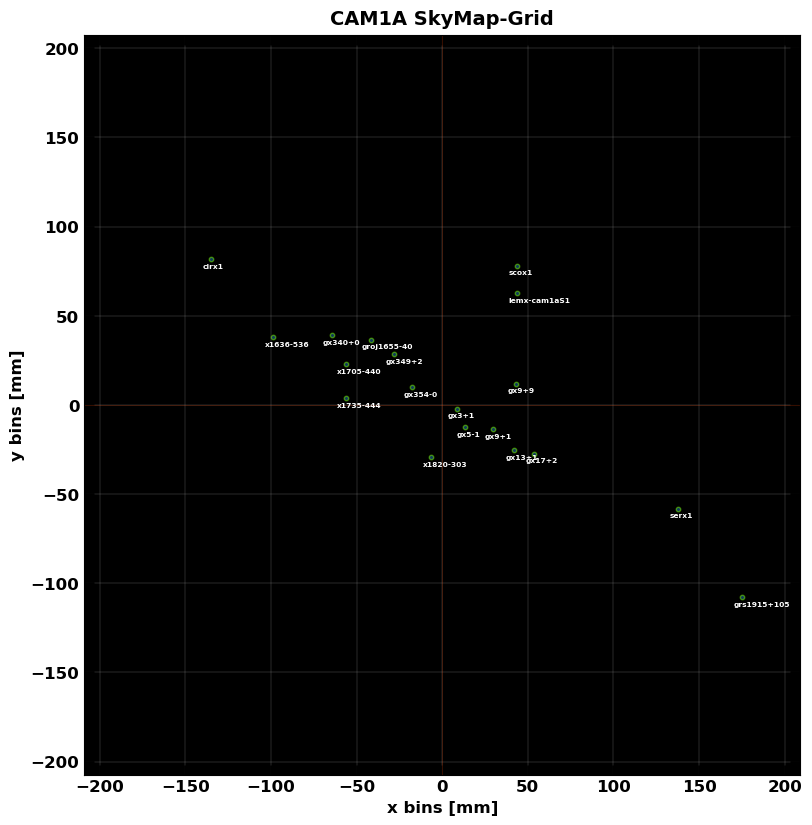

,CAM1A,CAM1A SNR,CAM1A SX,CAM1A SY
0,scox1,749.152433,43.909233,78.034729
1,gx5-1,78.307137,13.525157,-12.530141
2,gx349+2,60.073791,-28.163703,28.647628
3,gx17+2,51.405661,53.591681,-27.281381
4,gx9+1,46.722344,29.852447,-13.424243
5,gx340+0,34.820543,-64.630984,39.059065
6,groj1655-40,29.005915,-41.782597,36.564674
7,gx3+1,26.115363,8.412702,-2.092406
8,gx13+1,25.410615,41.882117,-25.187341
9,x1820-303,24.144542,-6.263894,-29.313634


In [2]:
skyfield = "GalacticCenter"
mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

VIGNETTING = True
PSFY = False
UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
#cam_b = "cam1b"
dataset = 'detected'

filepaths = simulation_files(simul_data)
sdlA = ds.get_data(filepaths[cam_a][dataset])
catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
#simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, _ = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")


ds.skyfield_map(
    log=log_camA,
    camera=wfm,
)
pd.DataFrame(
    {
        log_camA.name: log_camA.log['ID'],
        f"{log_camA.name} SNR": log_camA.log['snr'],
        f"{log_camA.name} SX": log_camA.log['shift_x'],
        f"{log_camA.name} SY": log_camA.log['shift_y'],
    },
)

In [3]:
_UP_TO = 19

candidates = tuple(
    Candidate(sx, sy, f, signf) for sx, sy, f, signf in zip(
        log_camA.log['shift_x'][:_UP_TO],
        log_camA.log['shift_y'][:_UP_TO],
        log_camA.log['fluence'][:_UP_TO],
        log_camA.log['snr'][:_UP_TO],
    )
)

print(
    f"Selected sources: {len(candidates)}\n"
    f"{log_camA.log['ID'][:_UP_TO]}"
)

Selected sources: 19
['scox1', 'gx5-1', 'gx349+2', 'gx17+2', 'gx9+1', 'gx340+0', 'groj1655-40', 'gx3+1', 'gx13+1', 'x1820-303', 'gx9+9', 'cirx1', 'x1705-440', 'x1735-444', 'gx354-0', 'grs1915+105', 'x1636-536', 'serx1', 'lemx-cam1aS1']


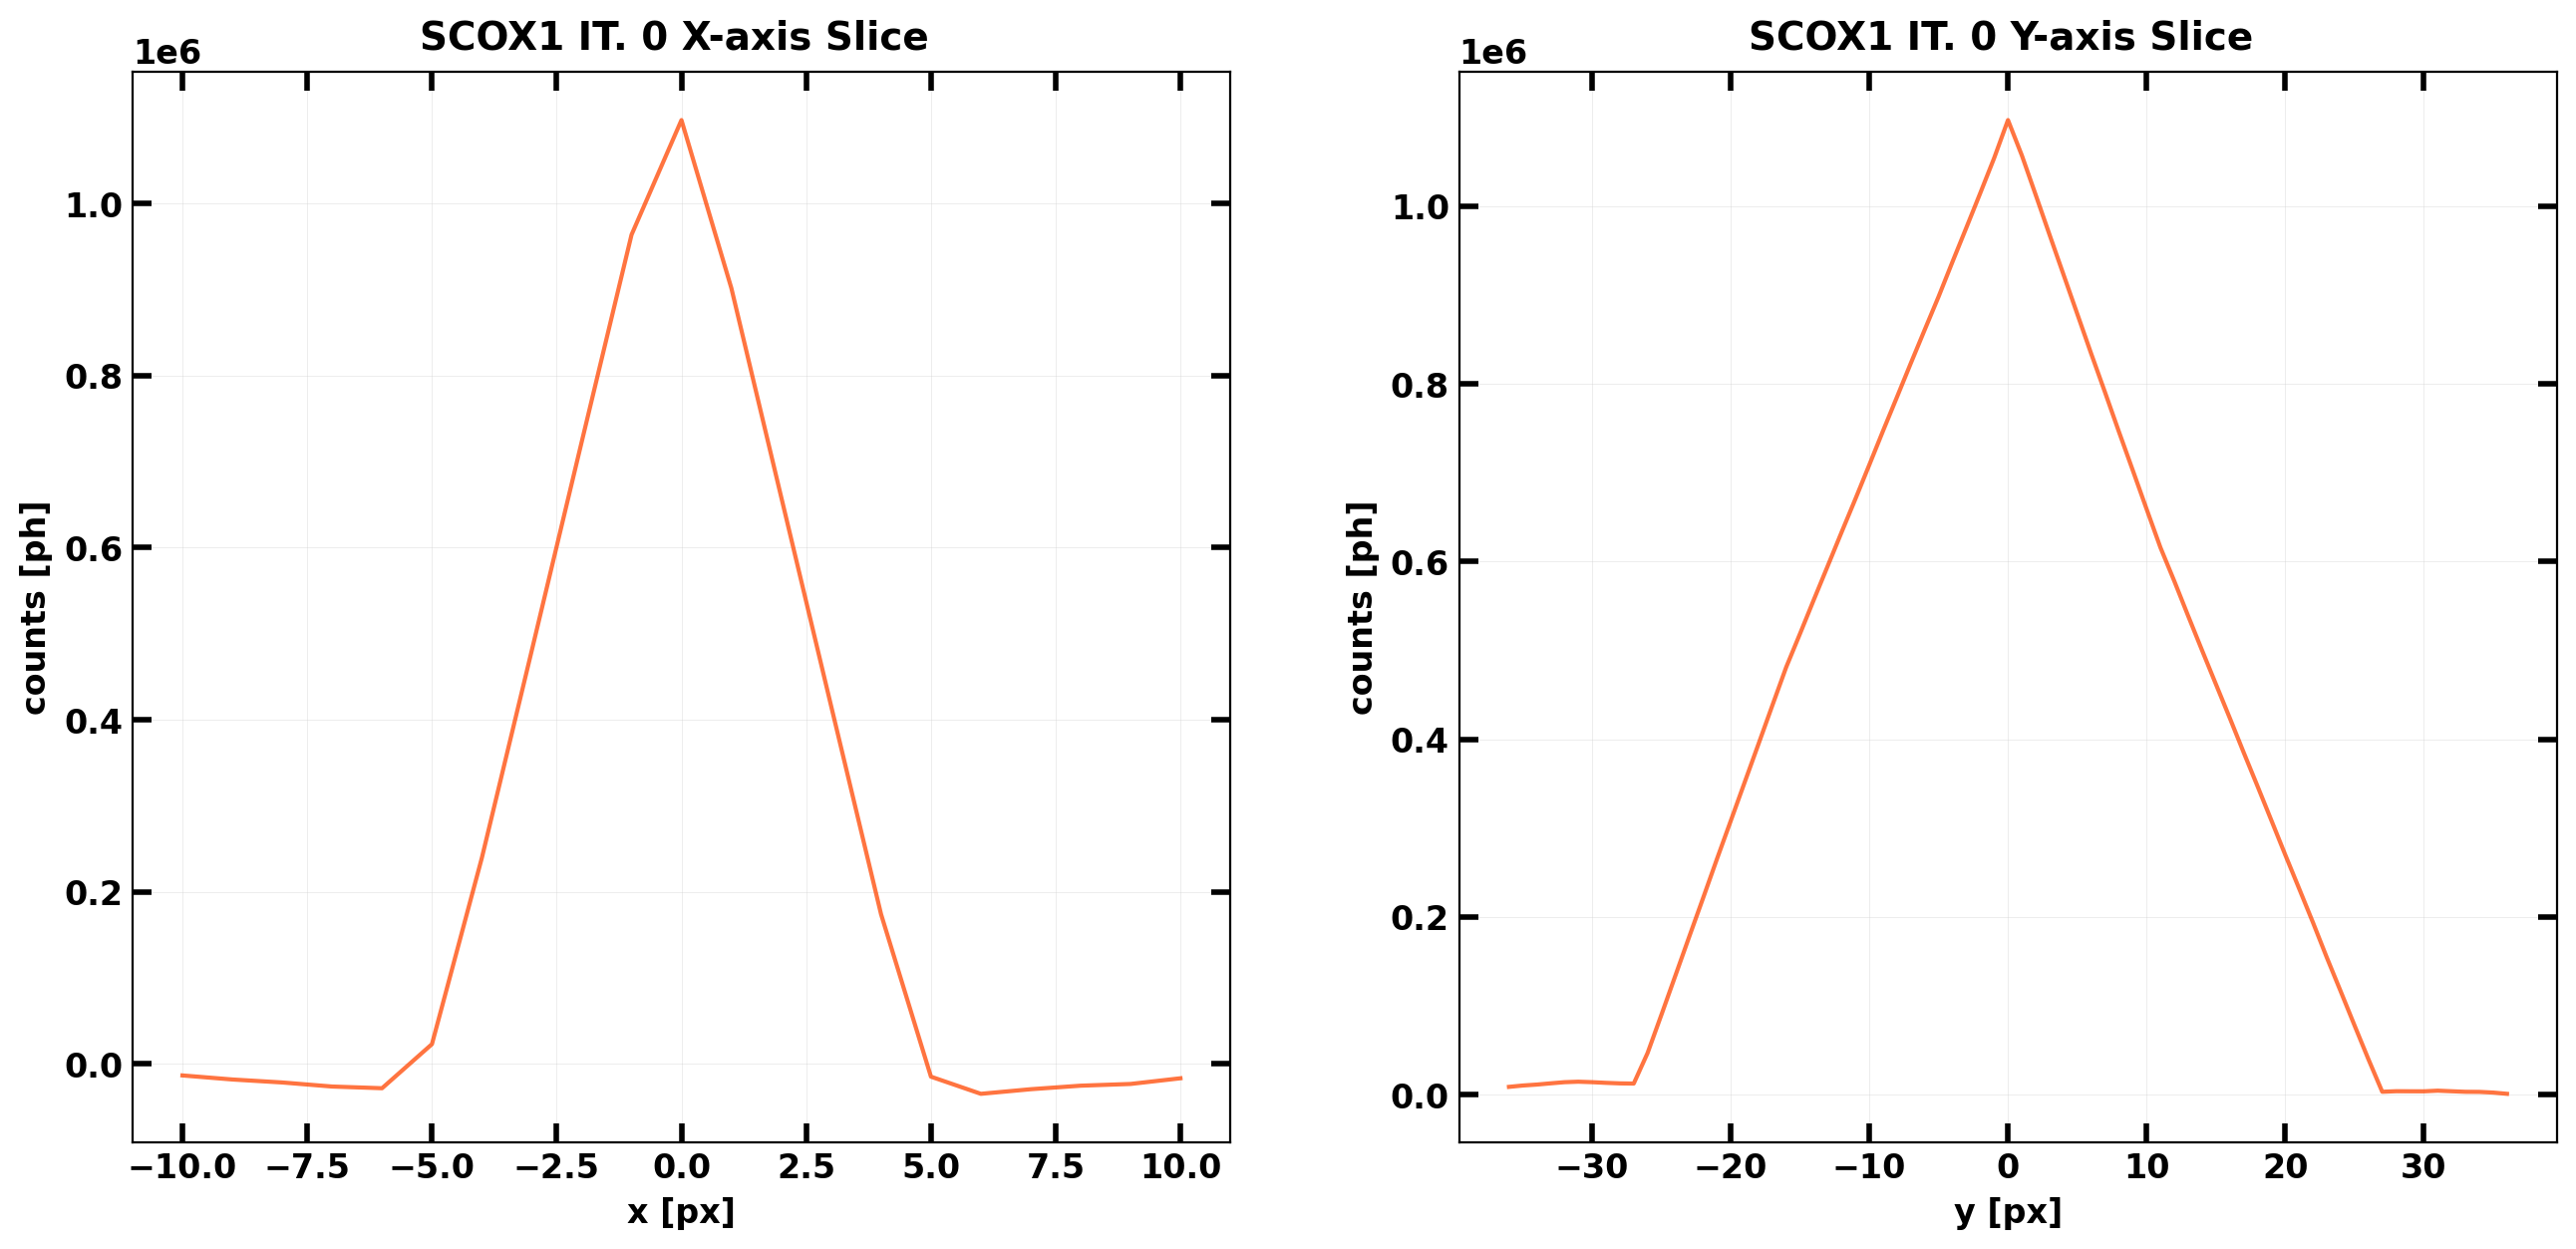

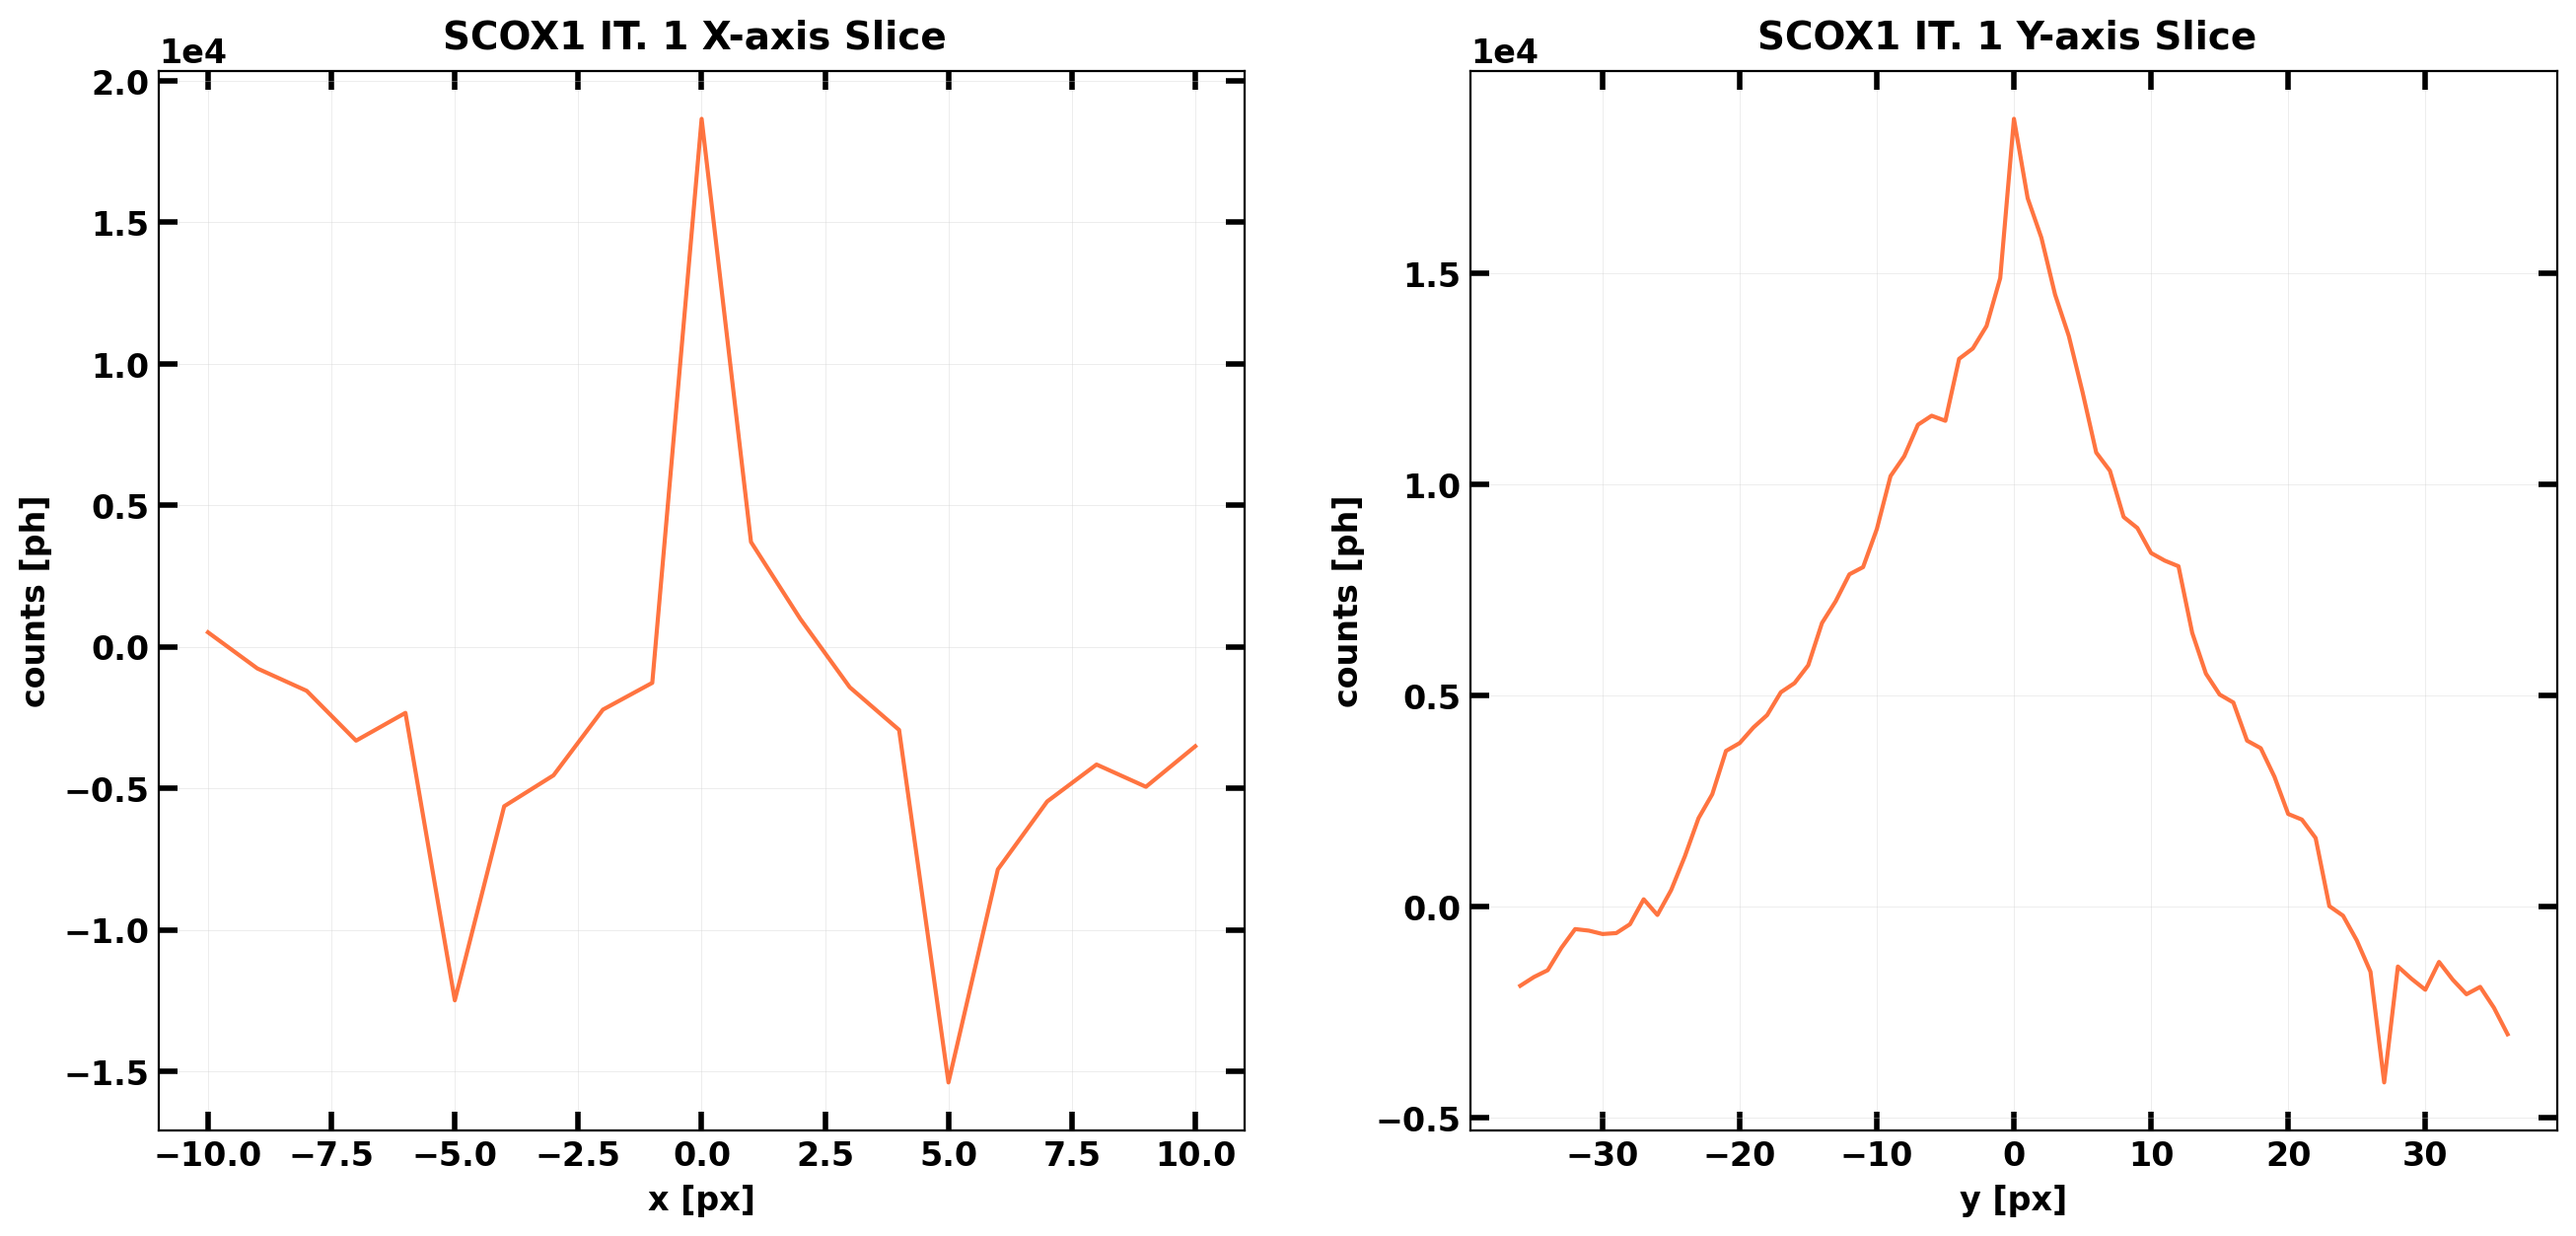

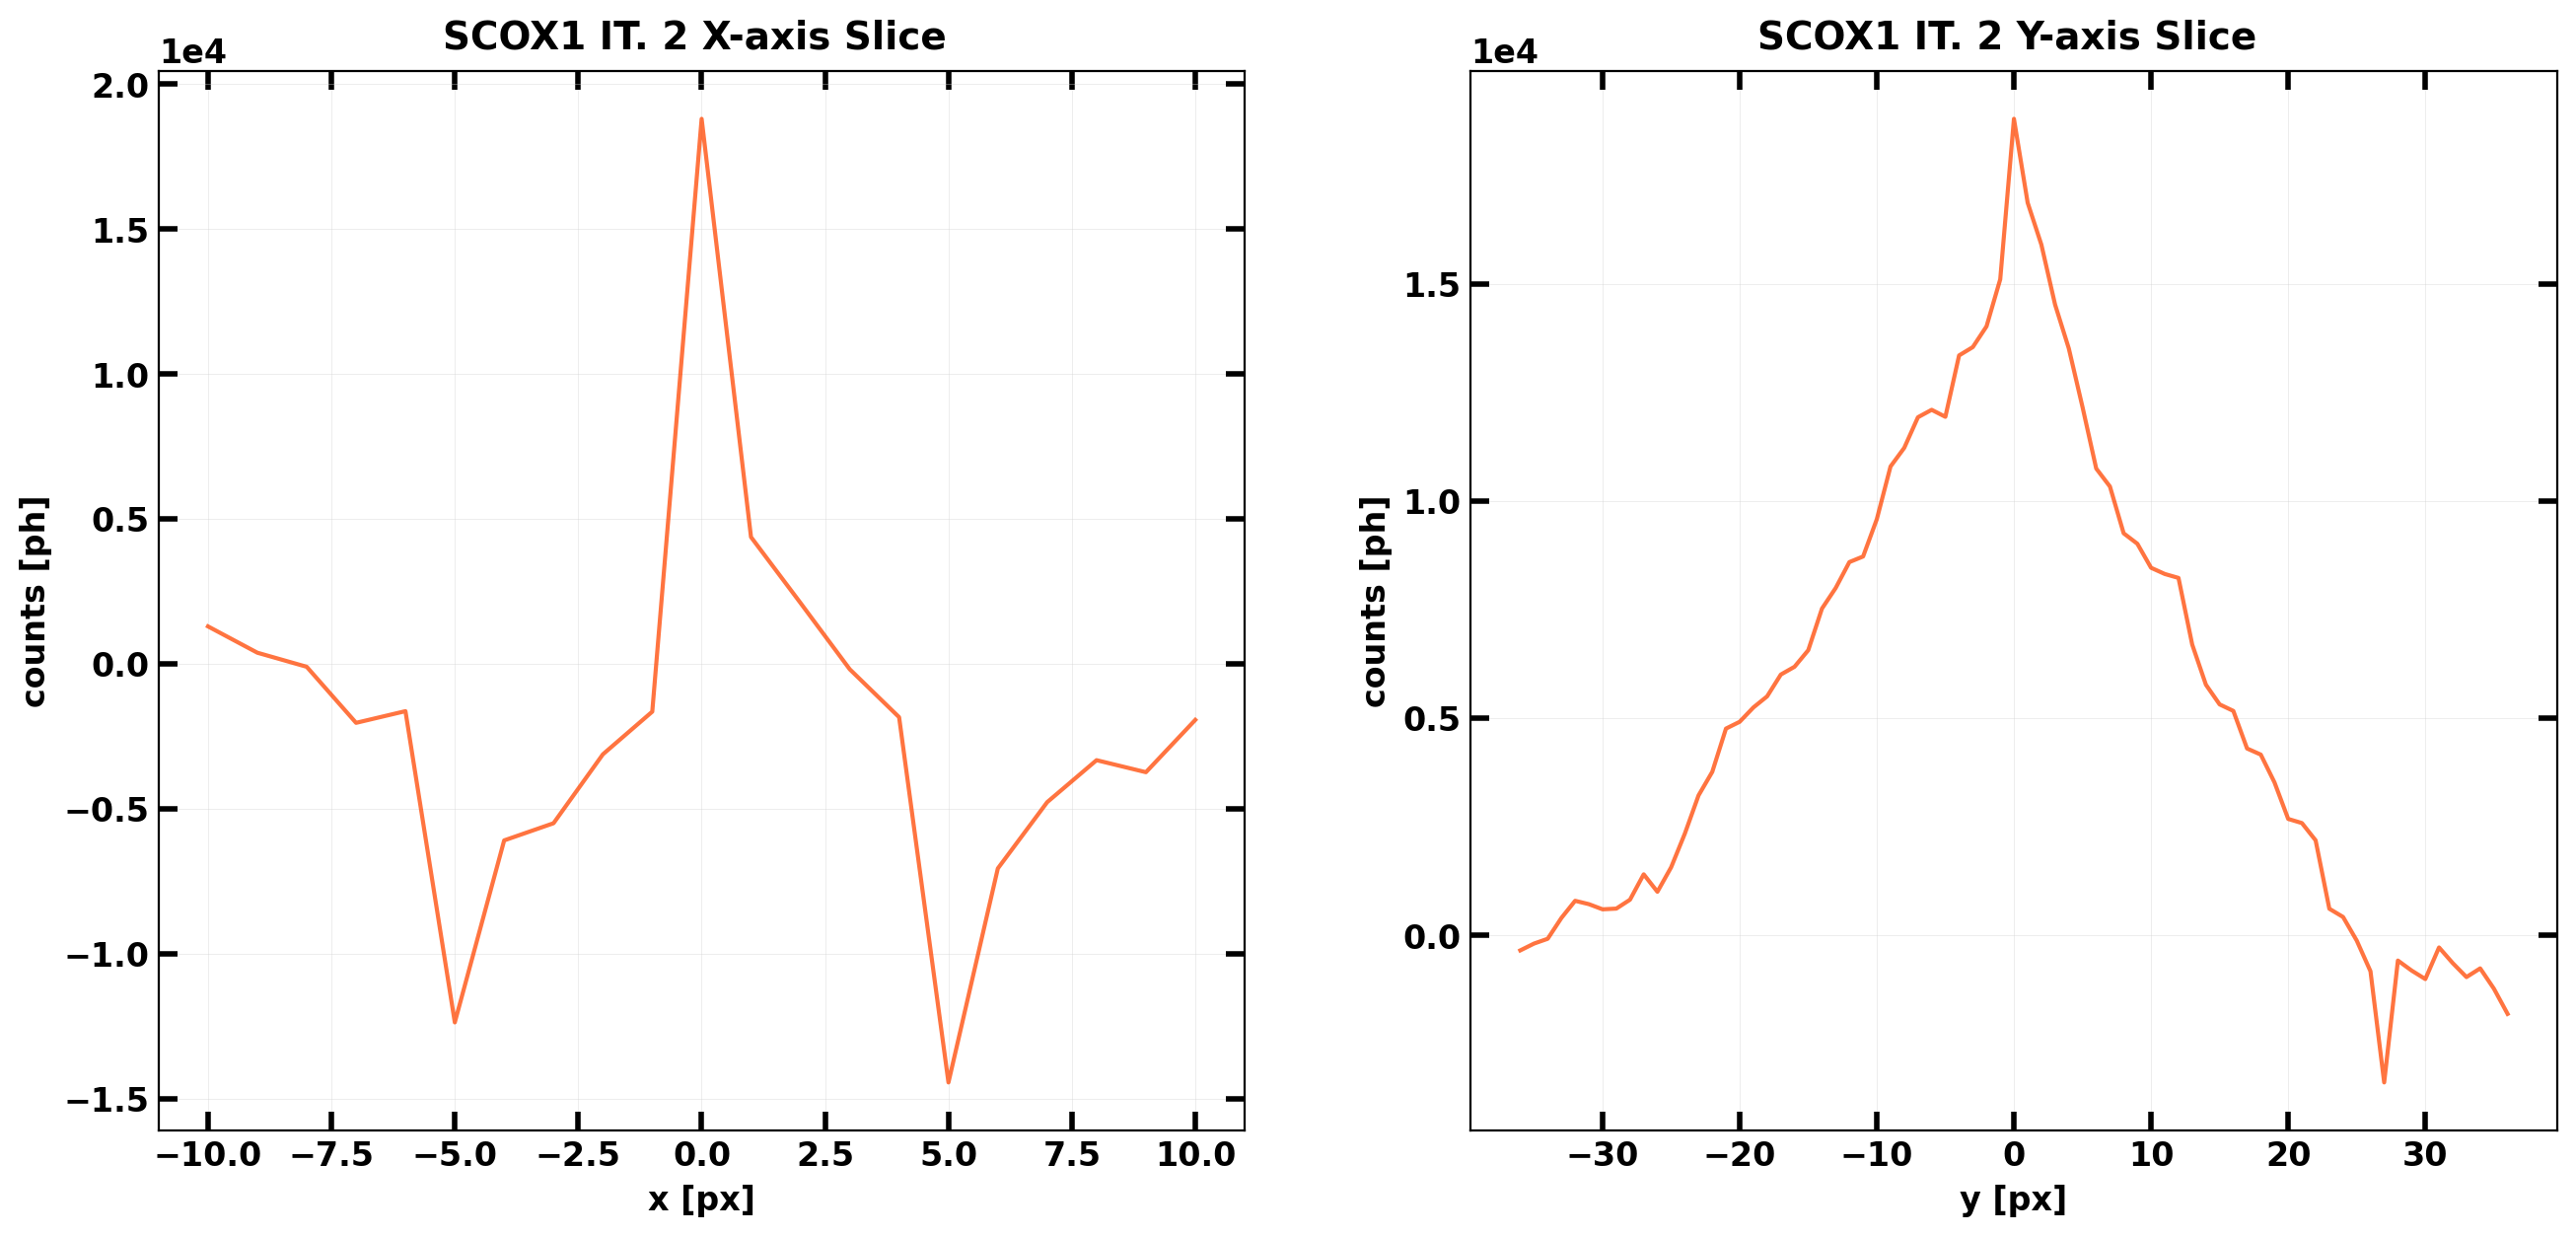

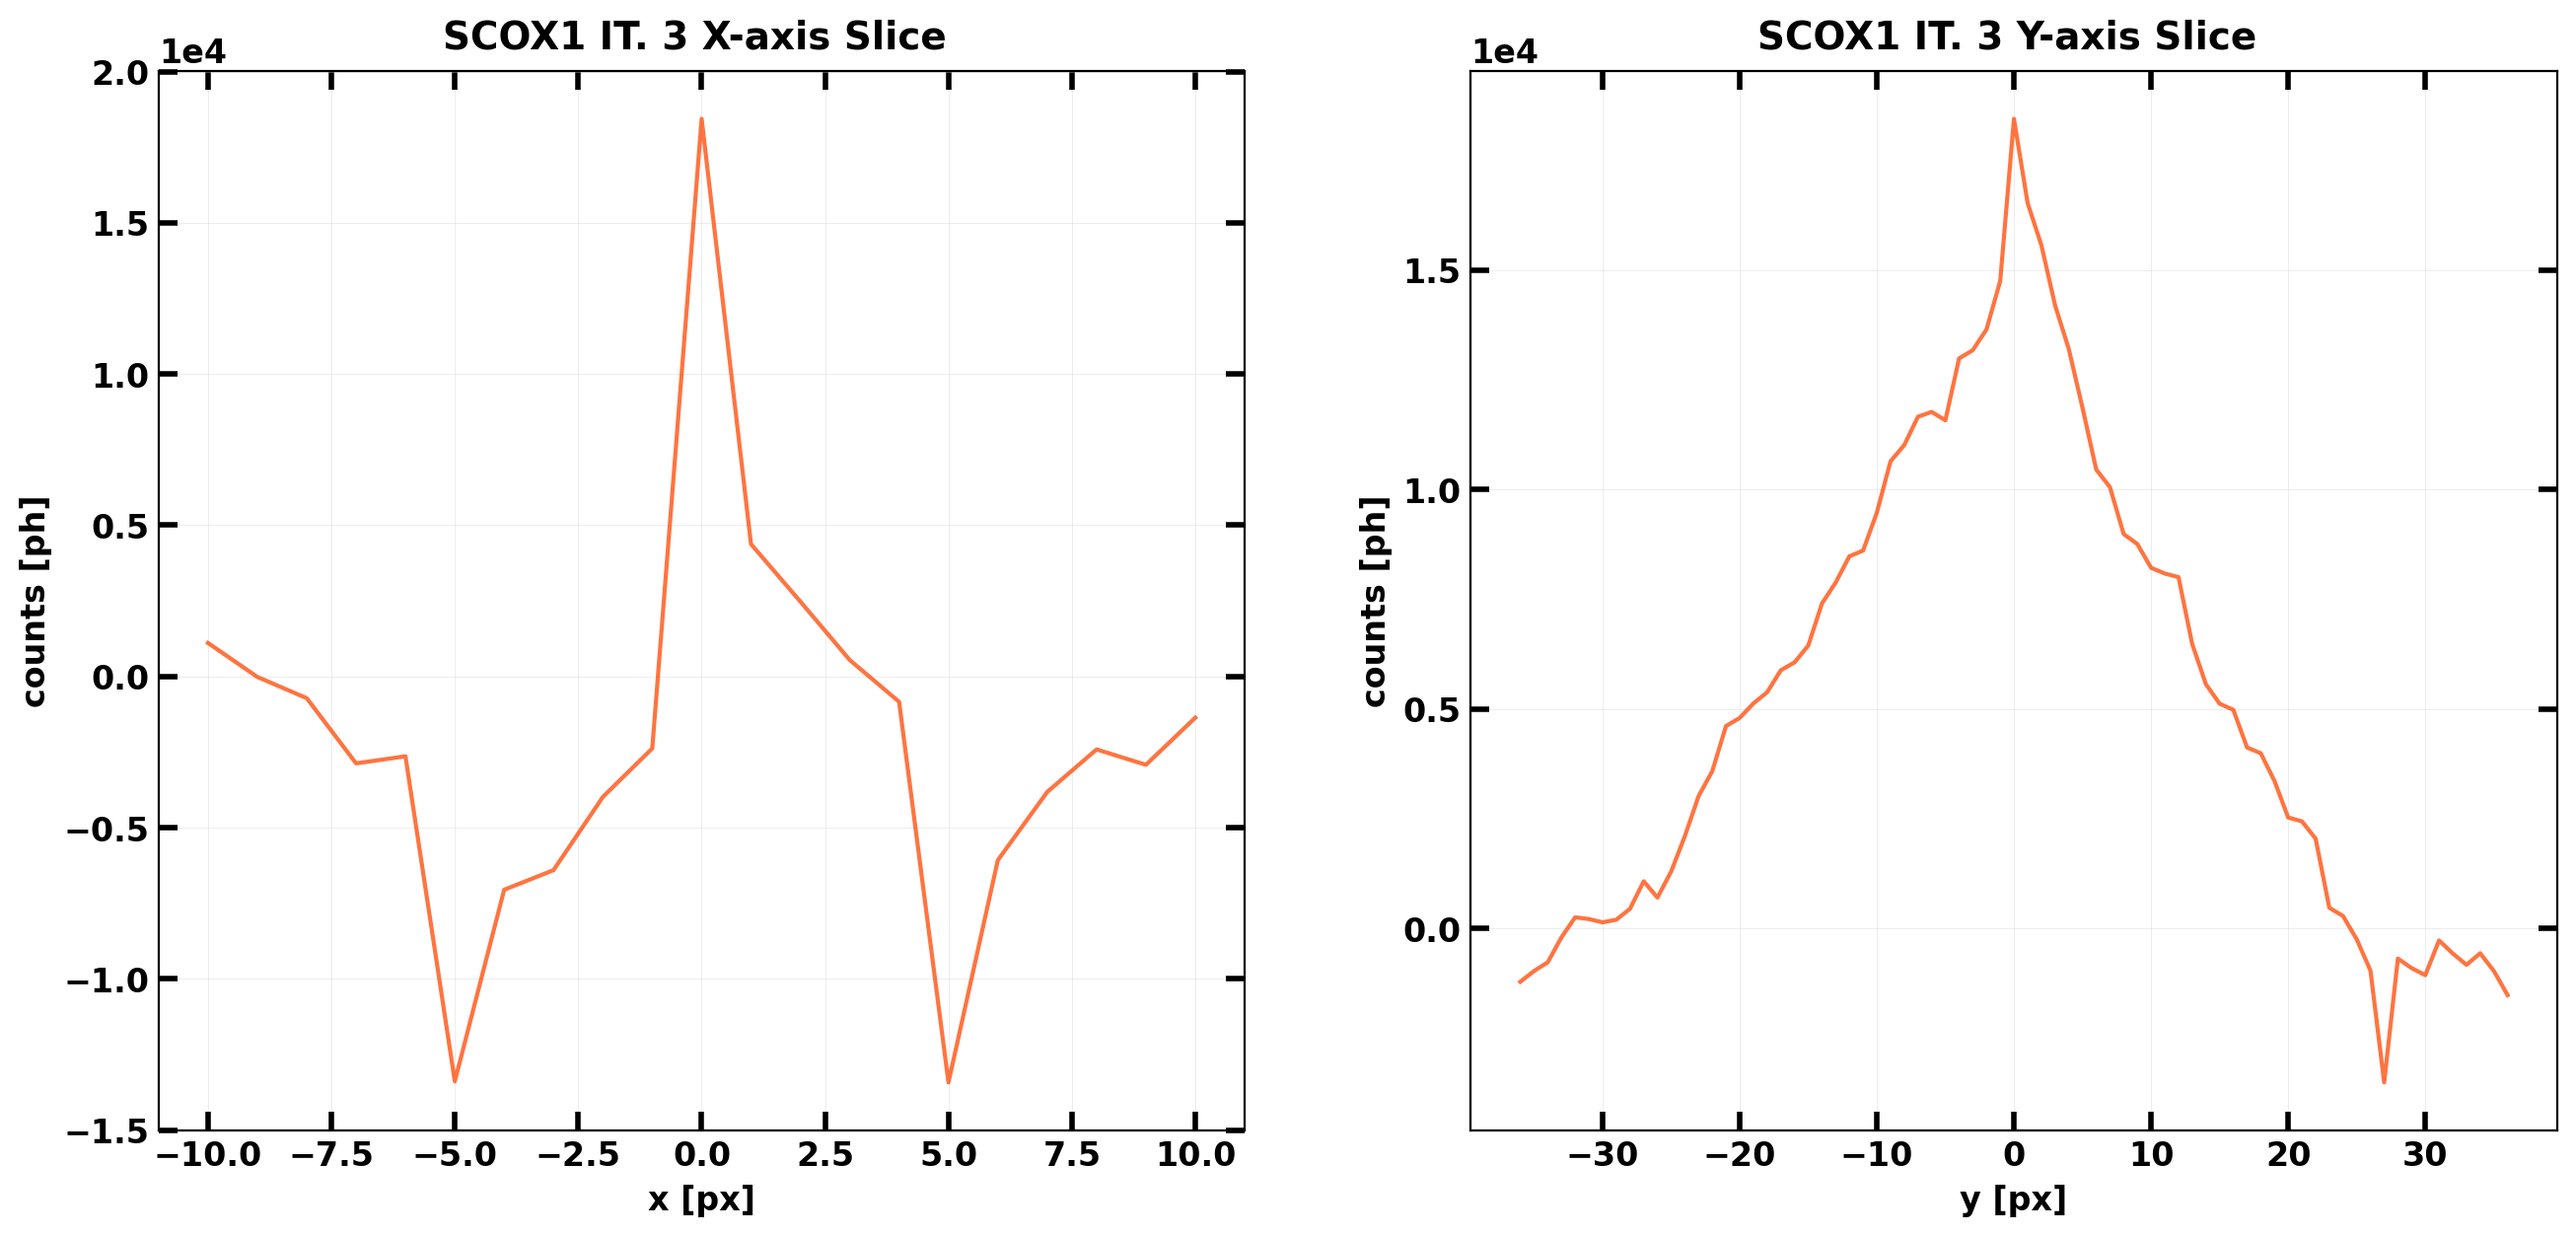

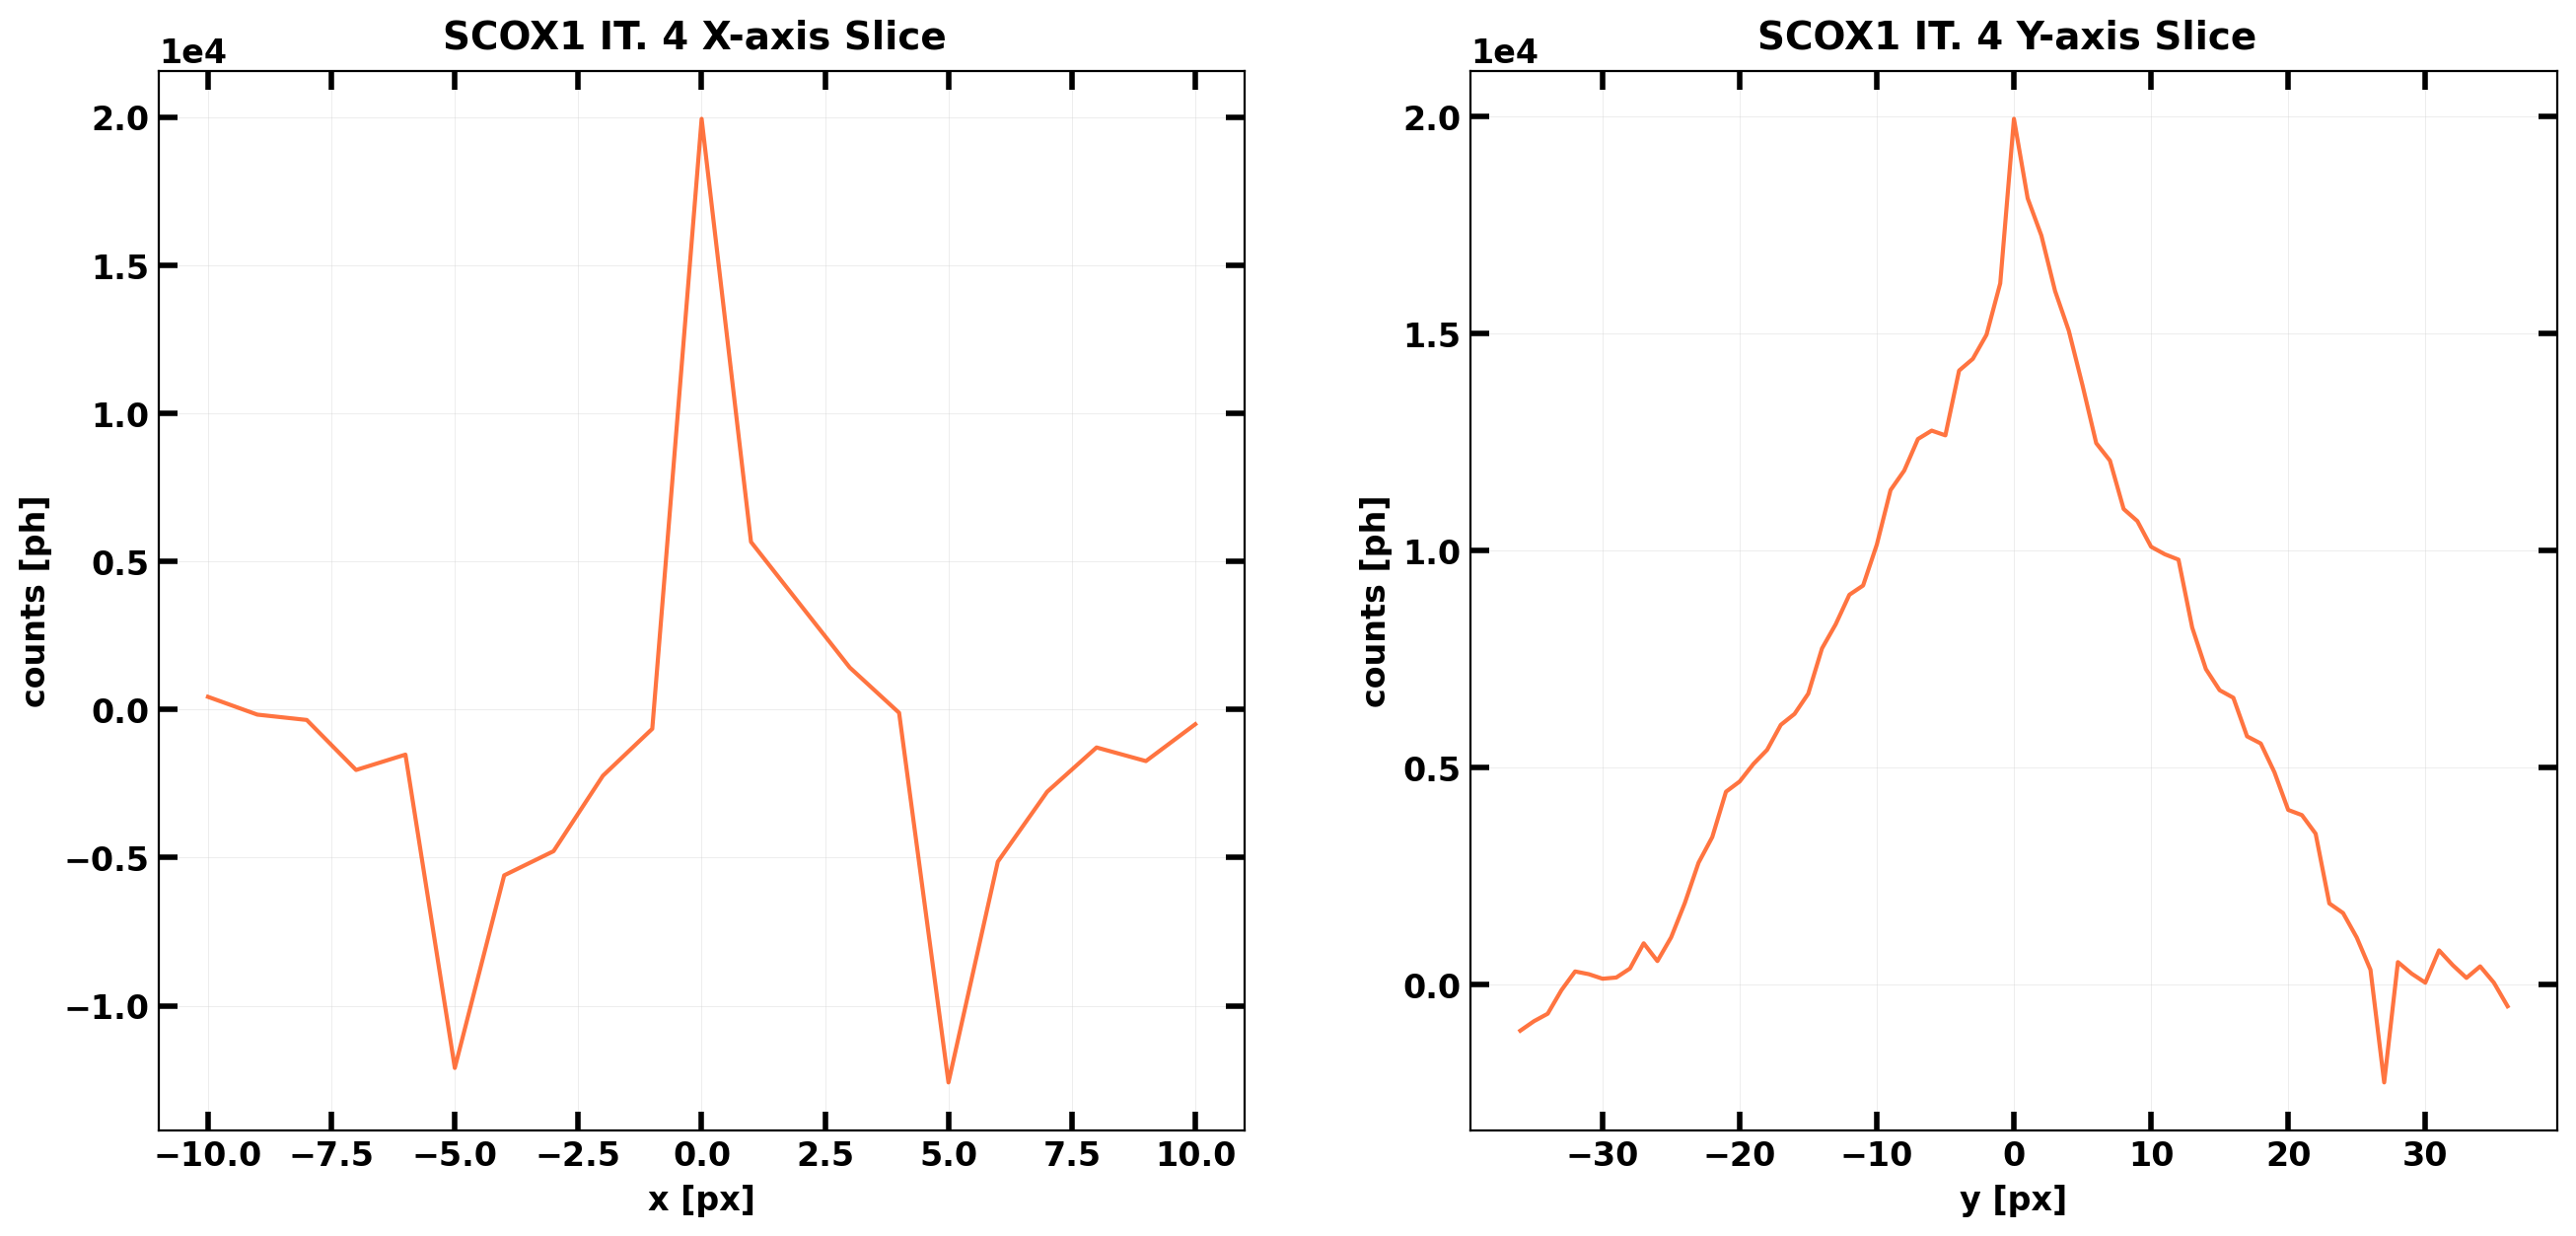

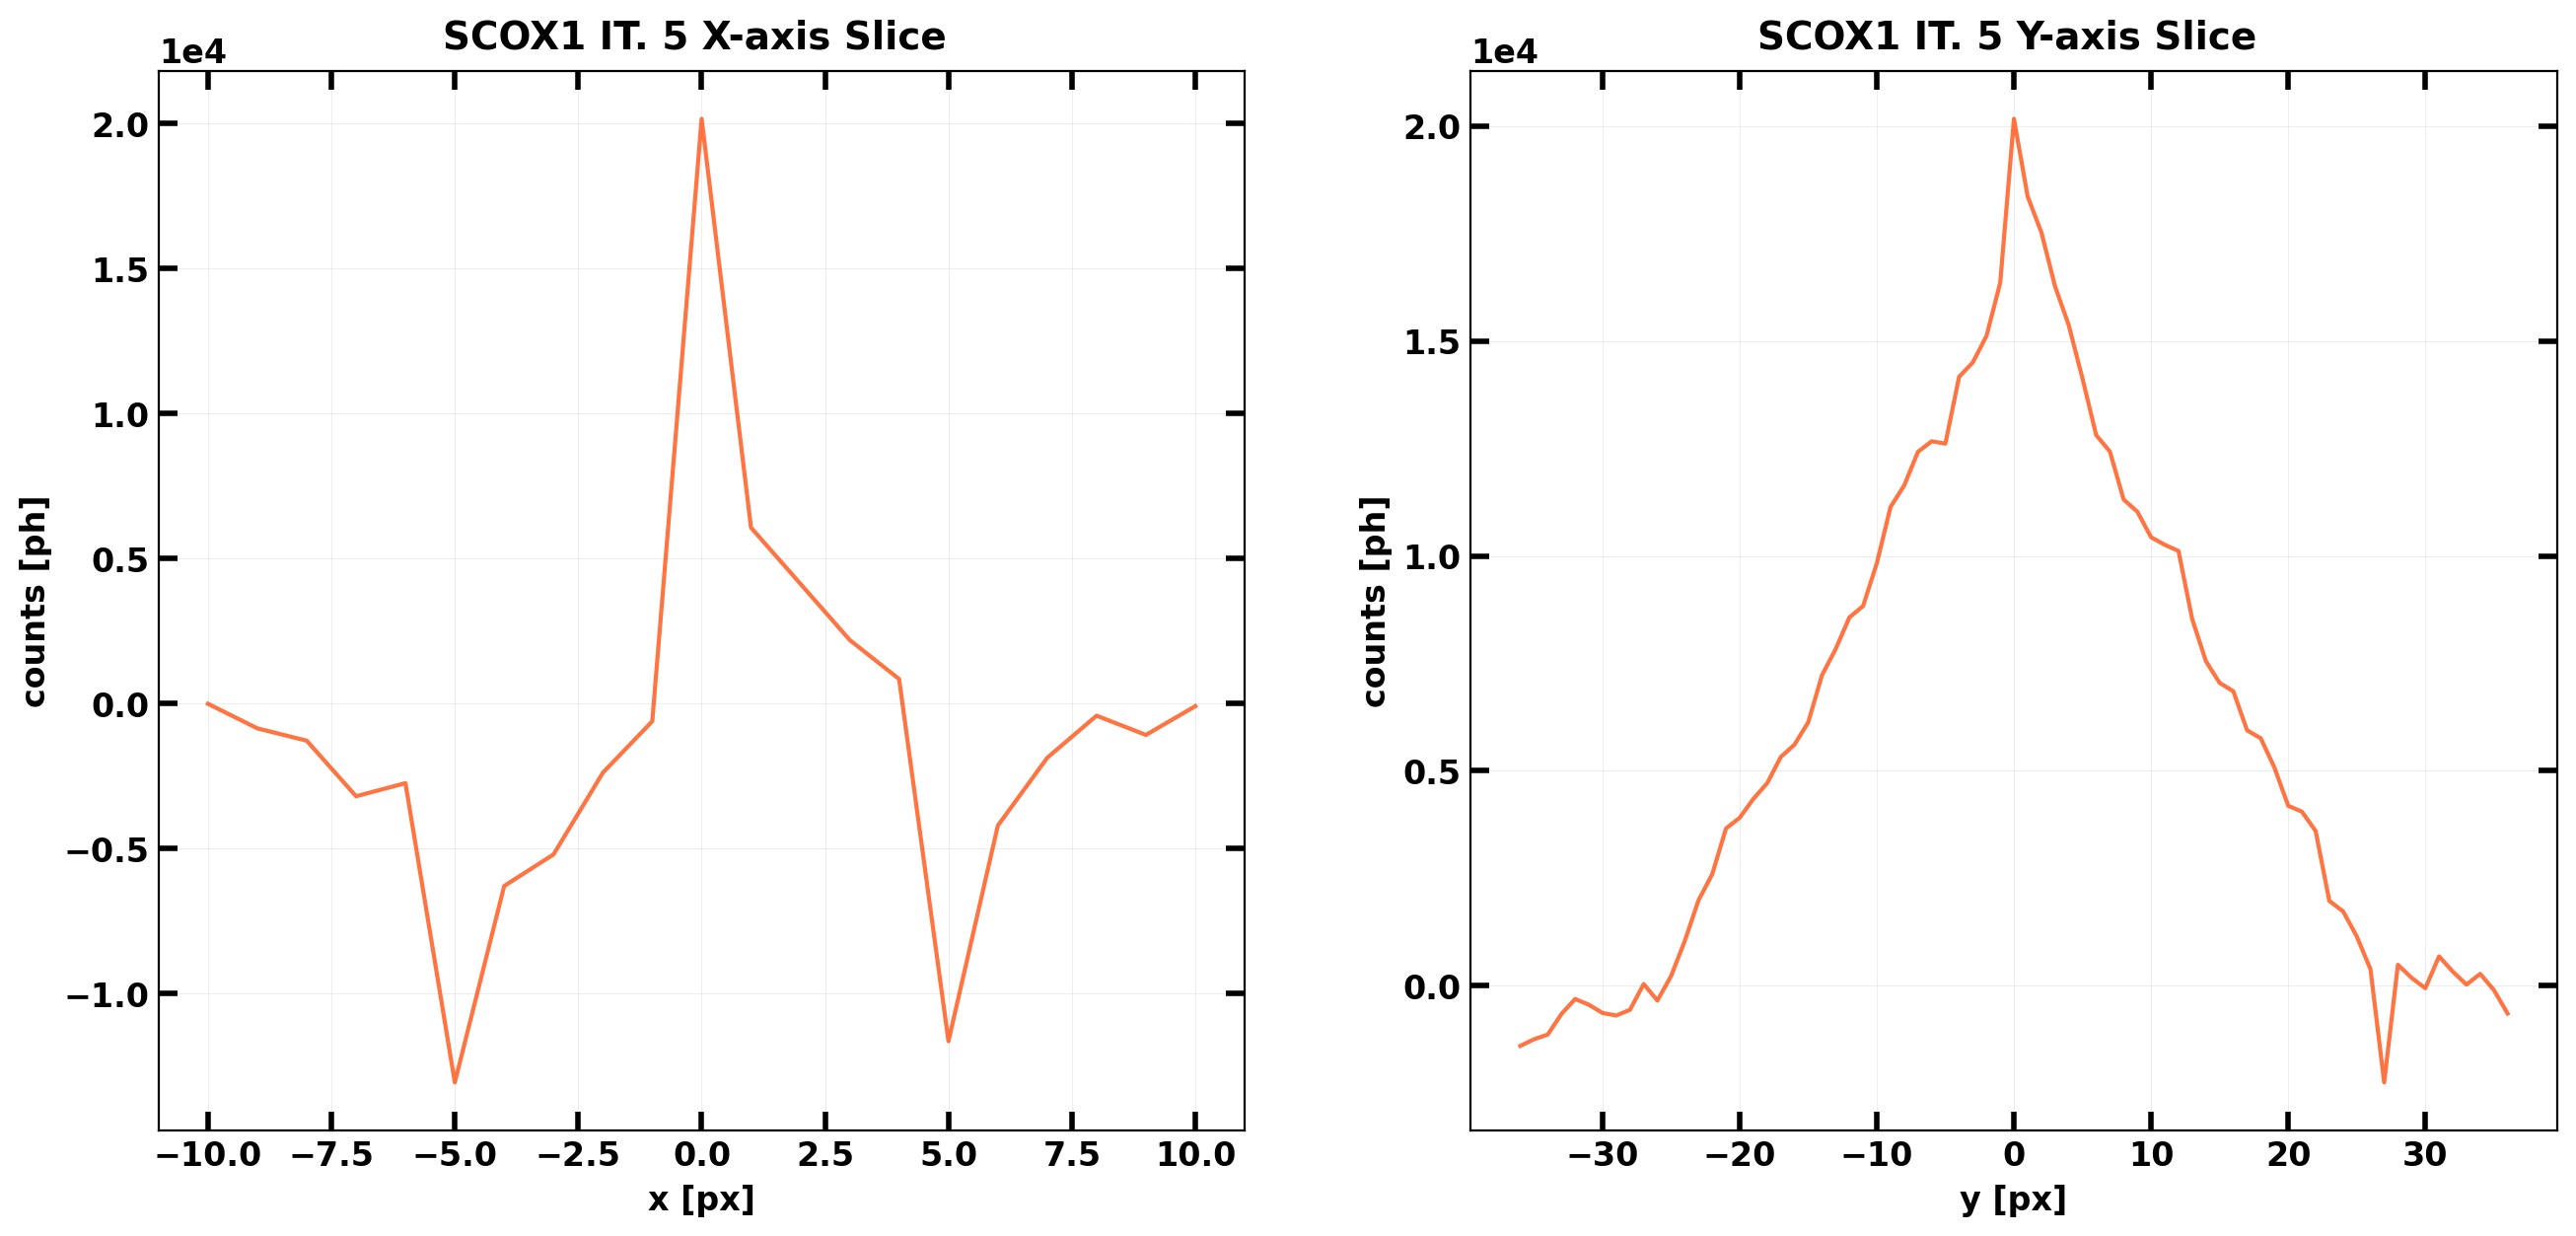

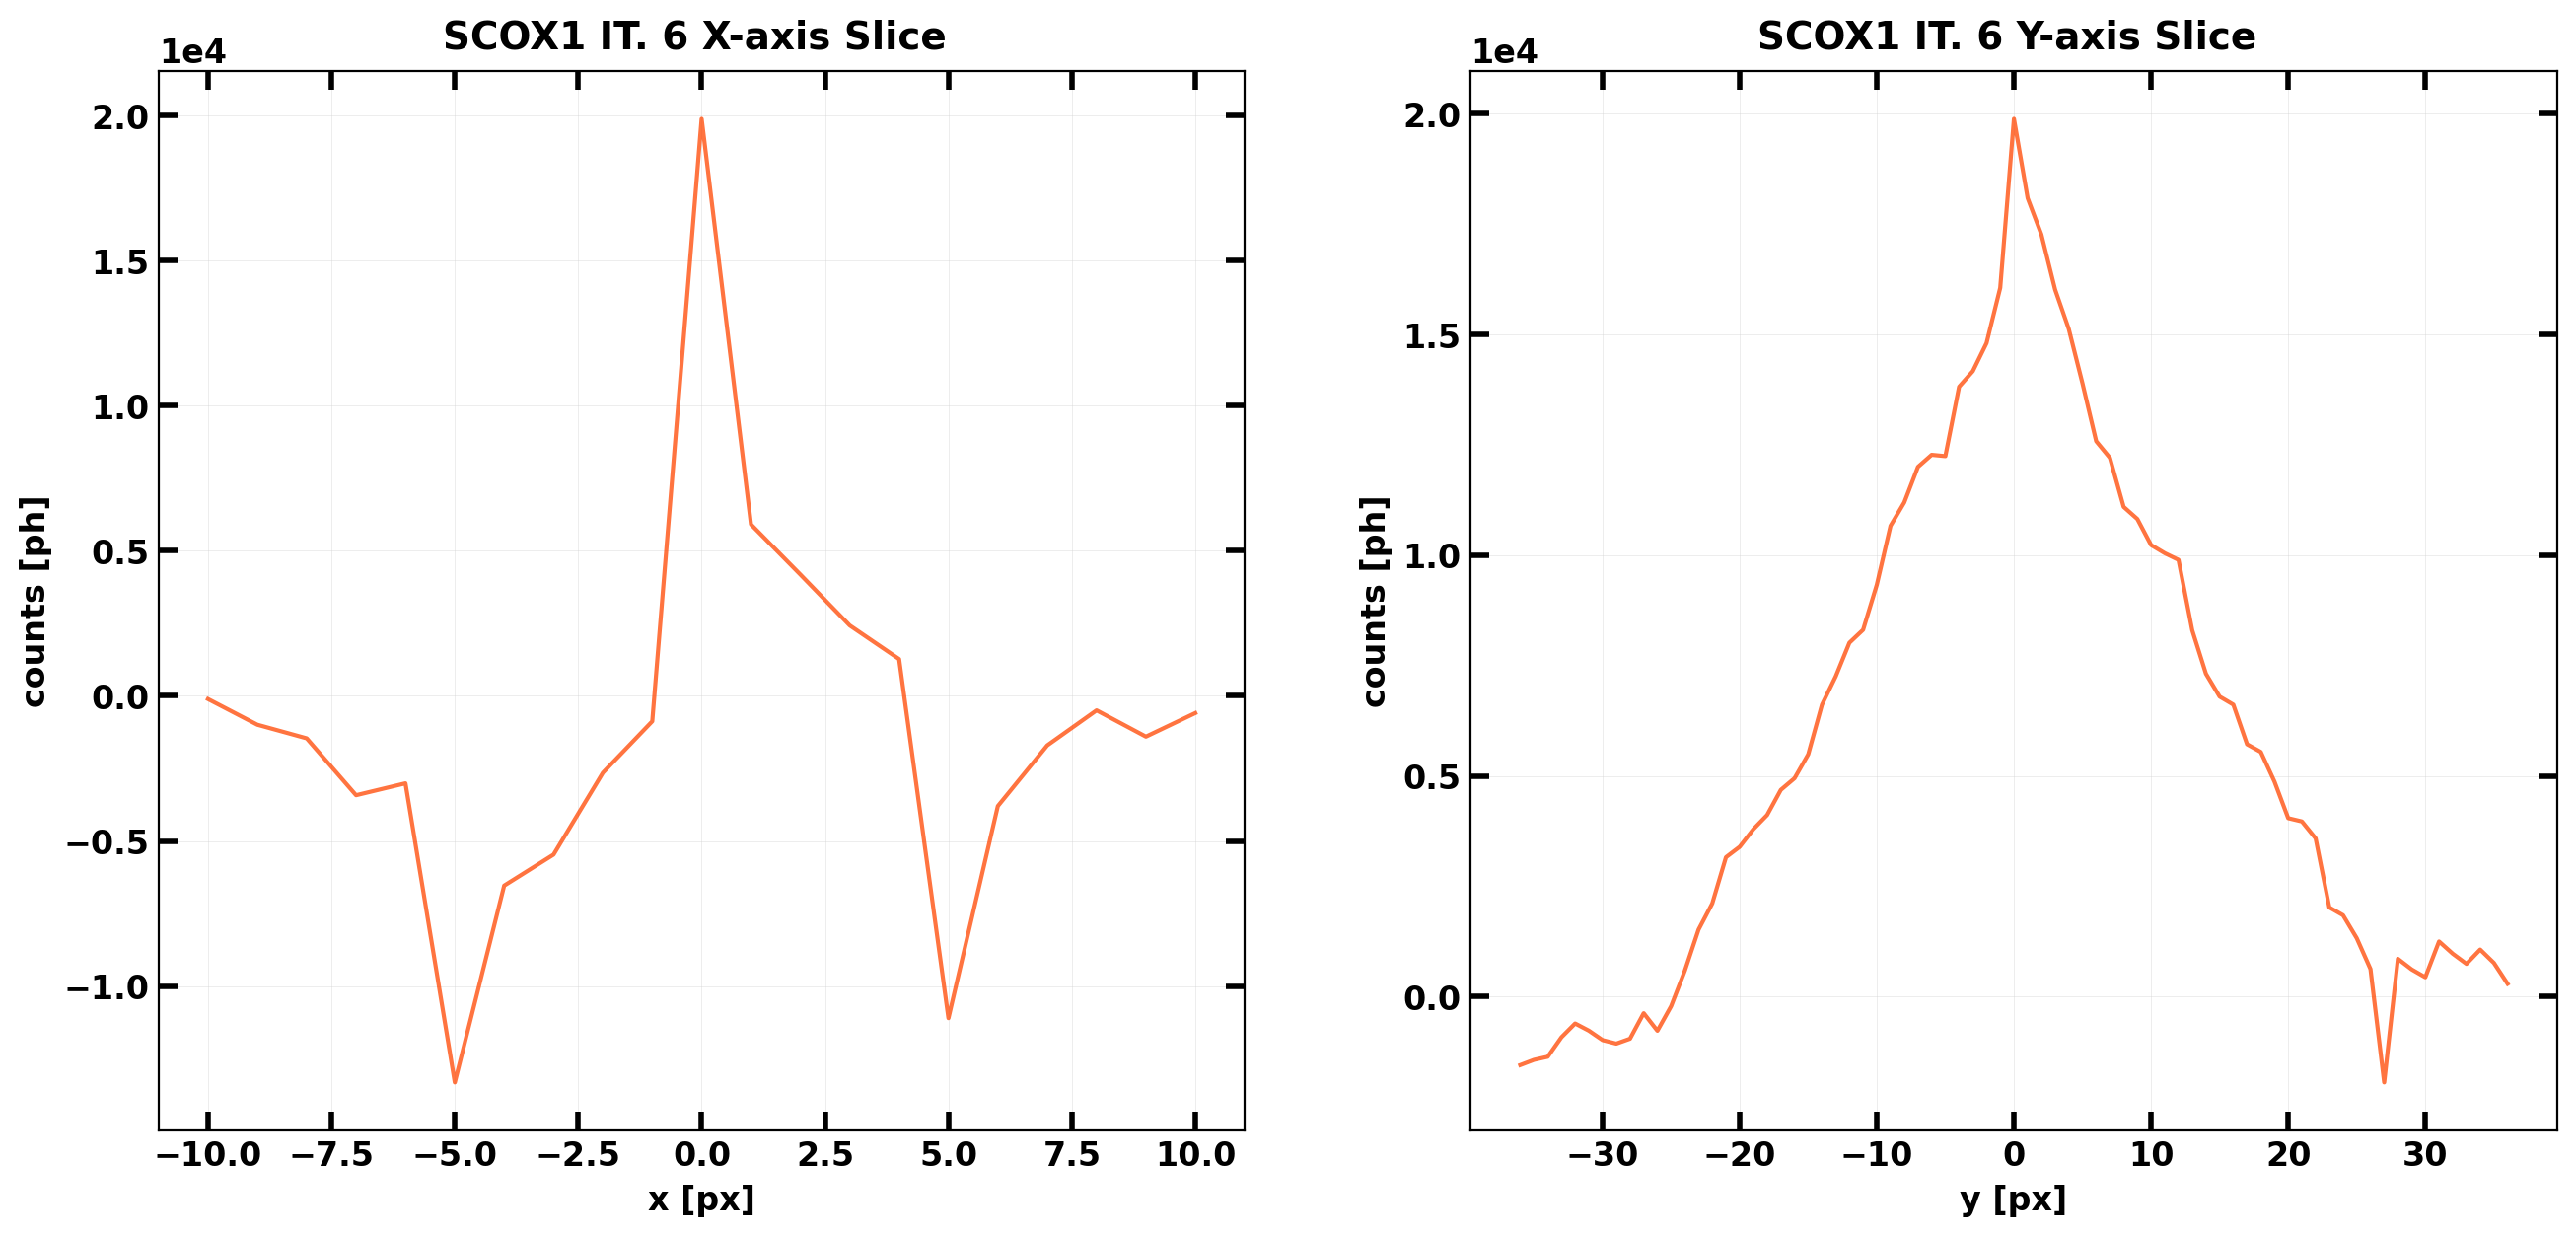

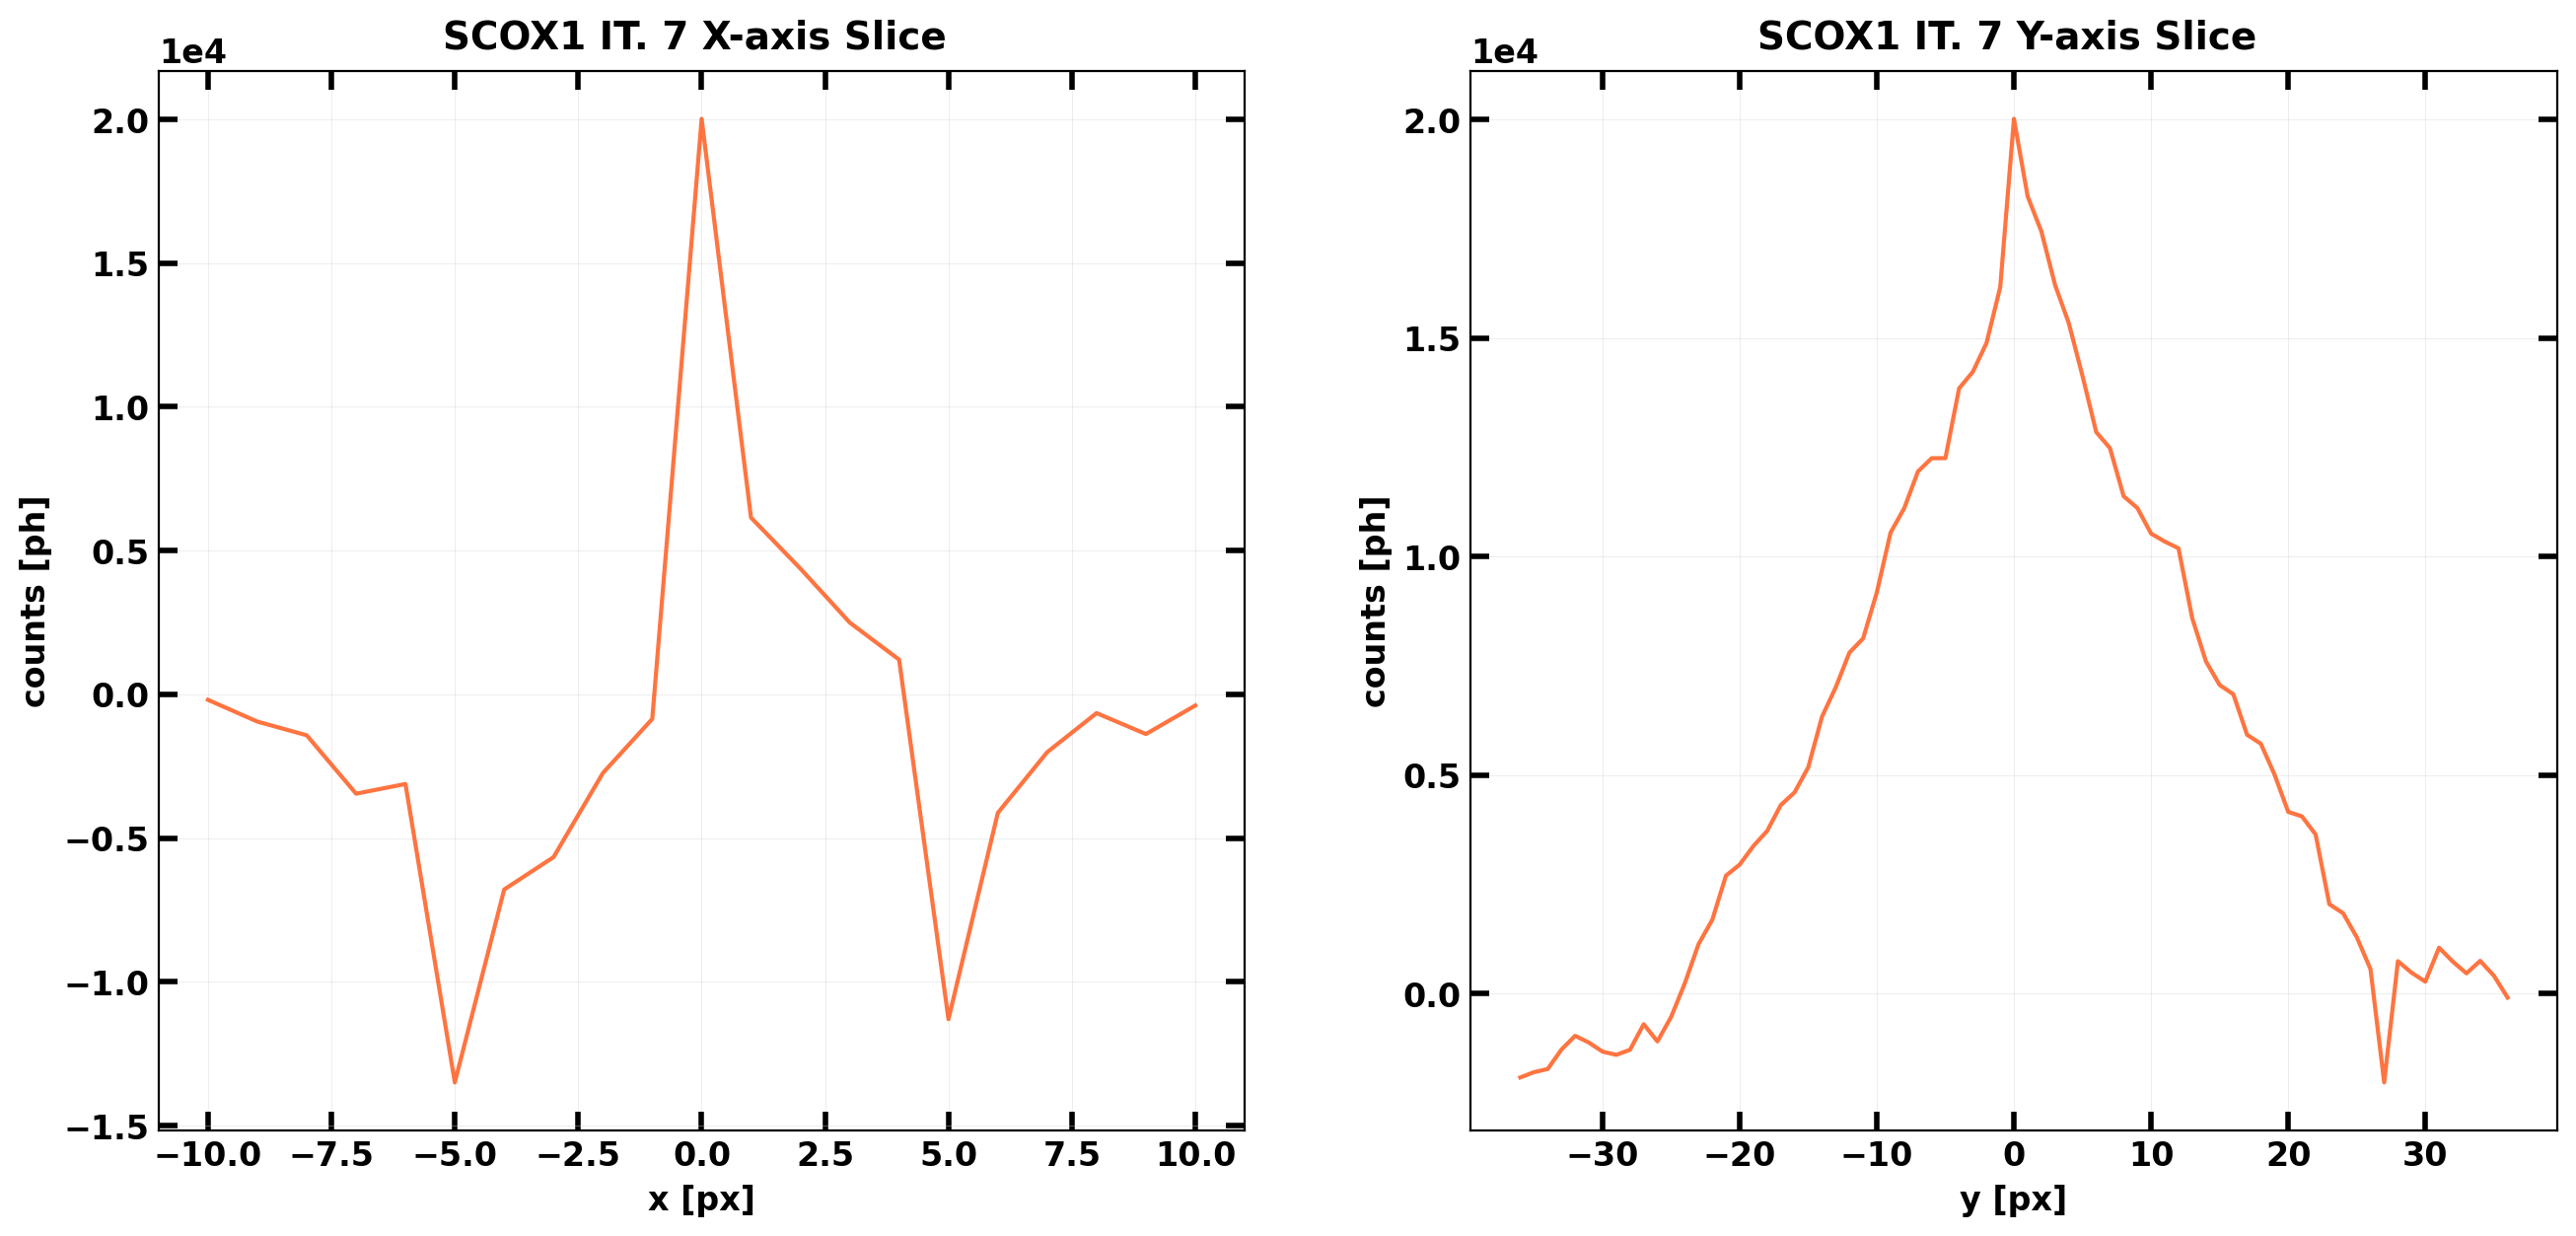

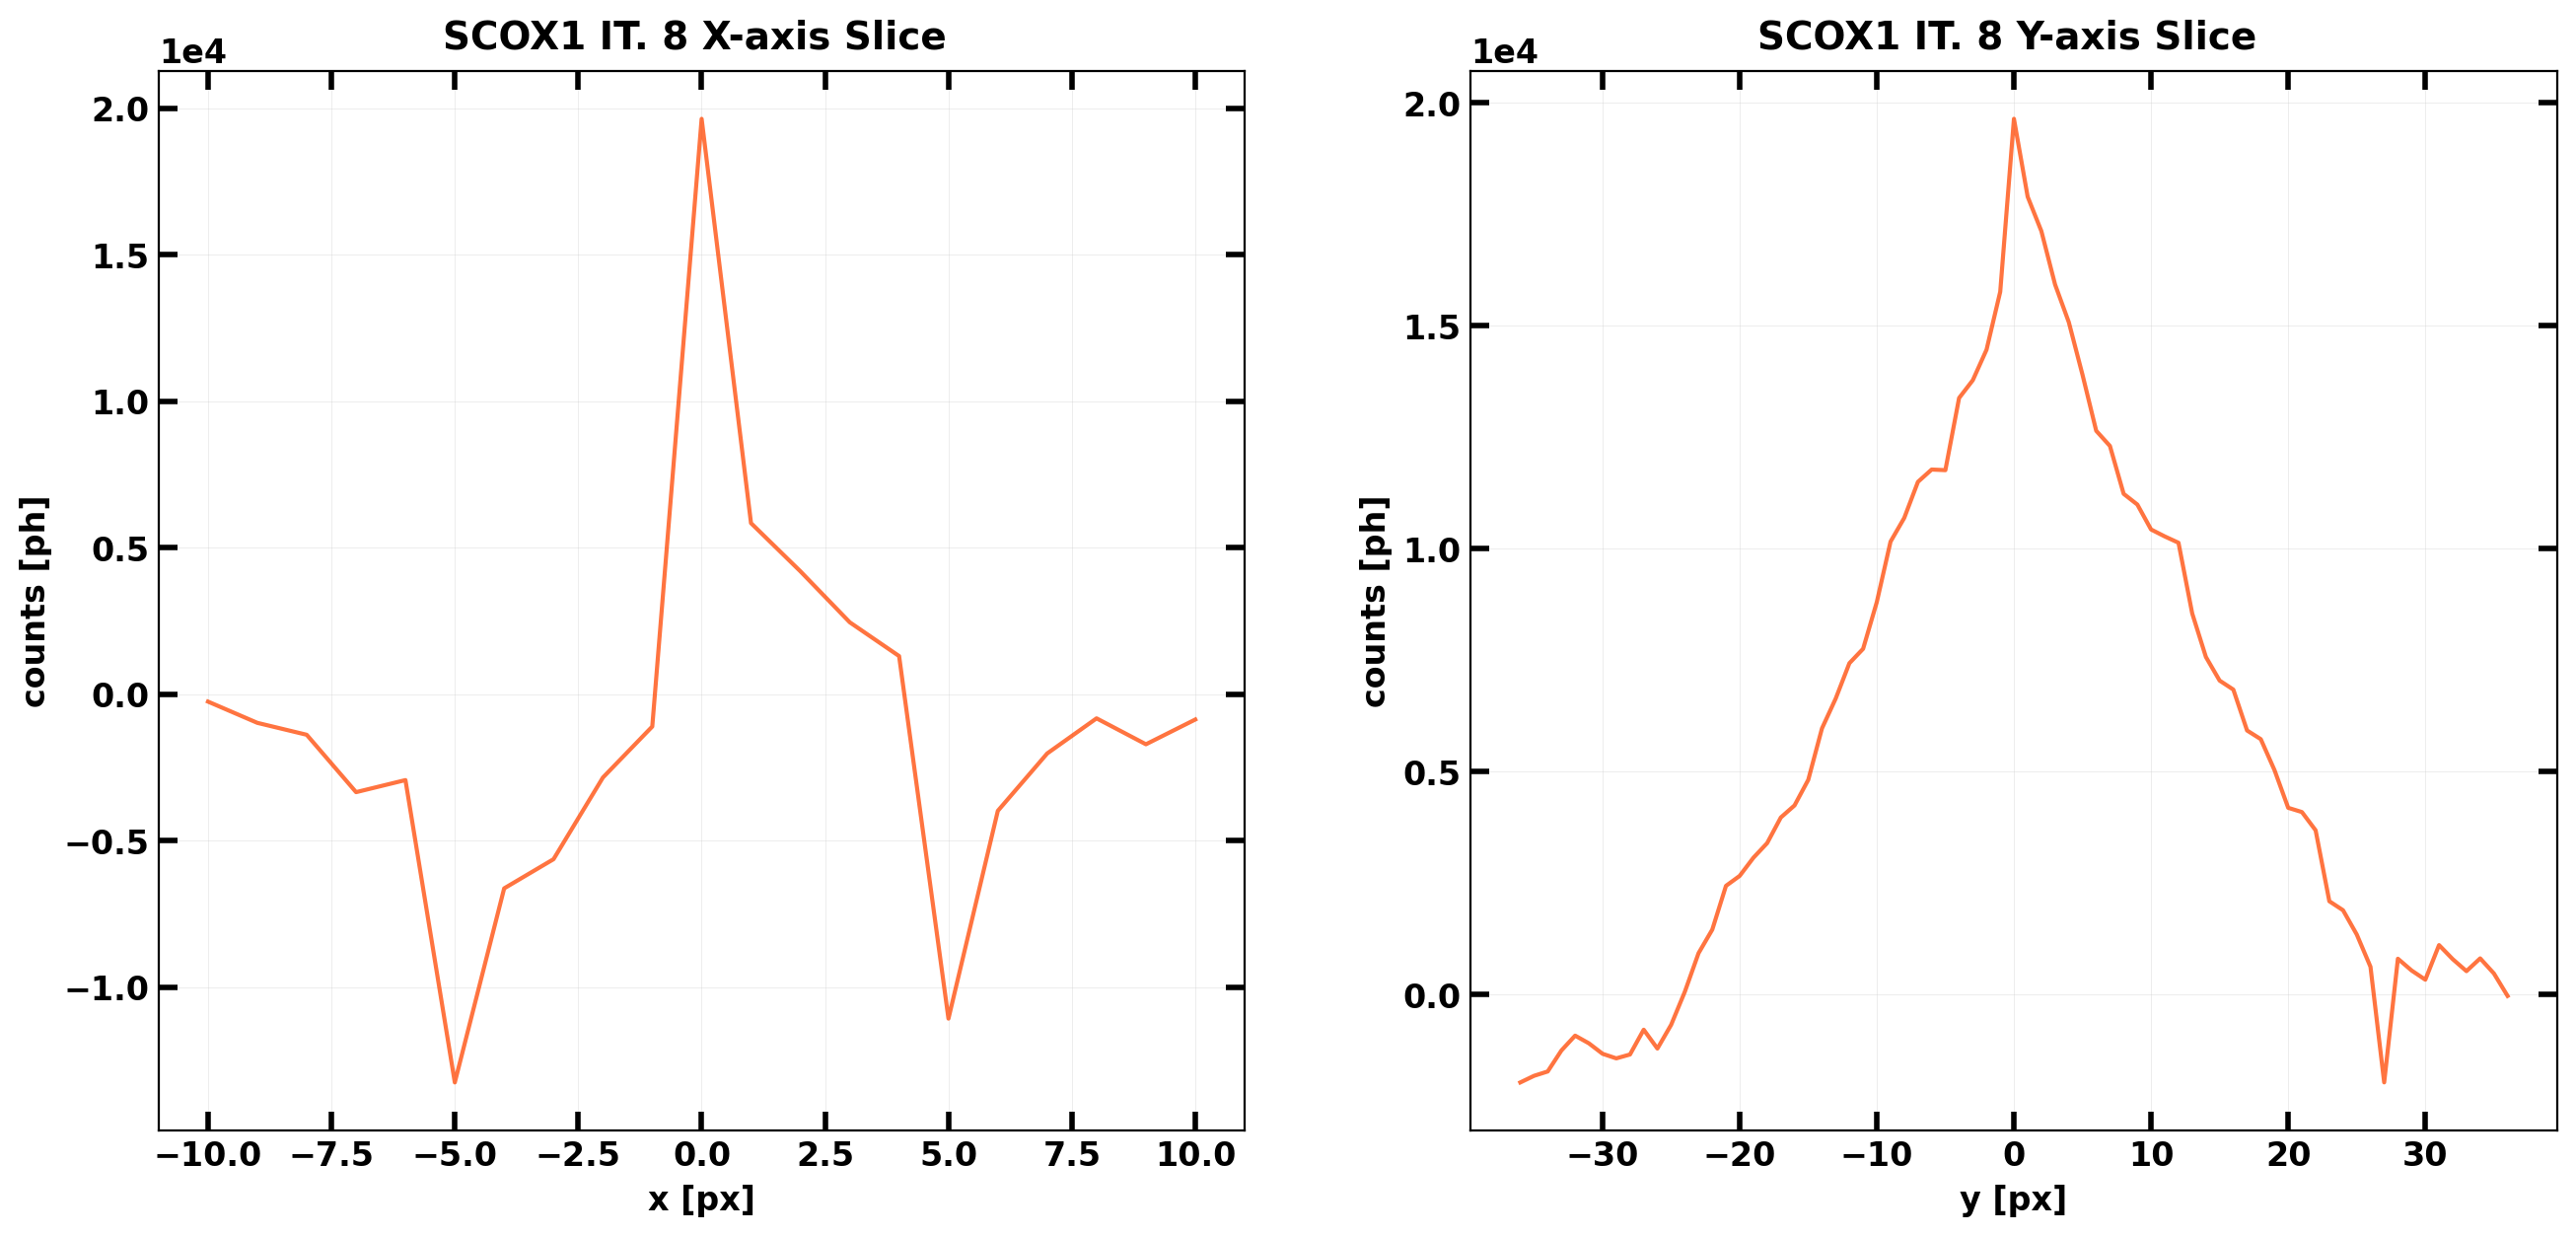

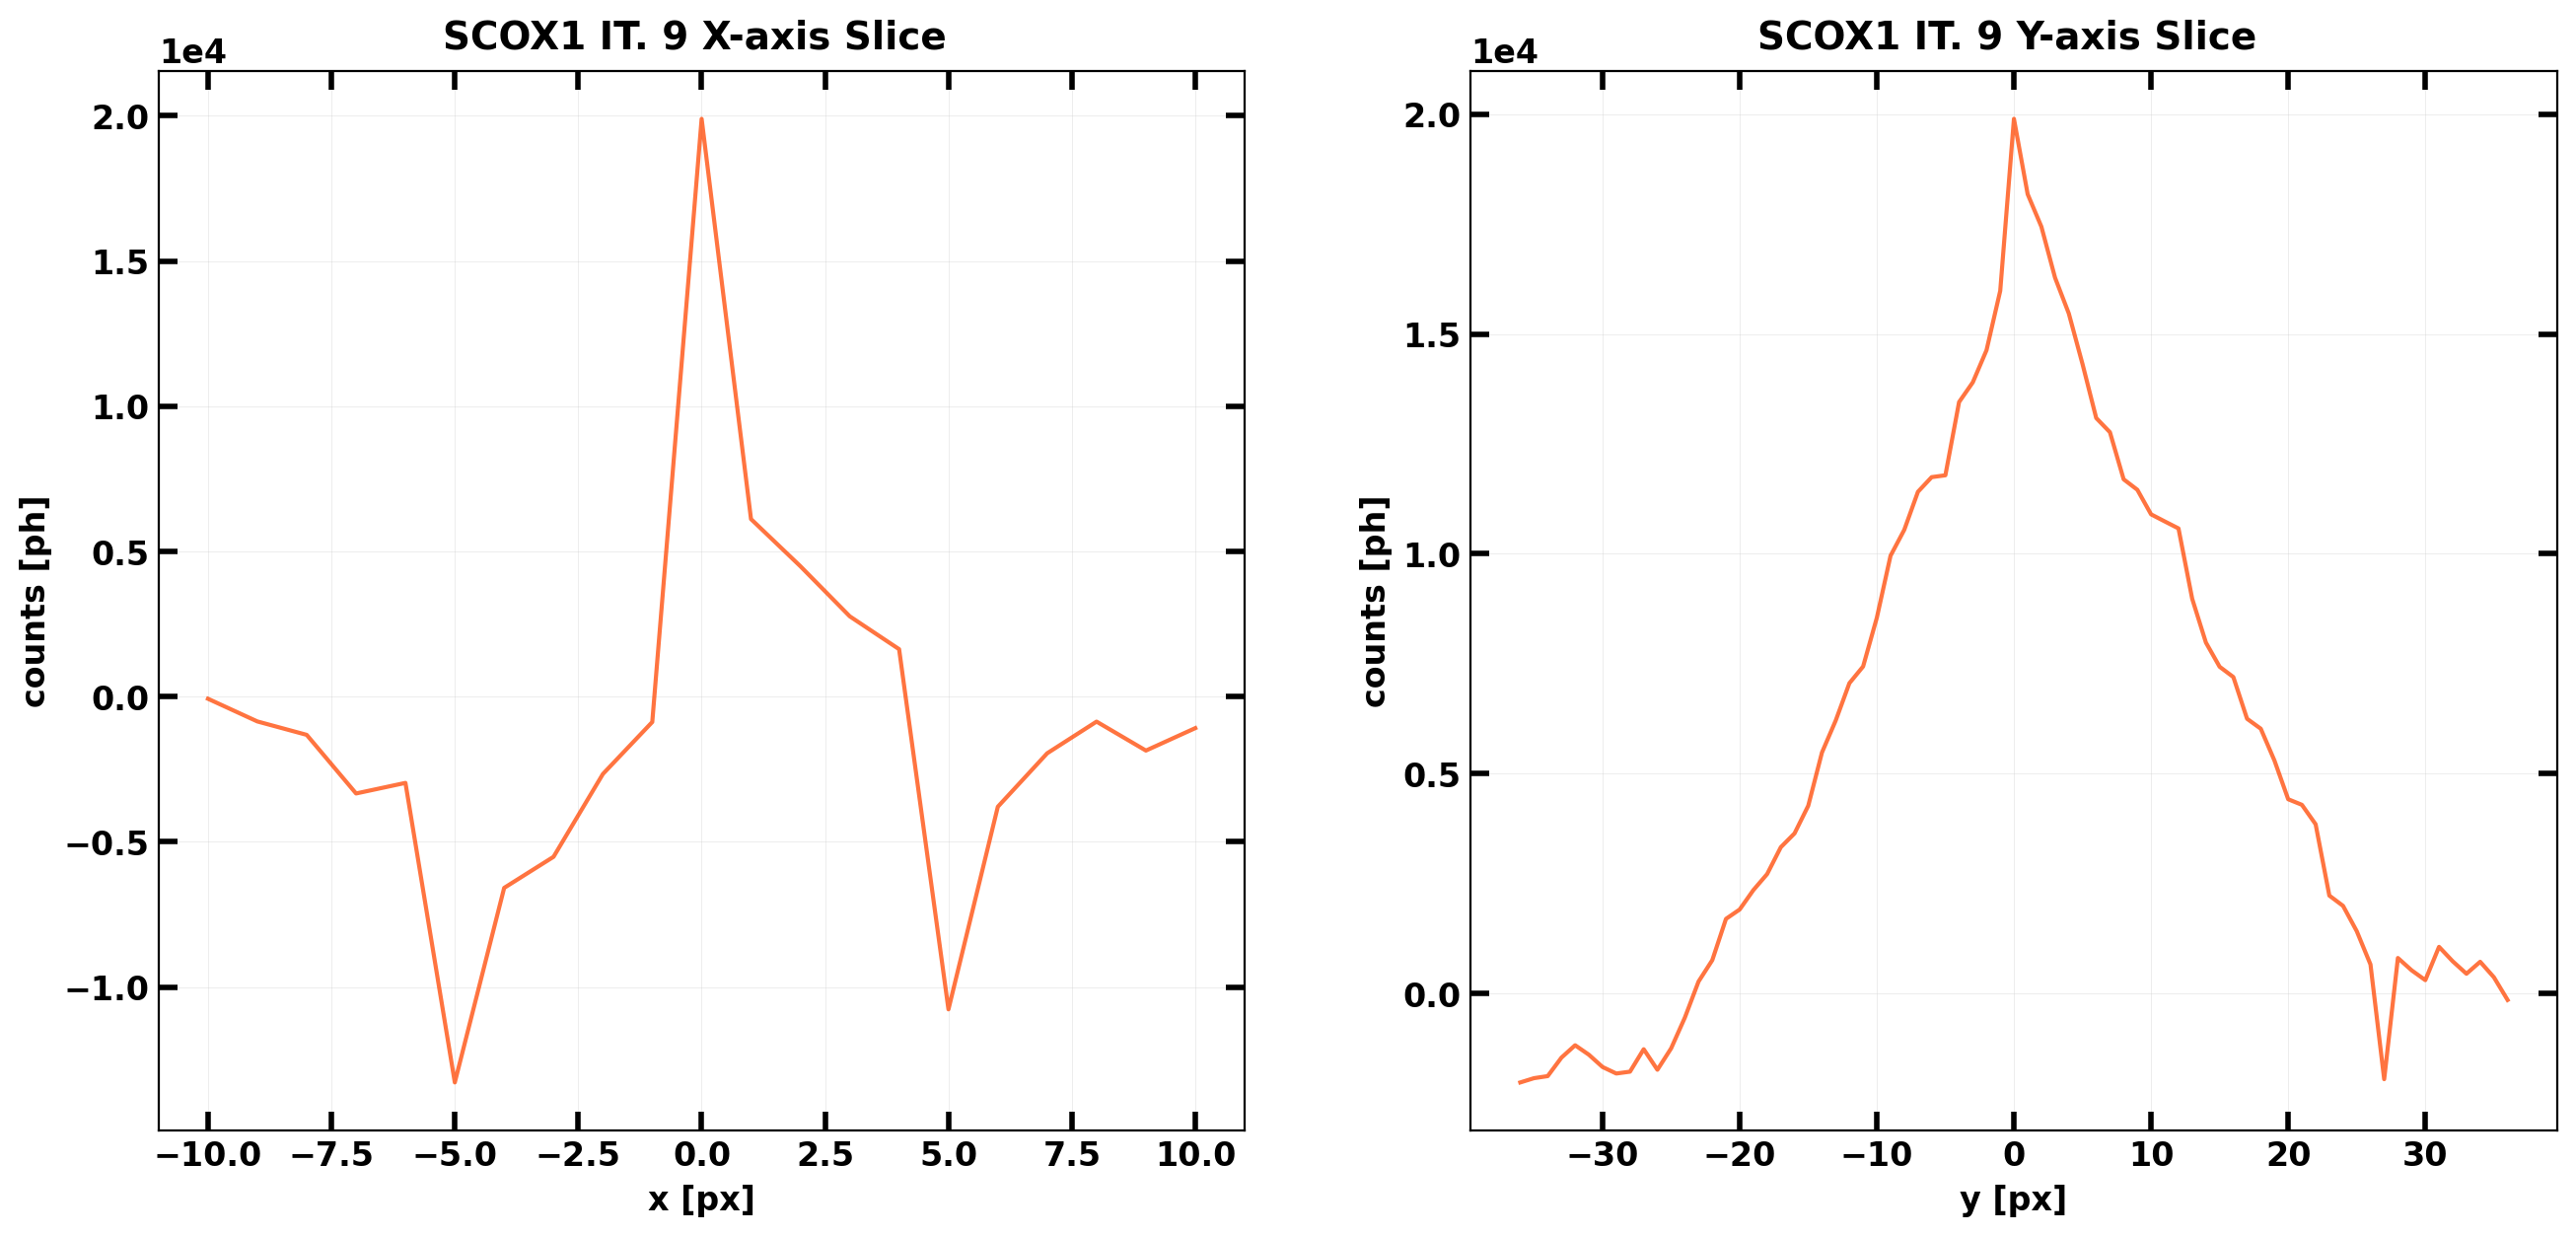

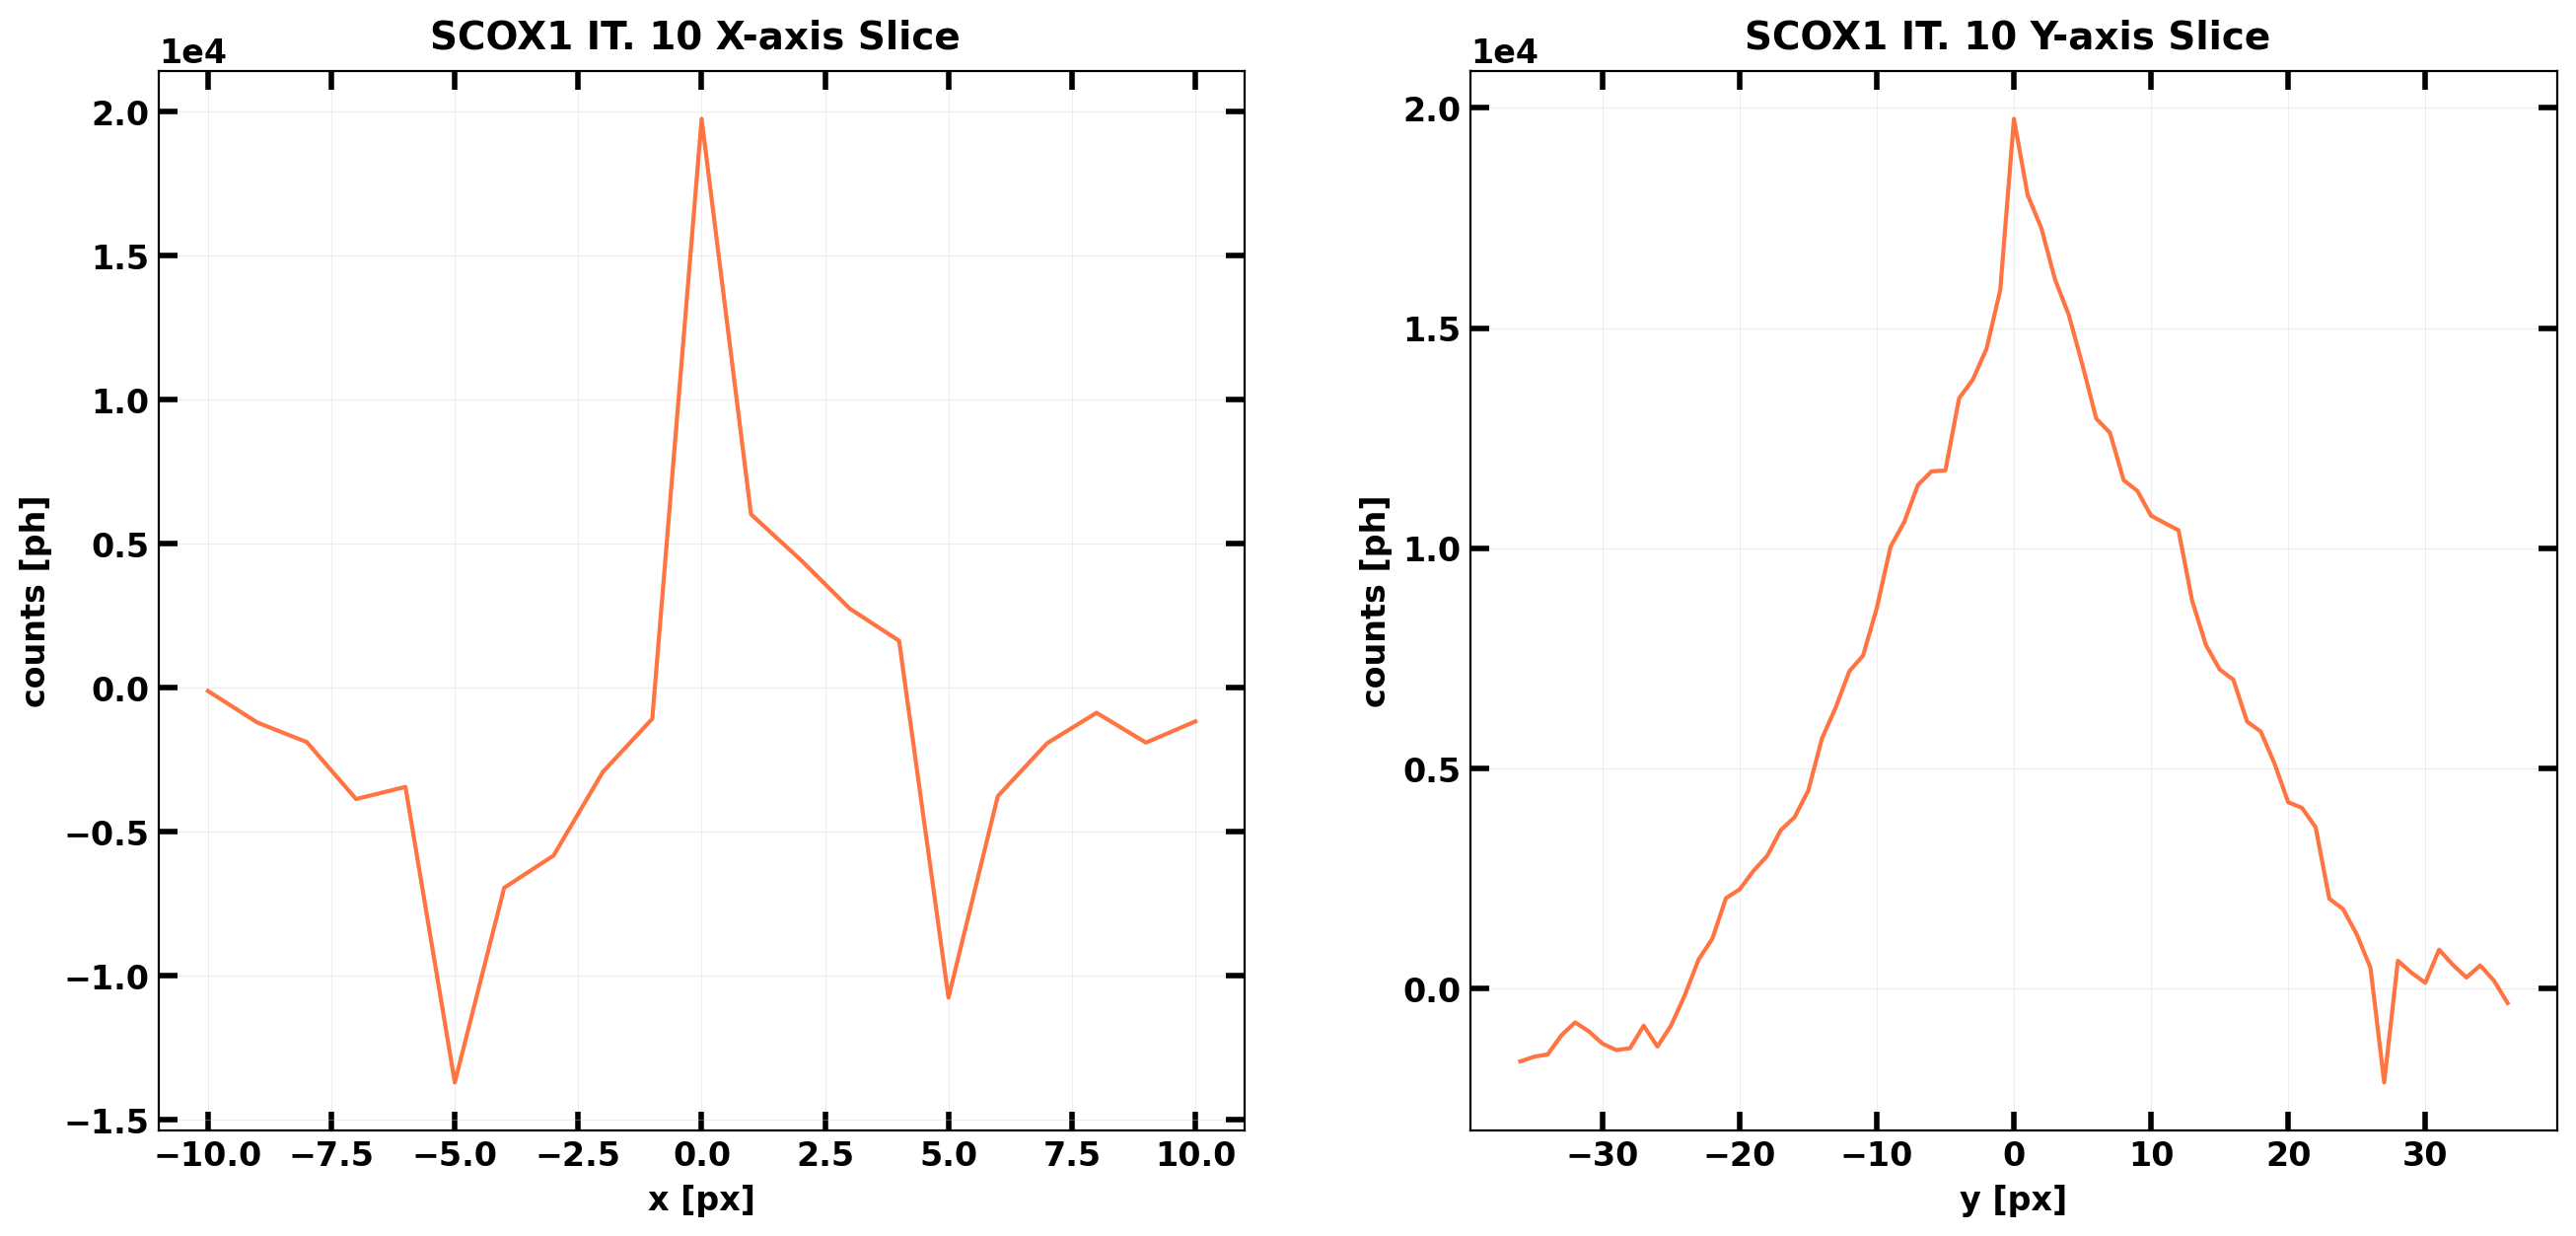

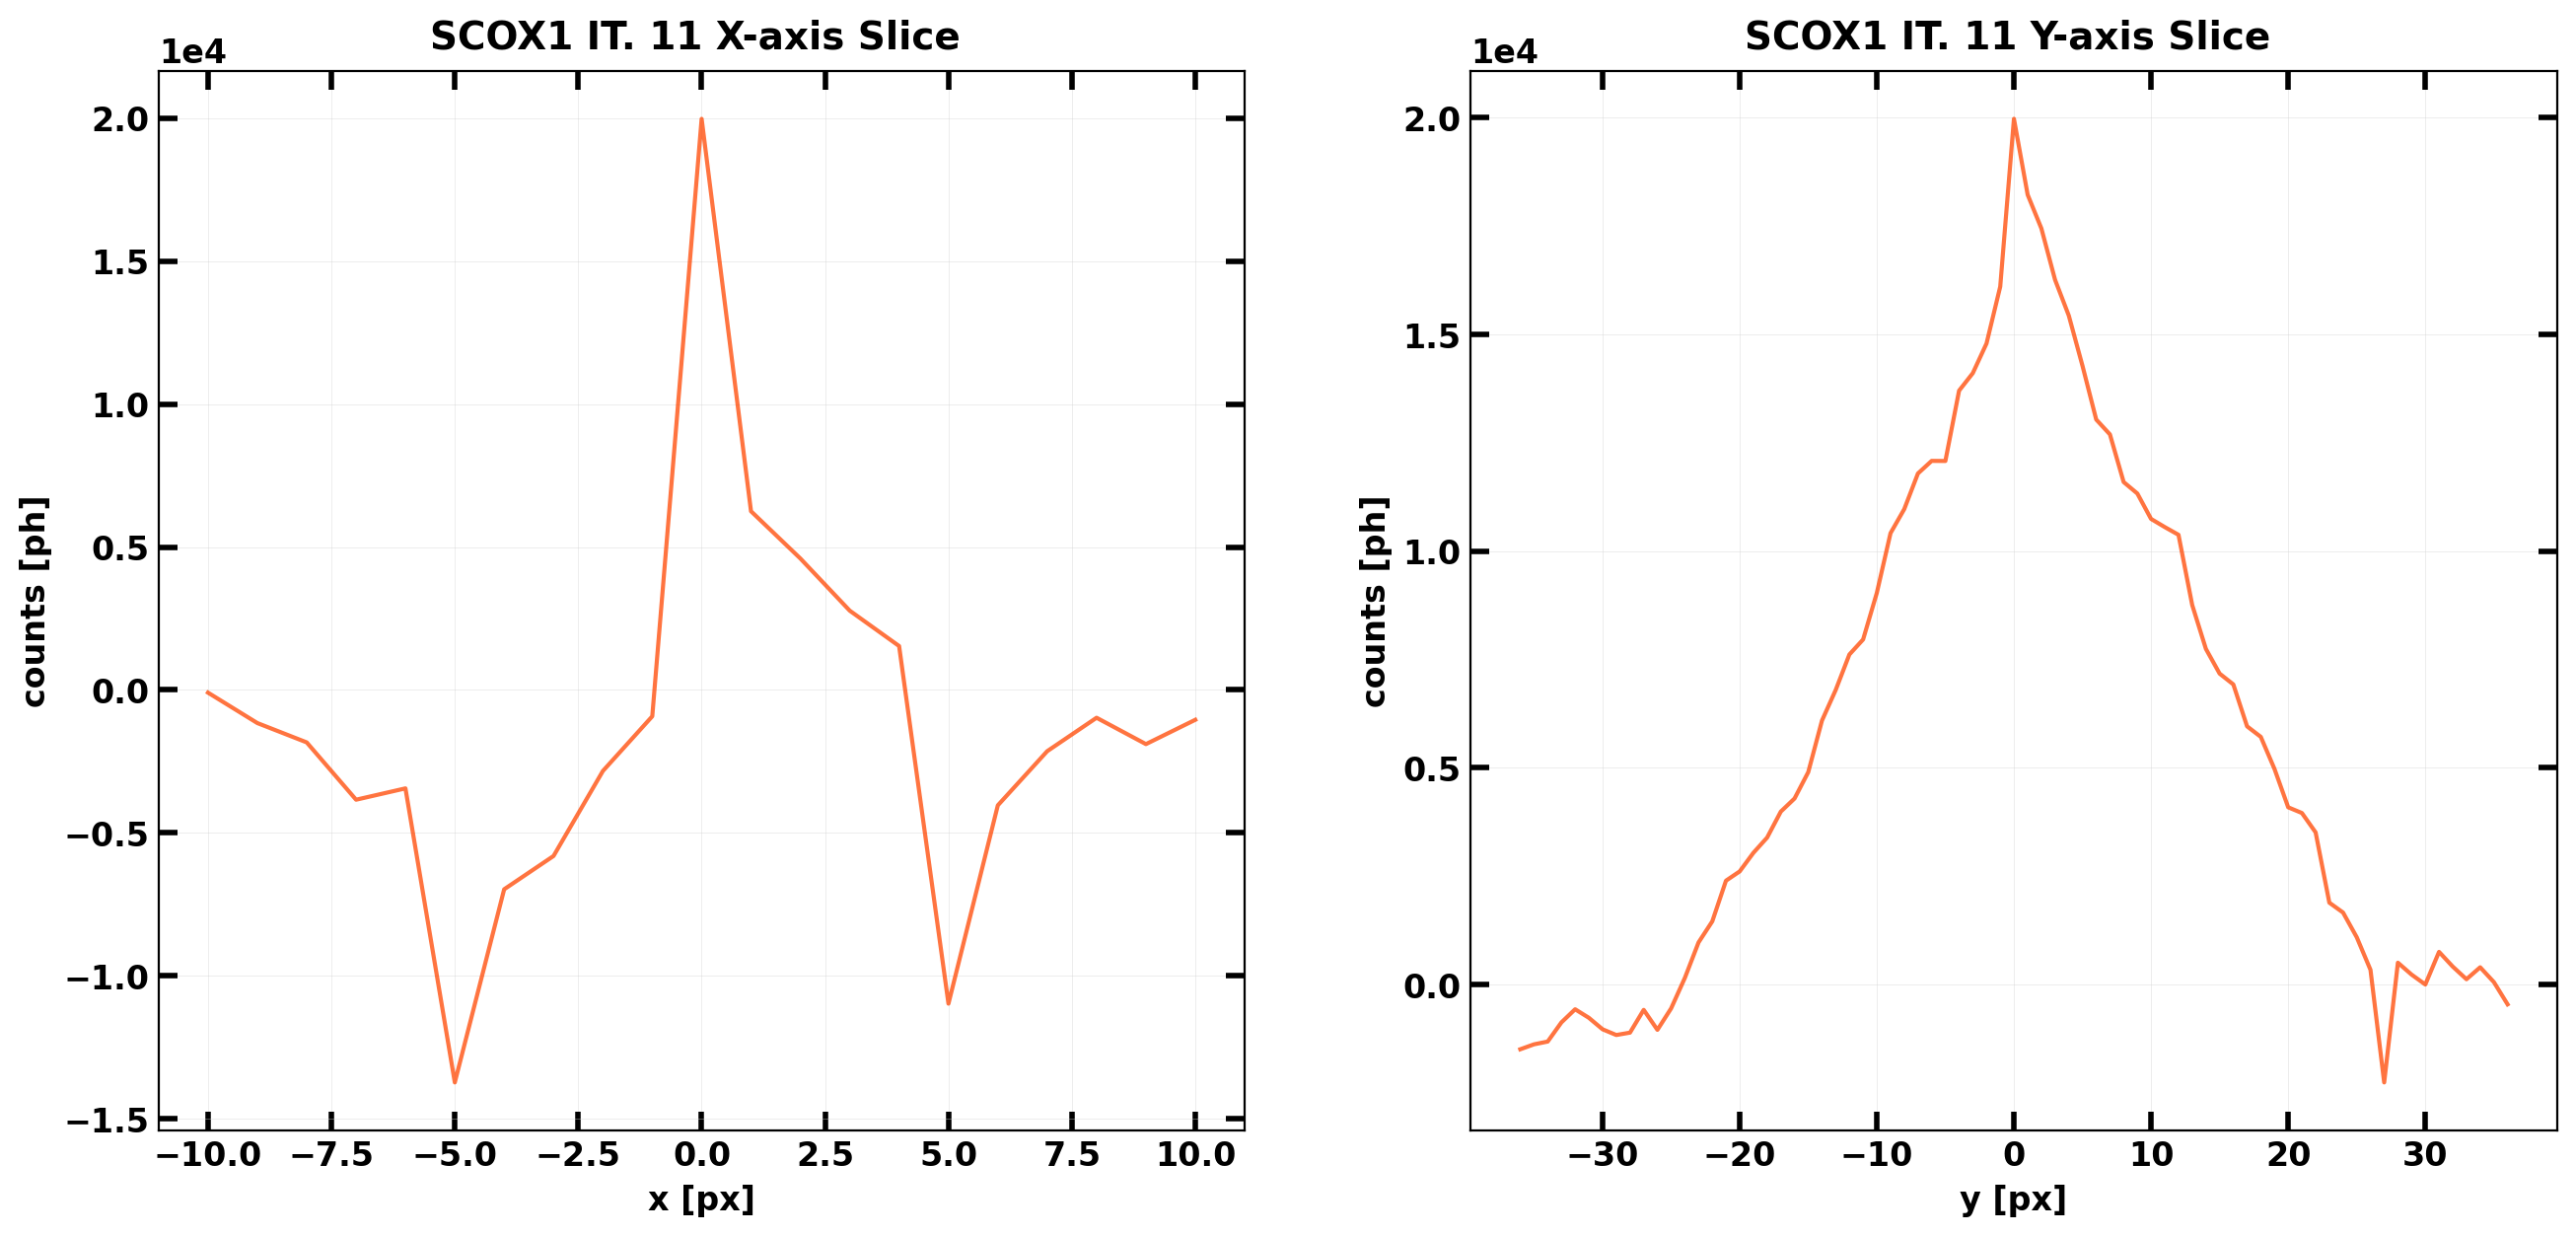

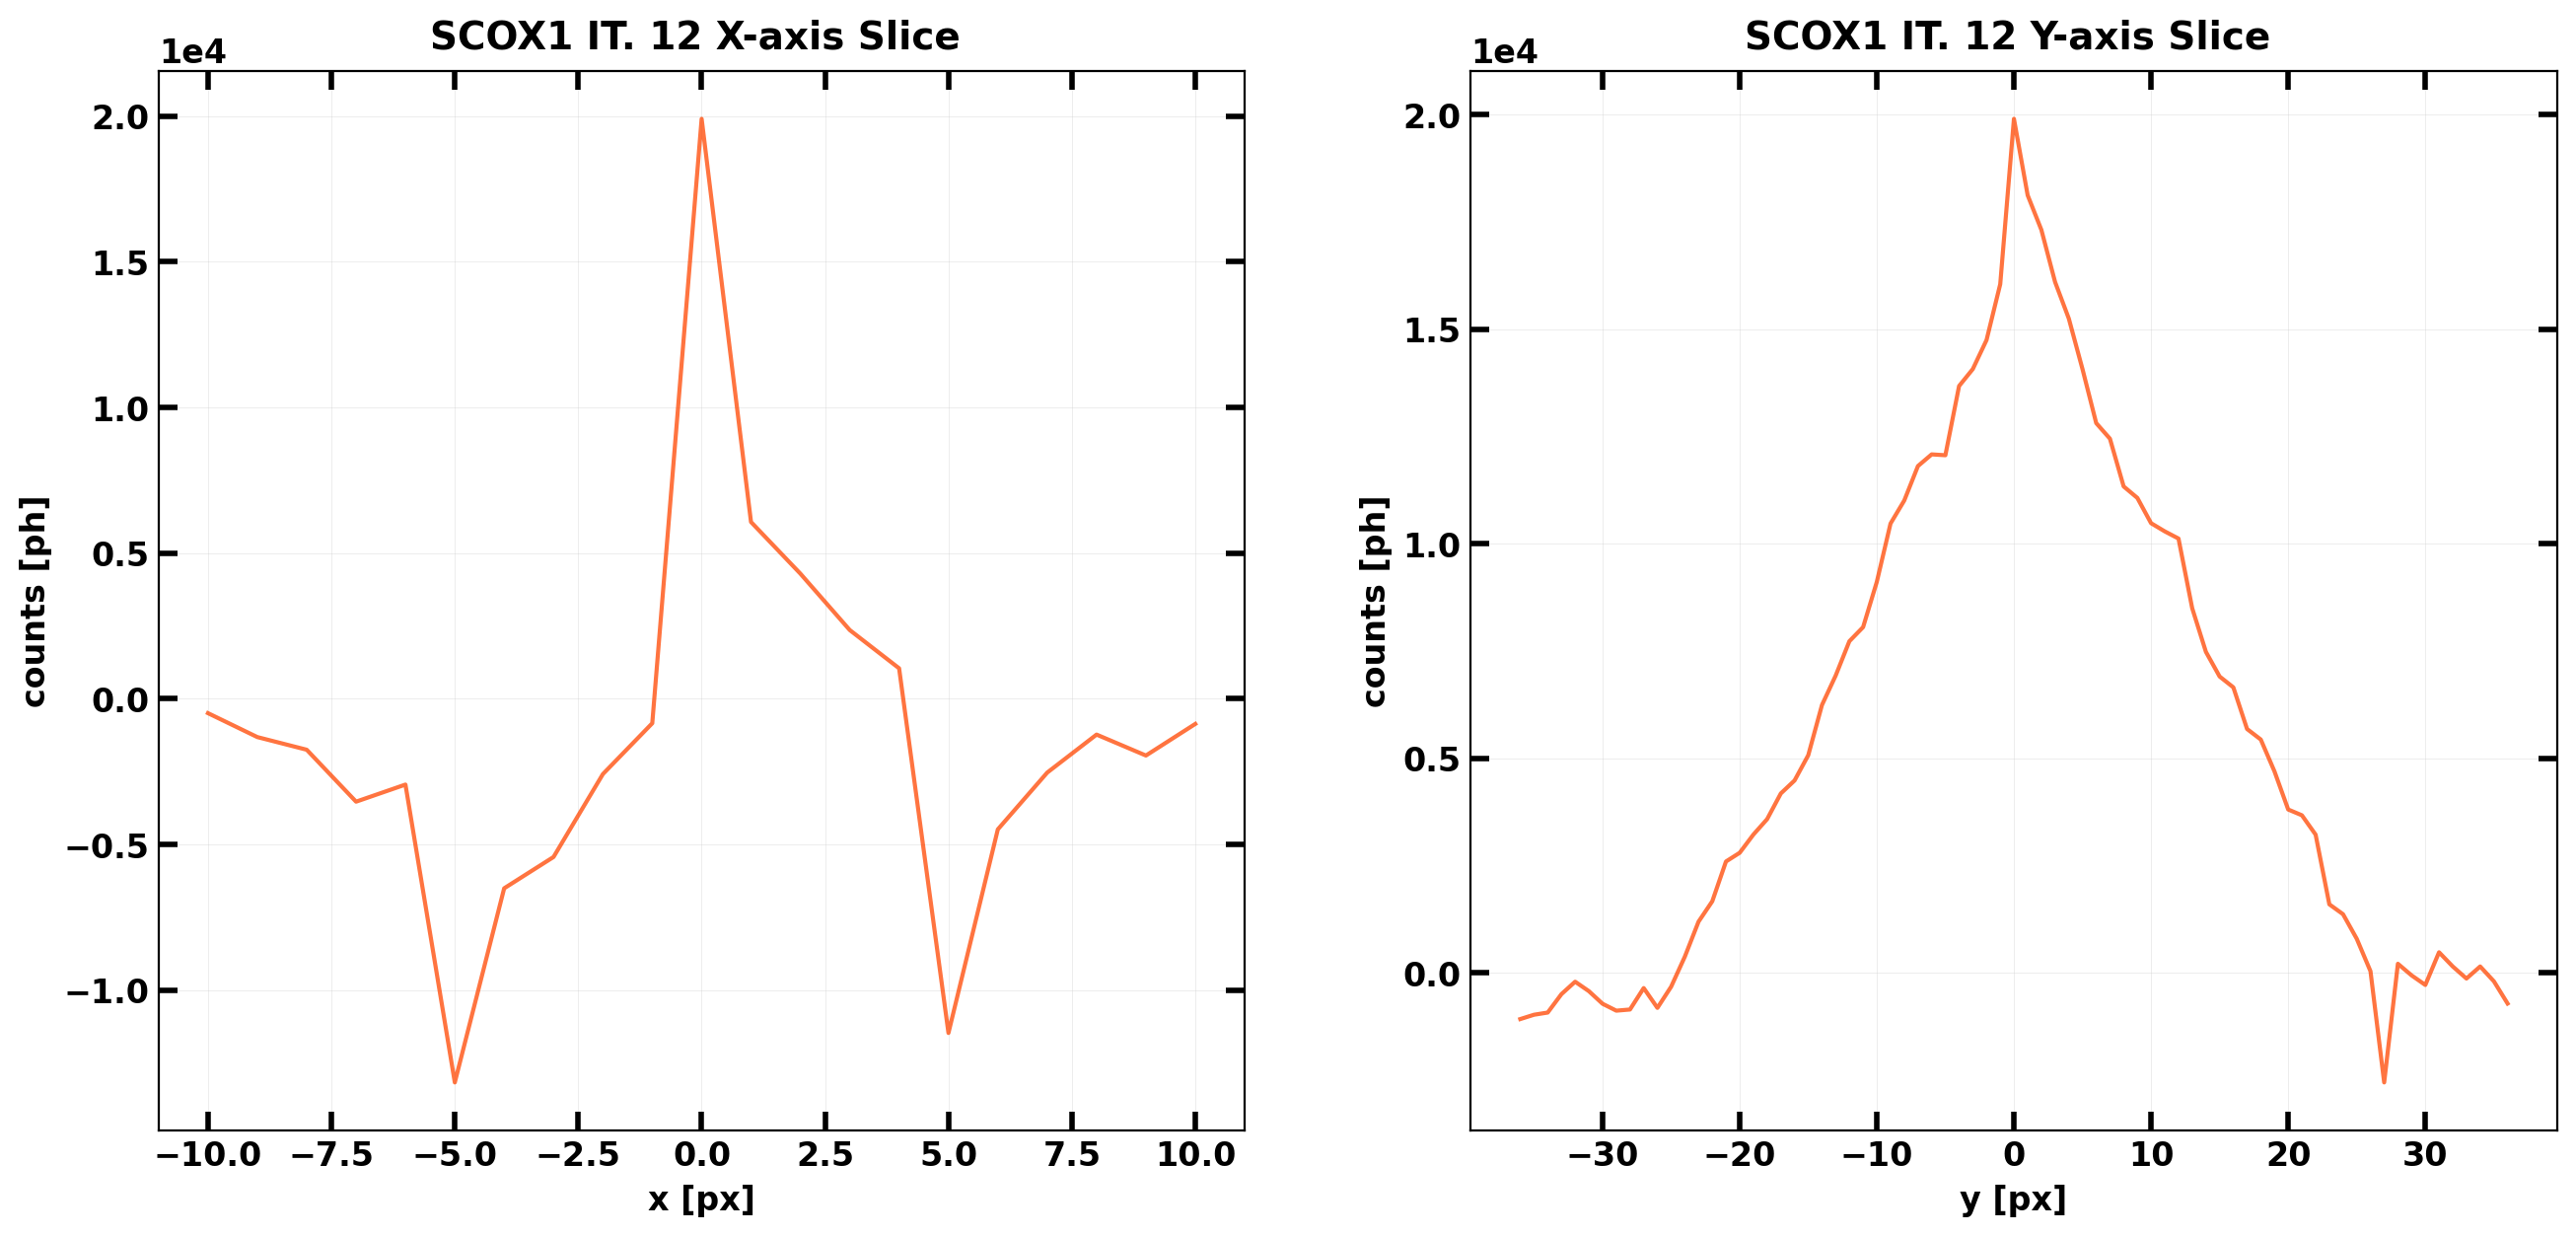

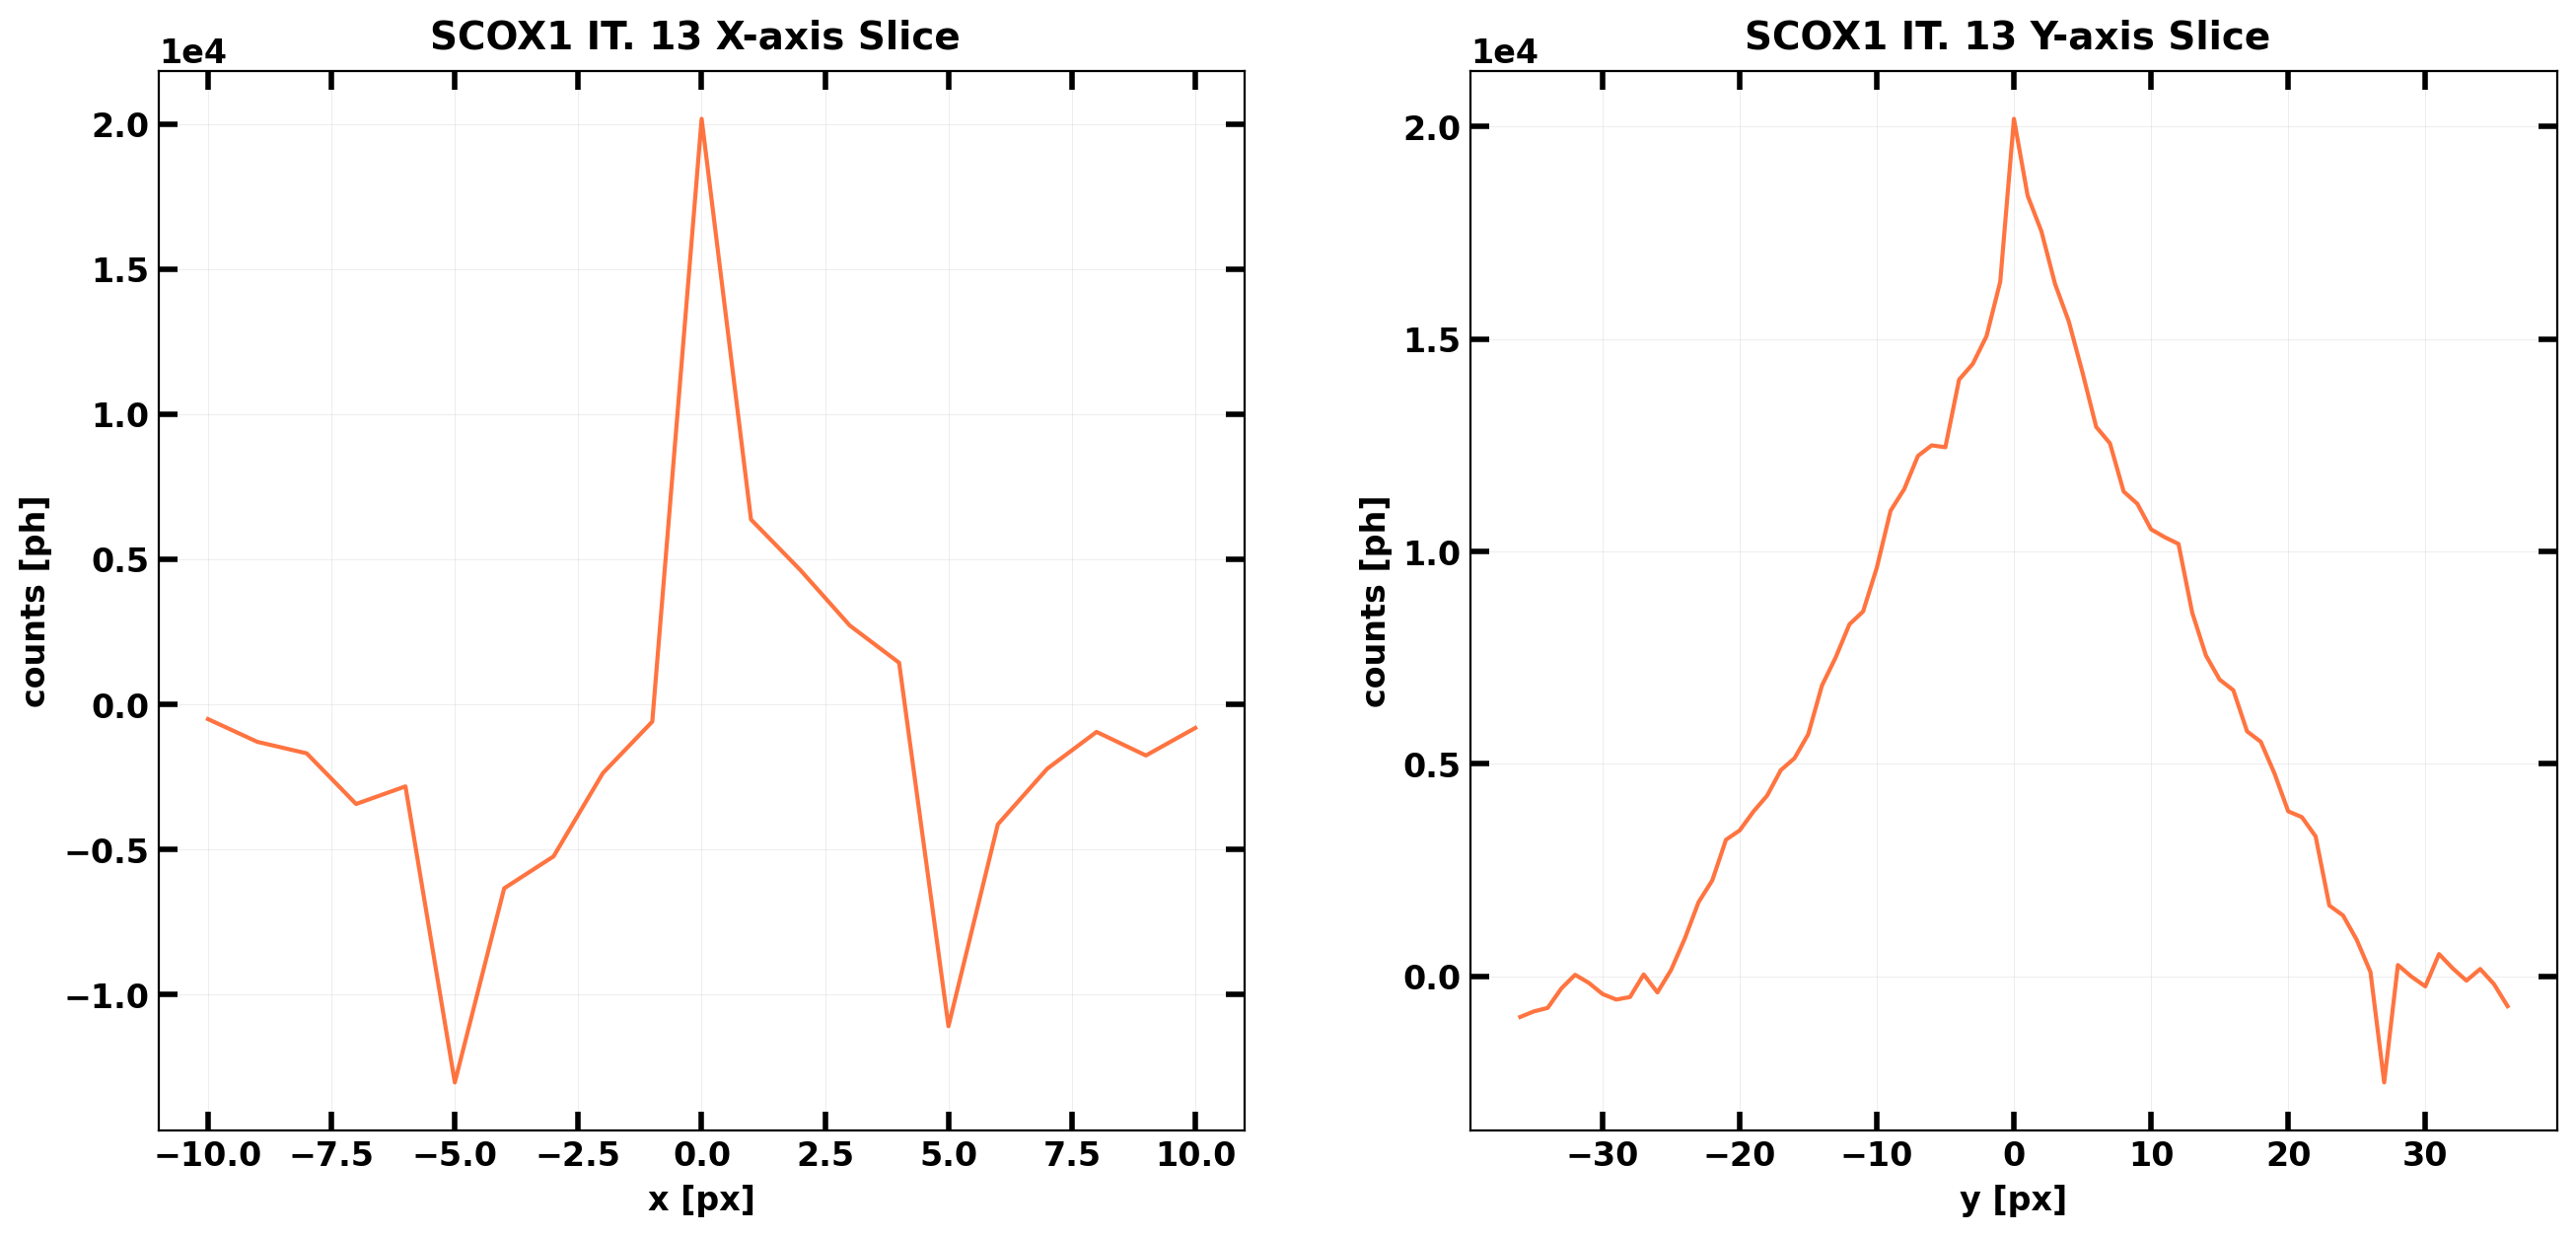

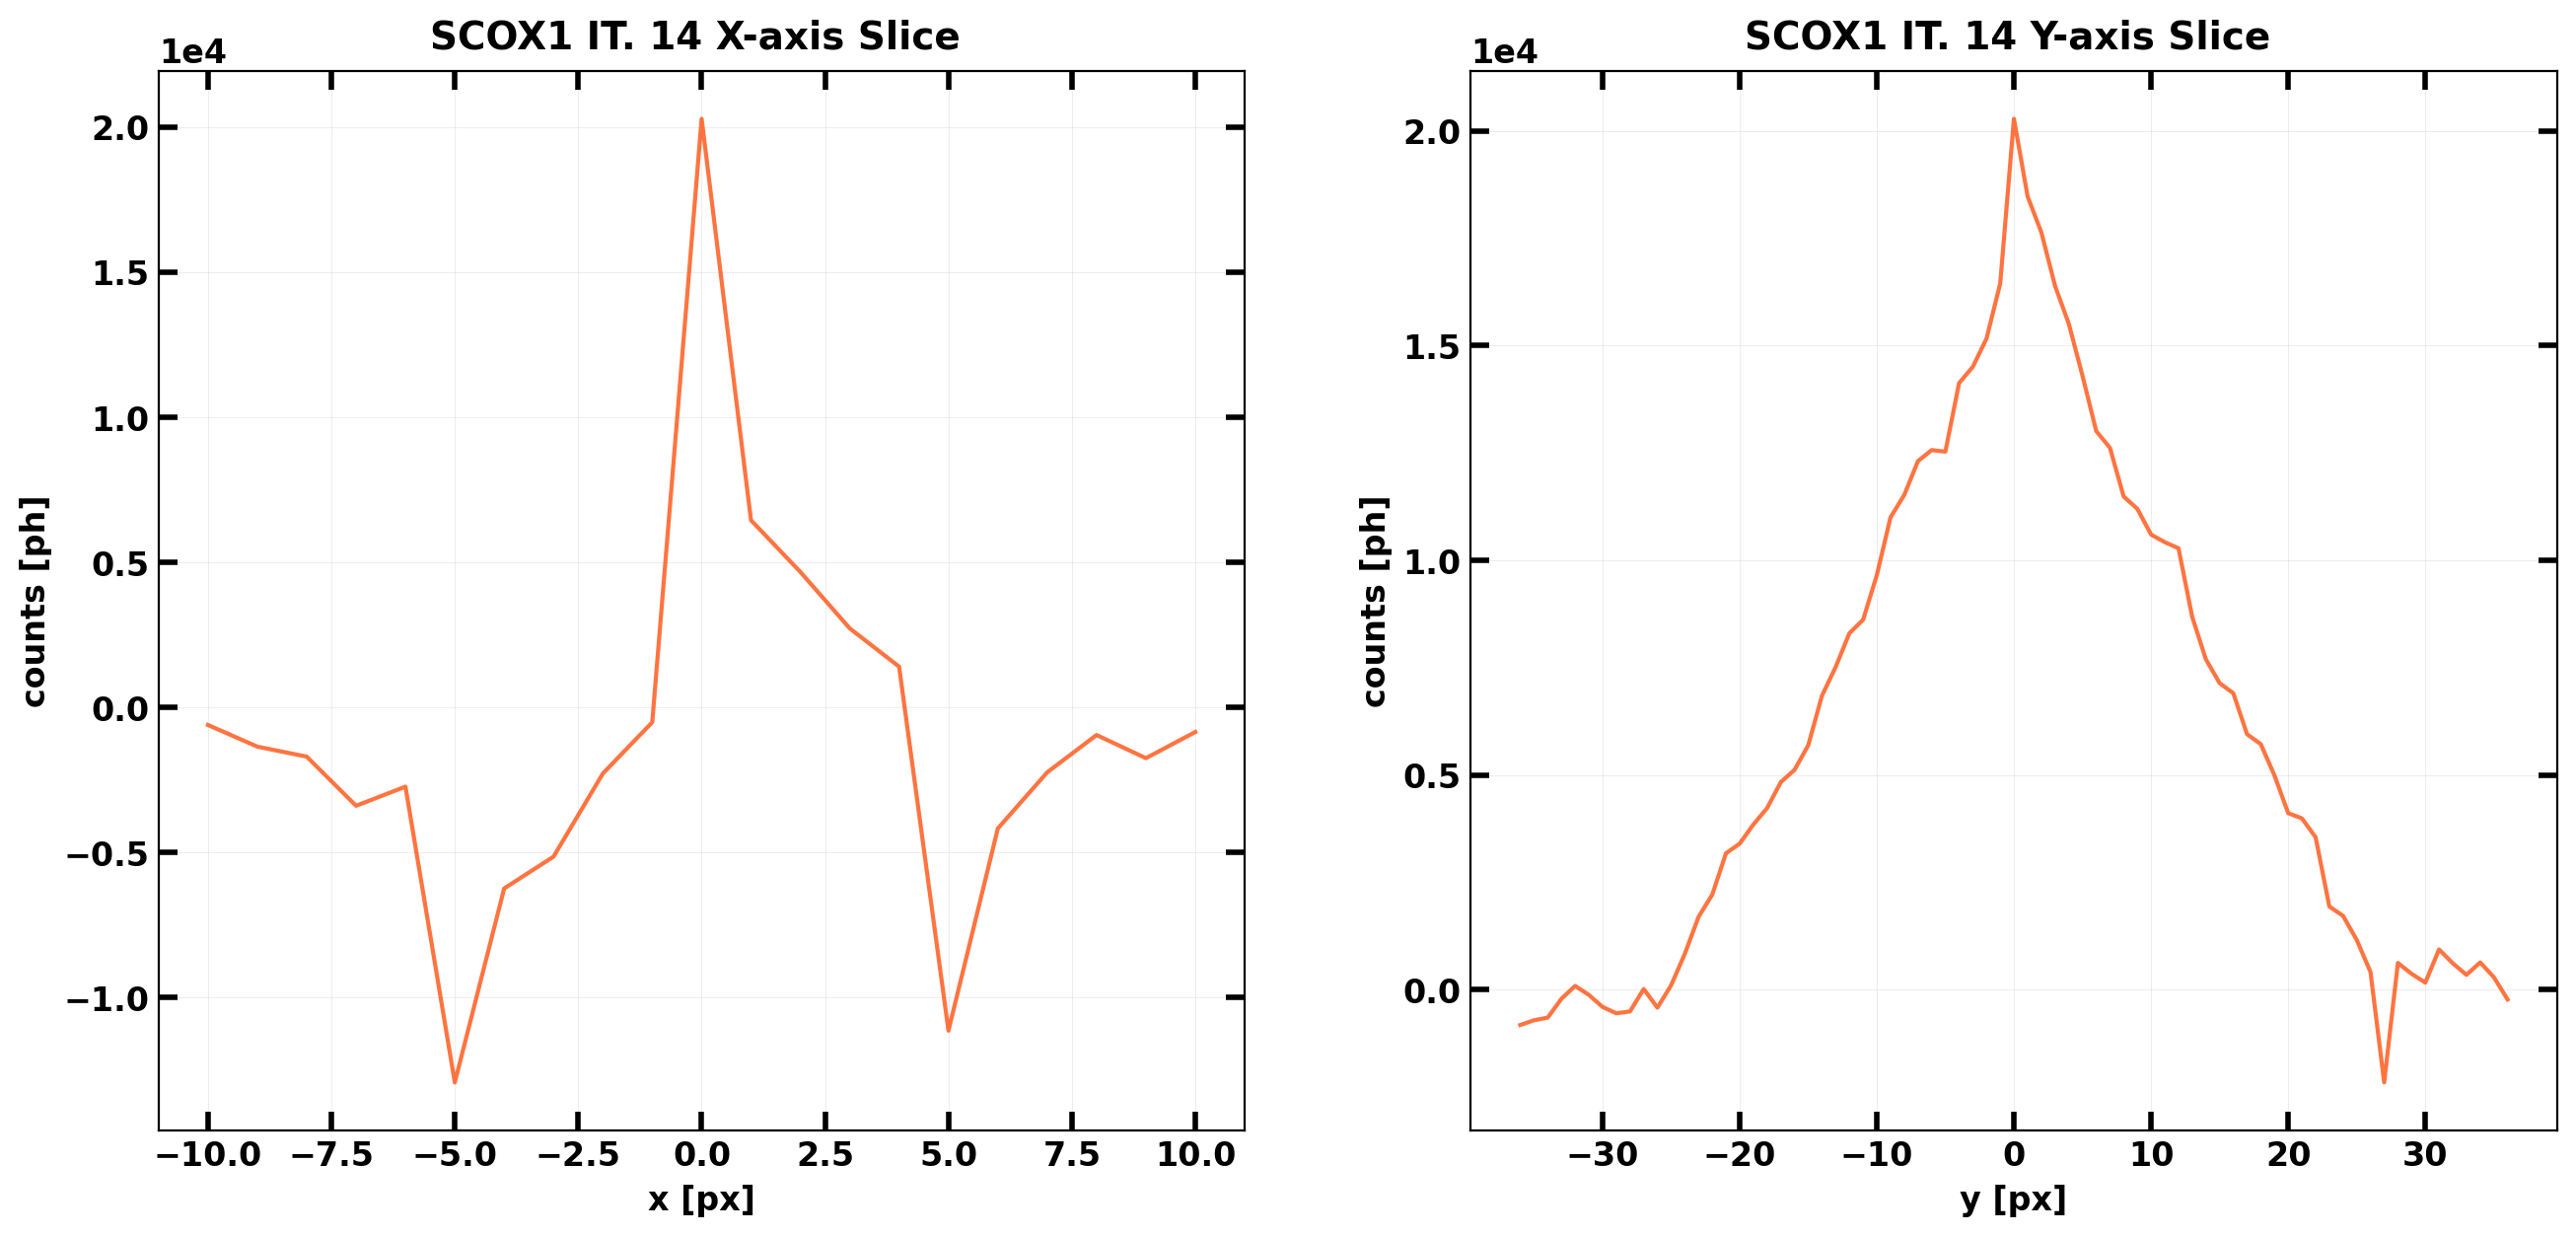

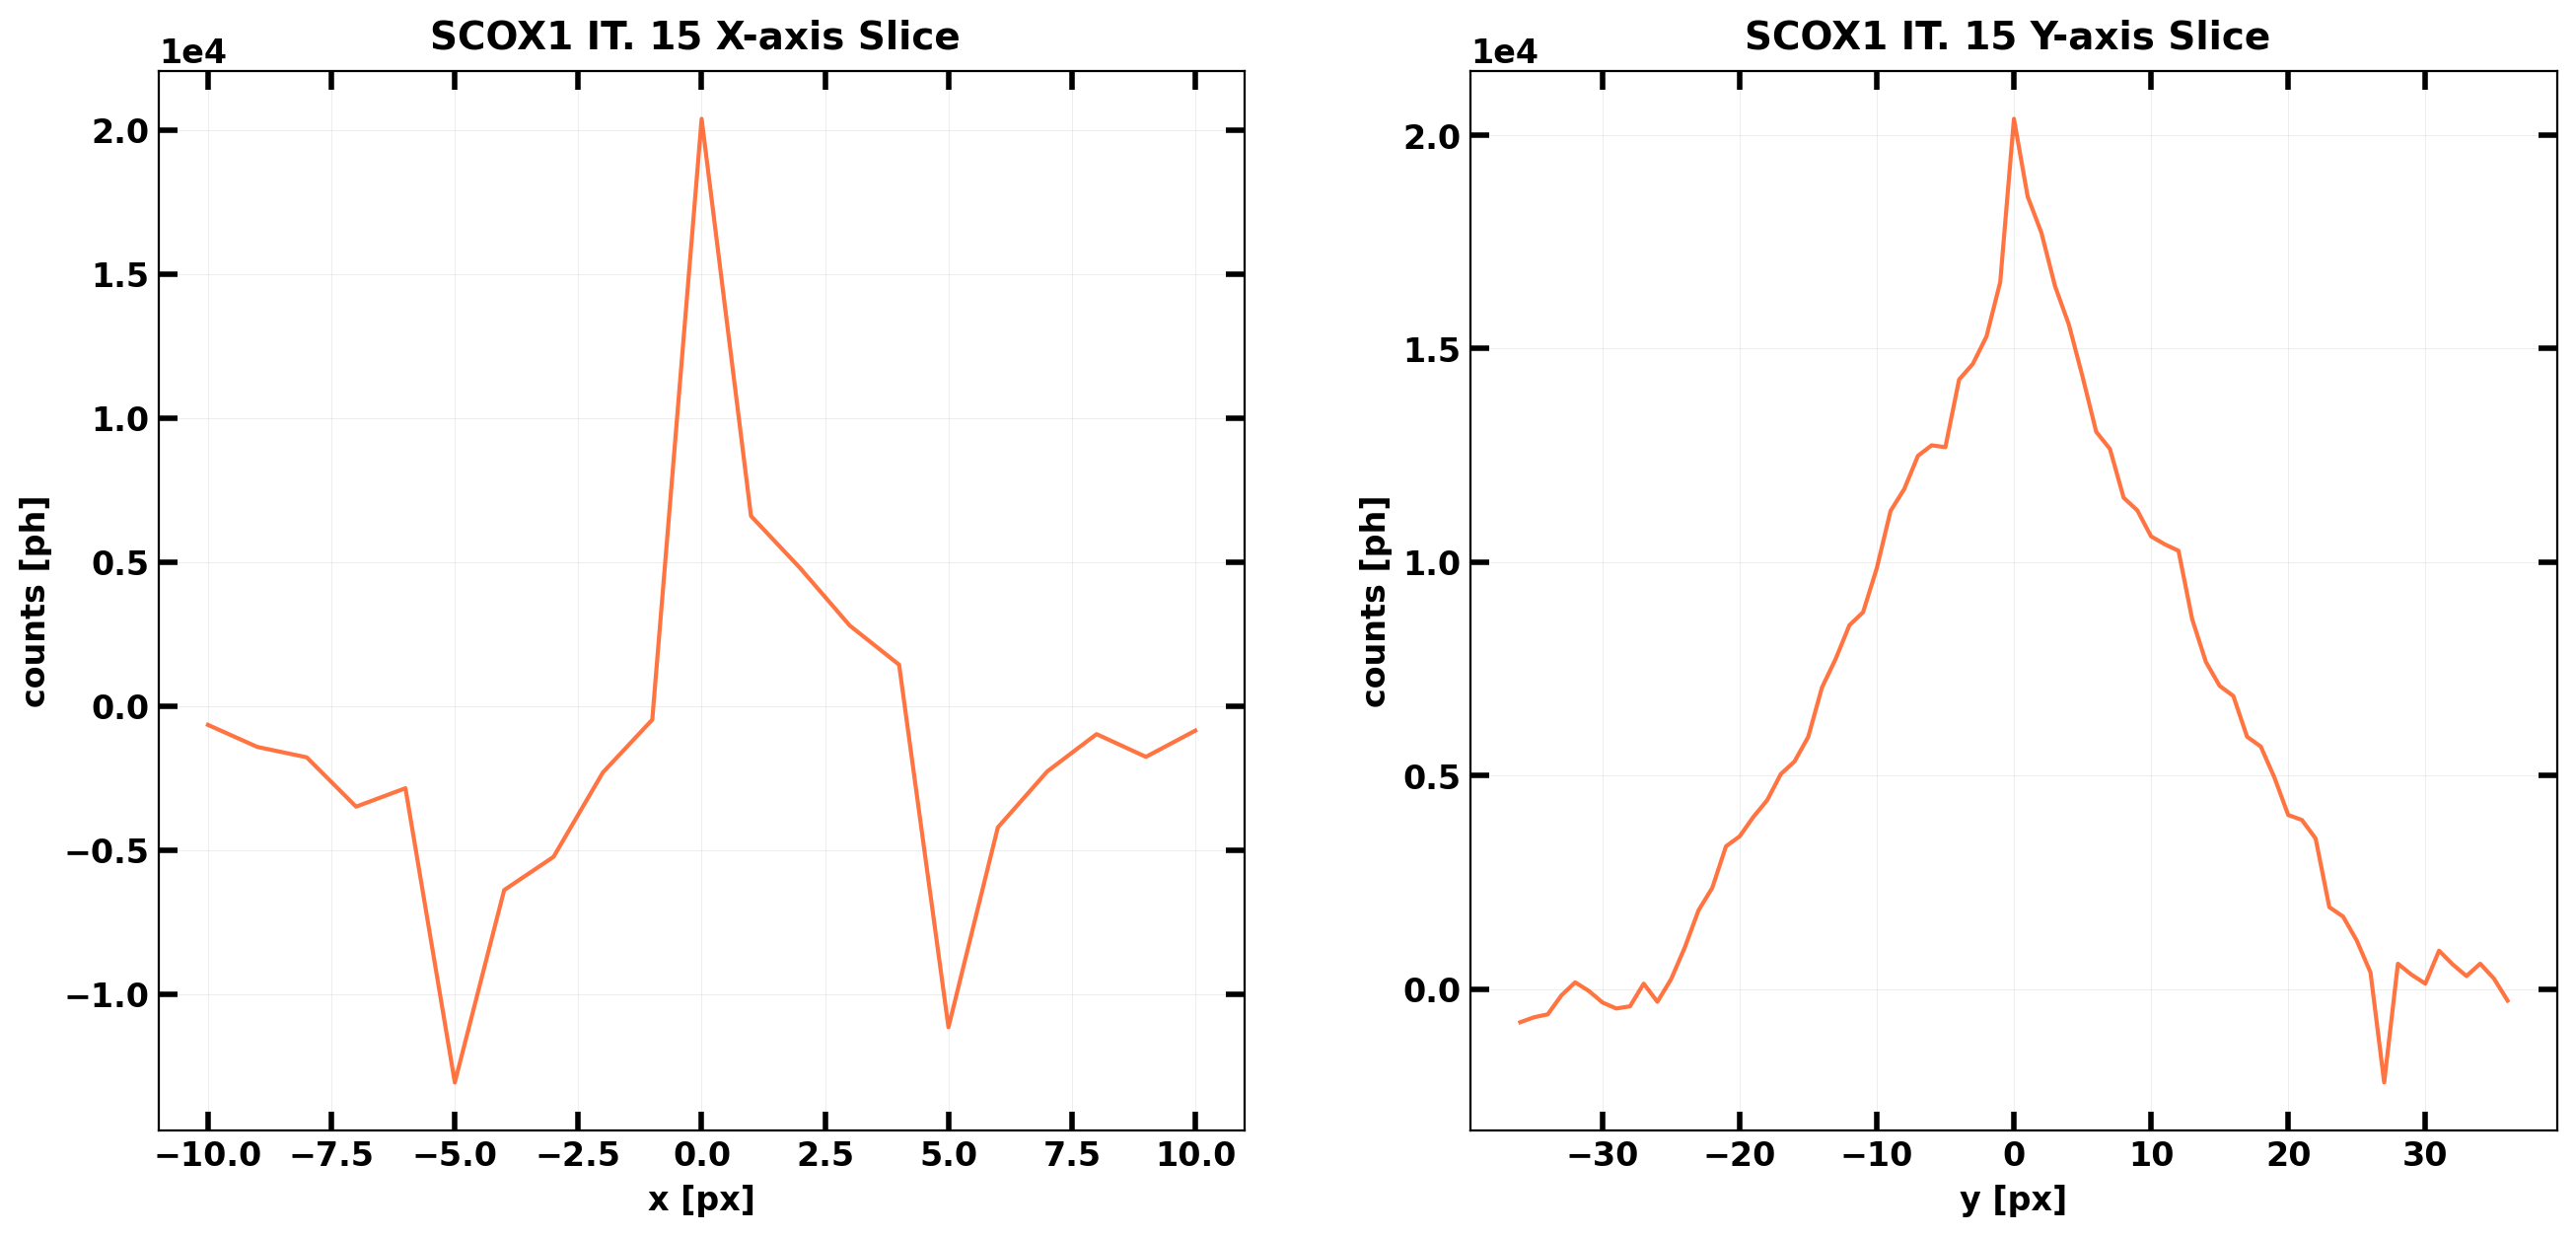

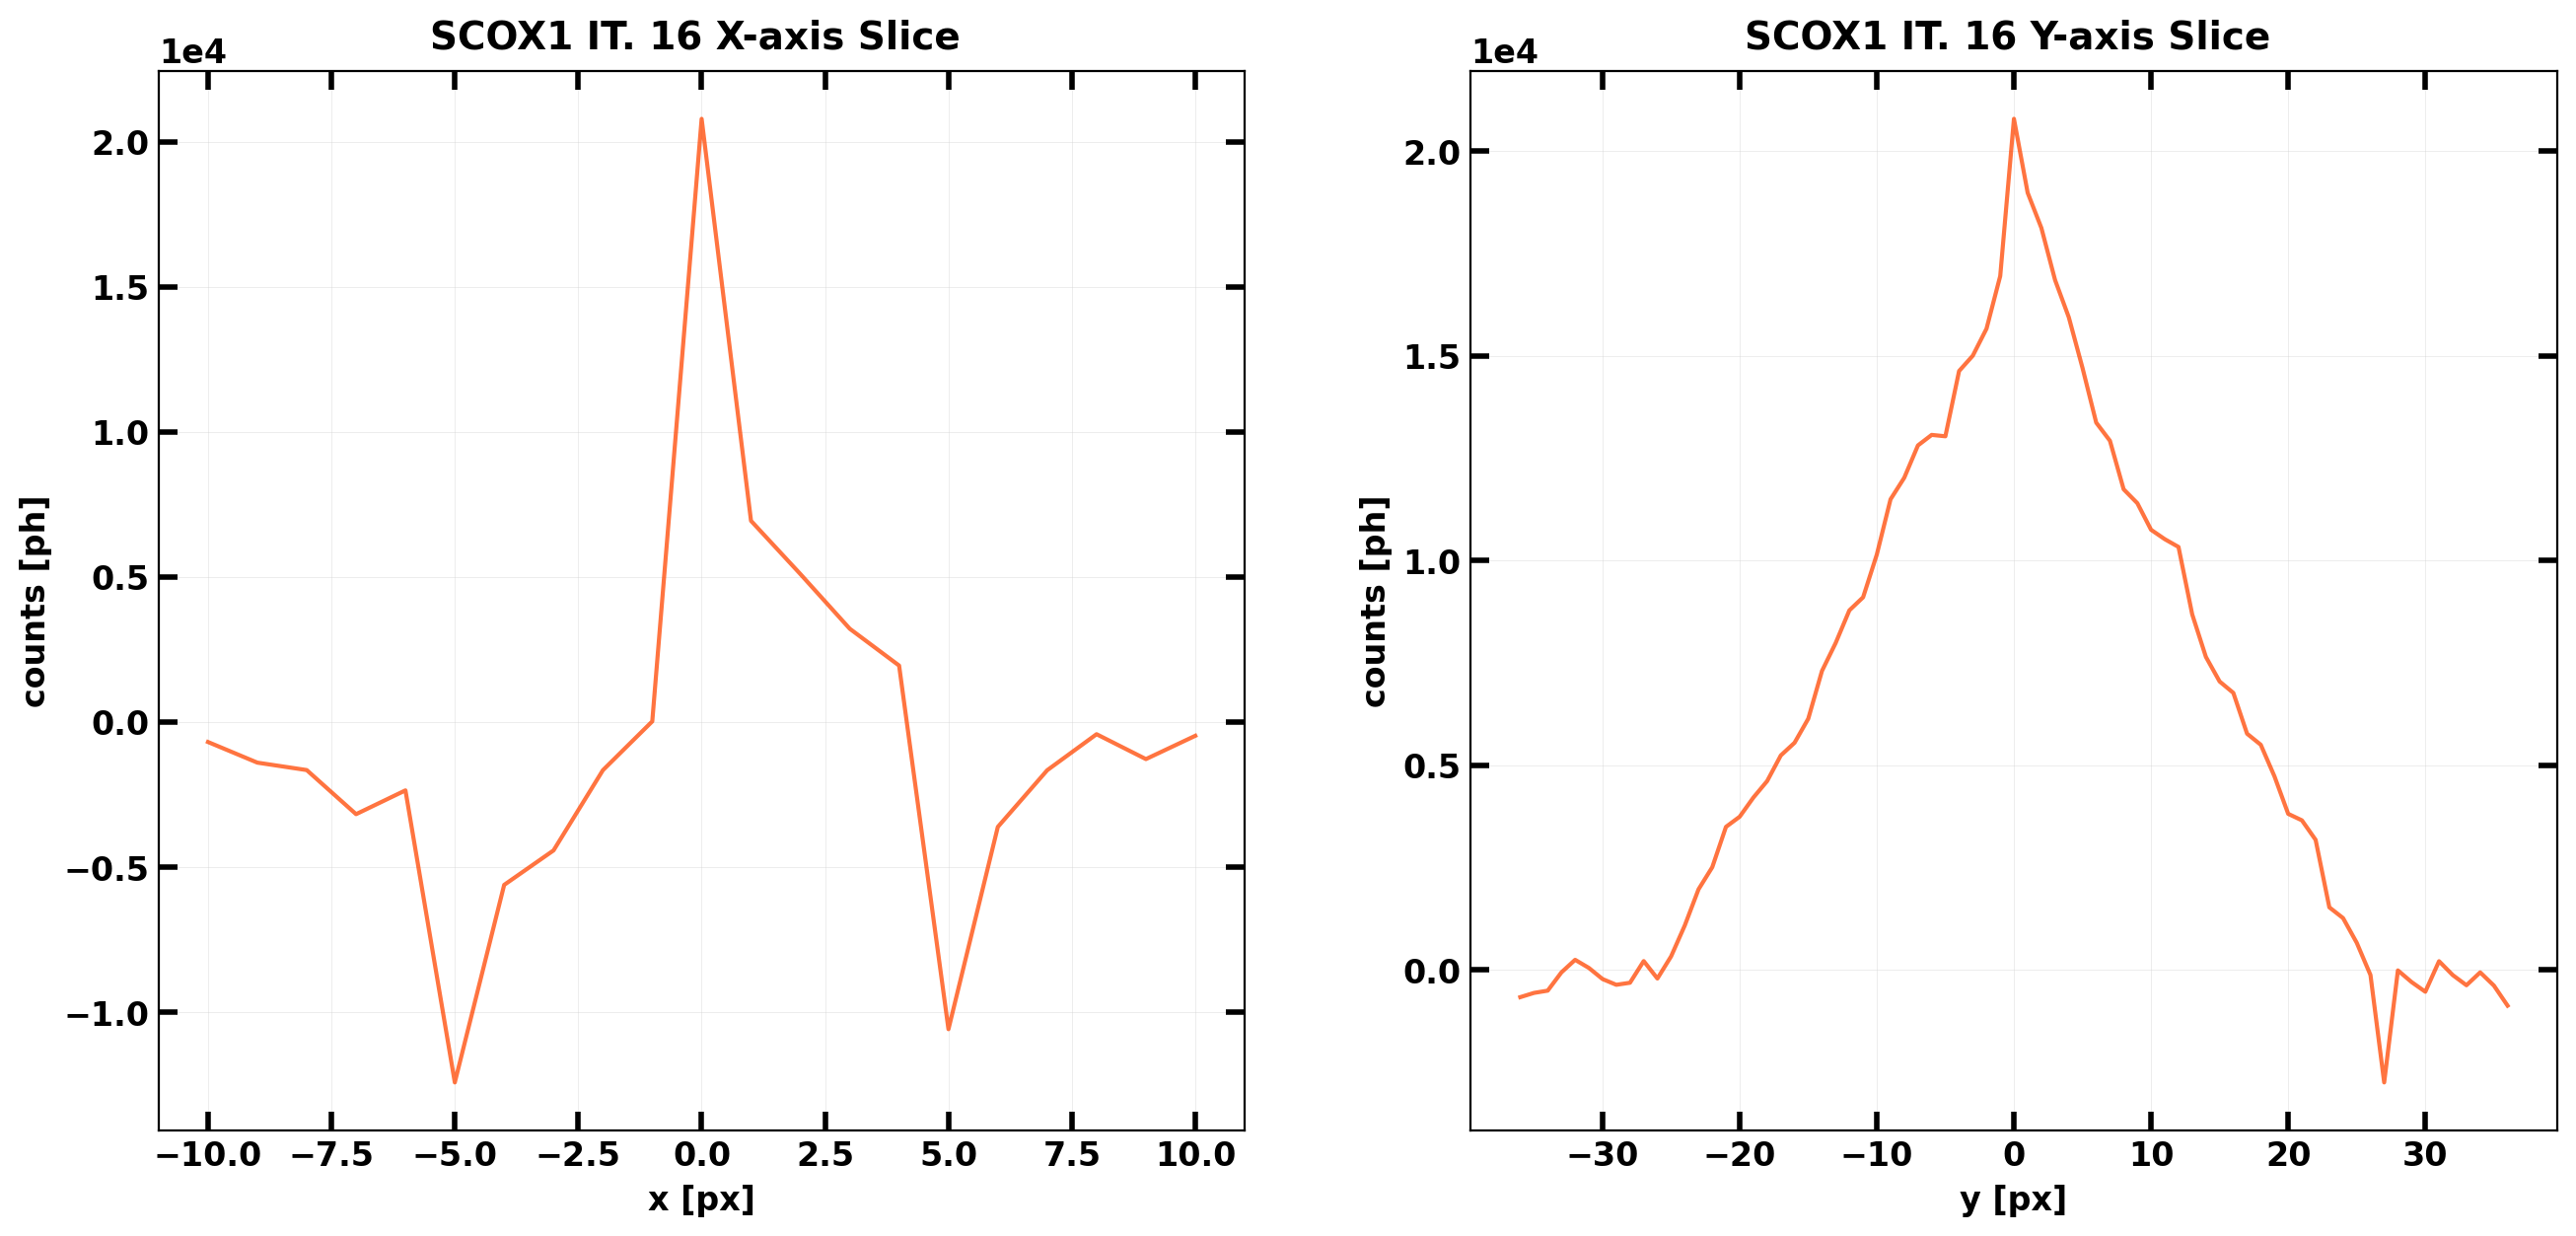

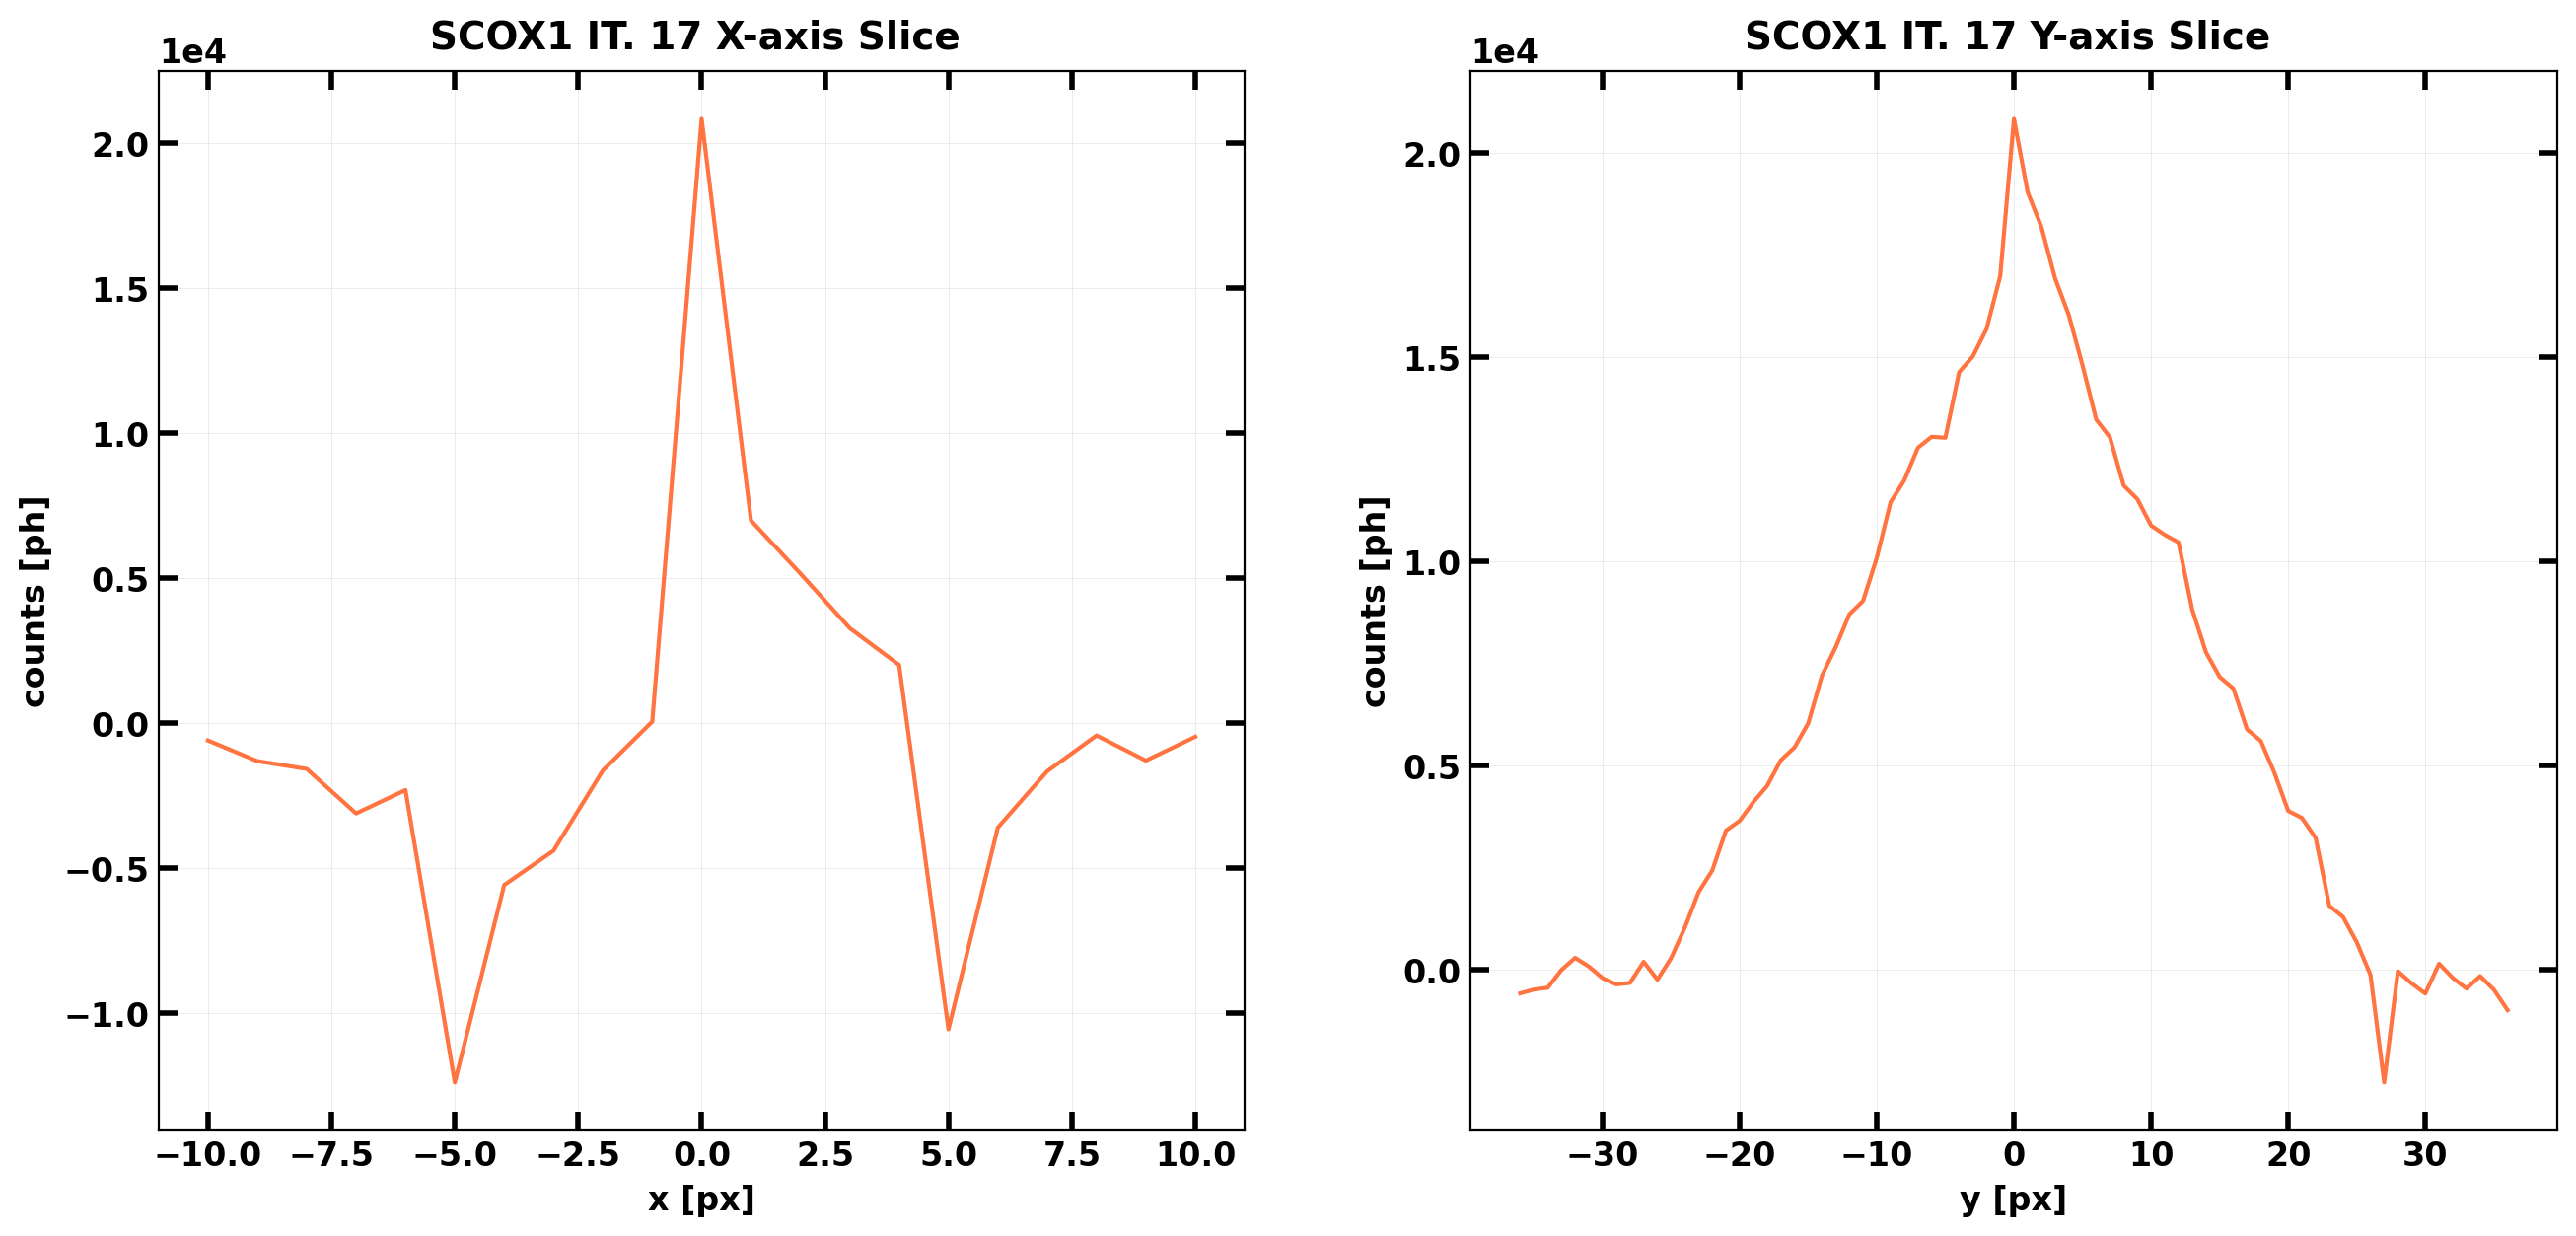

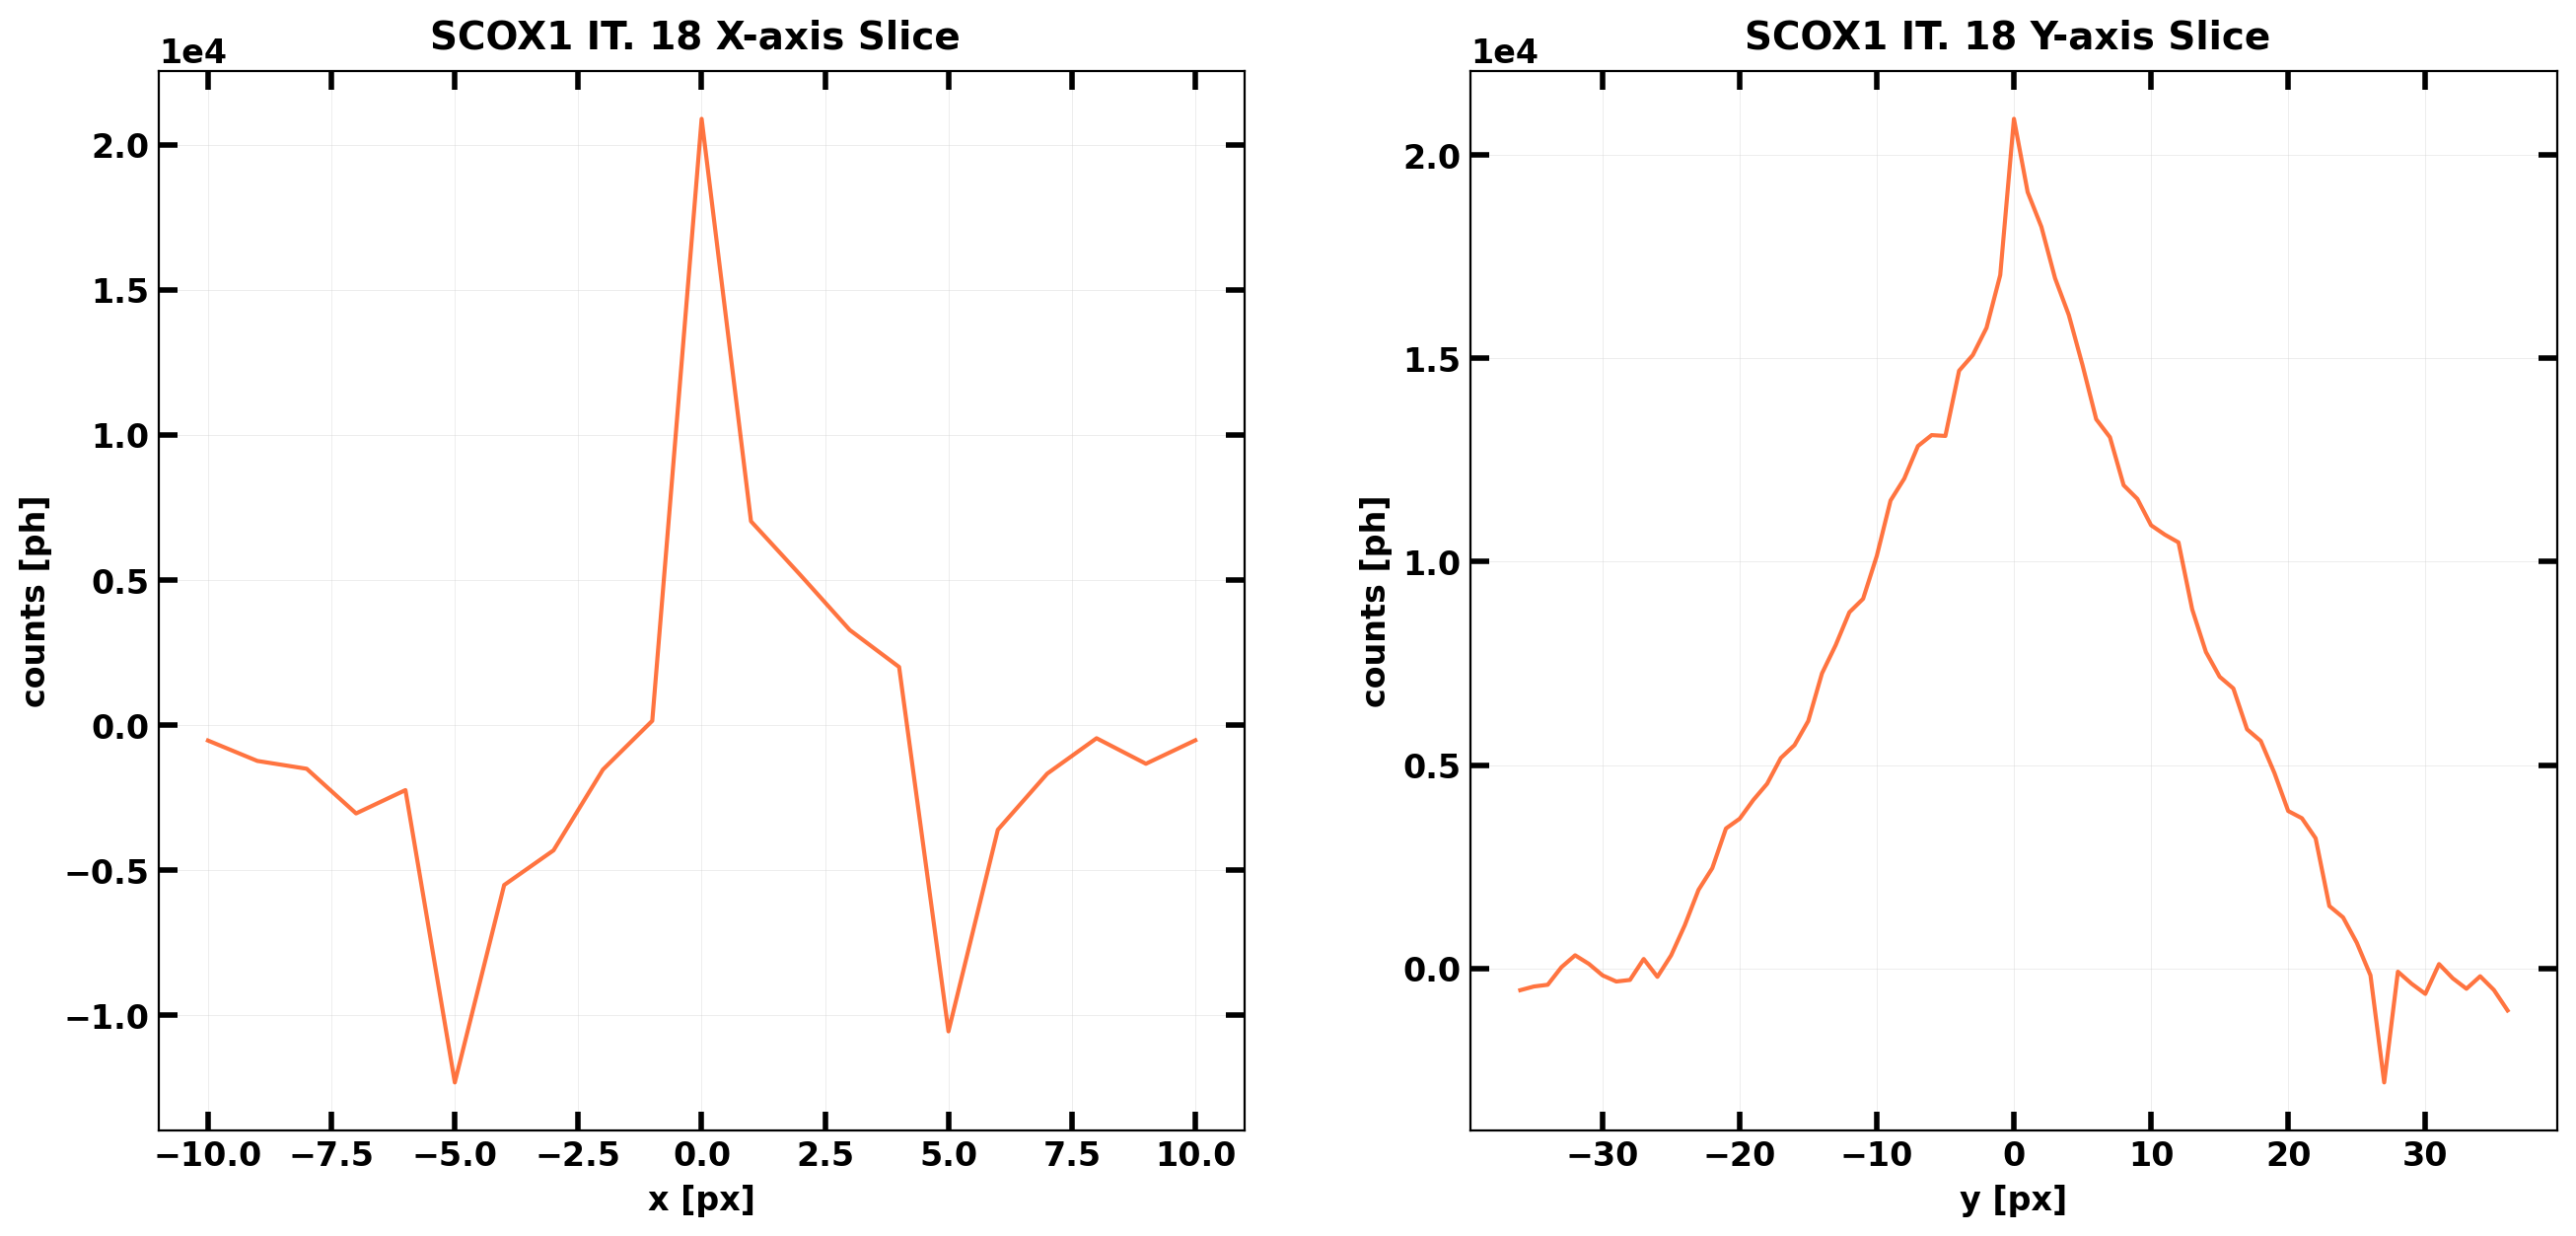

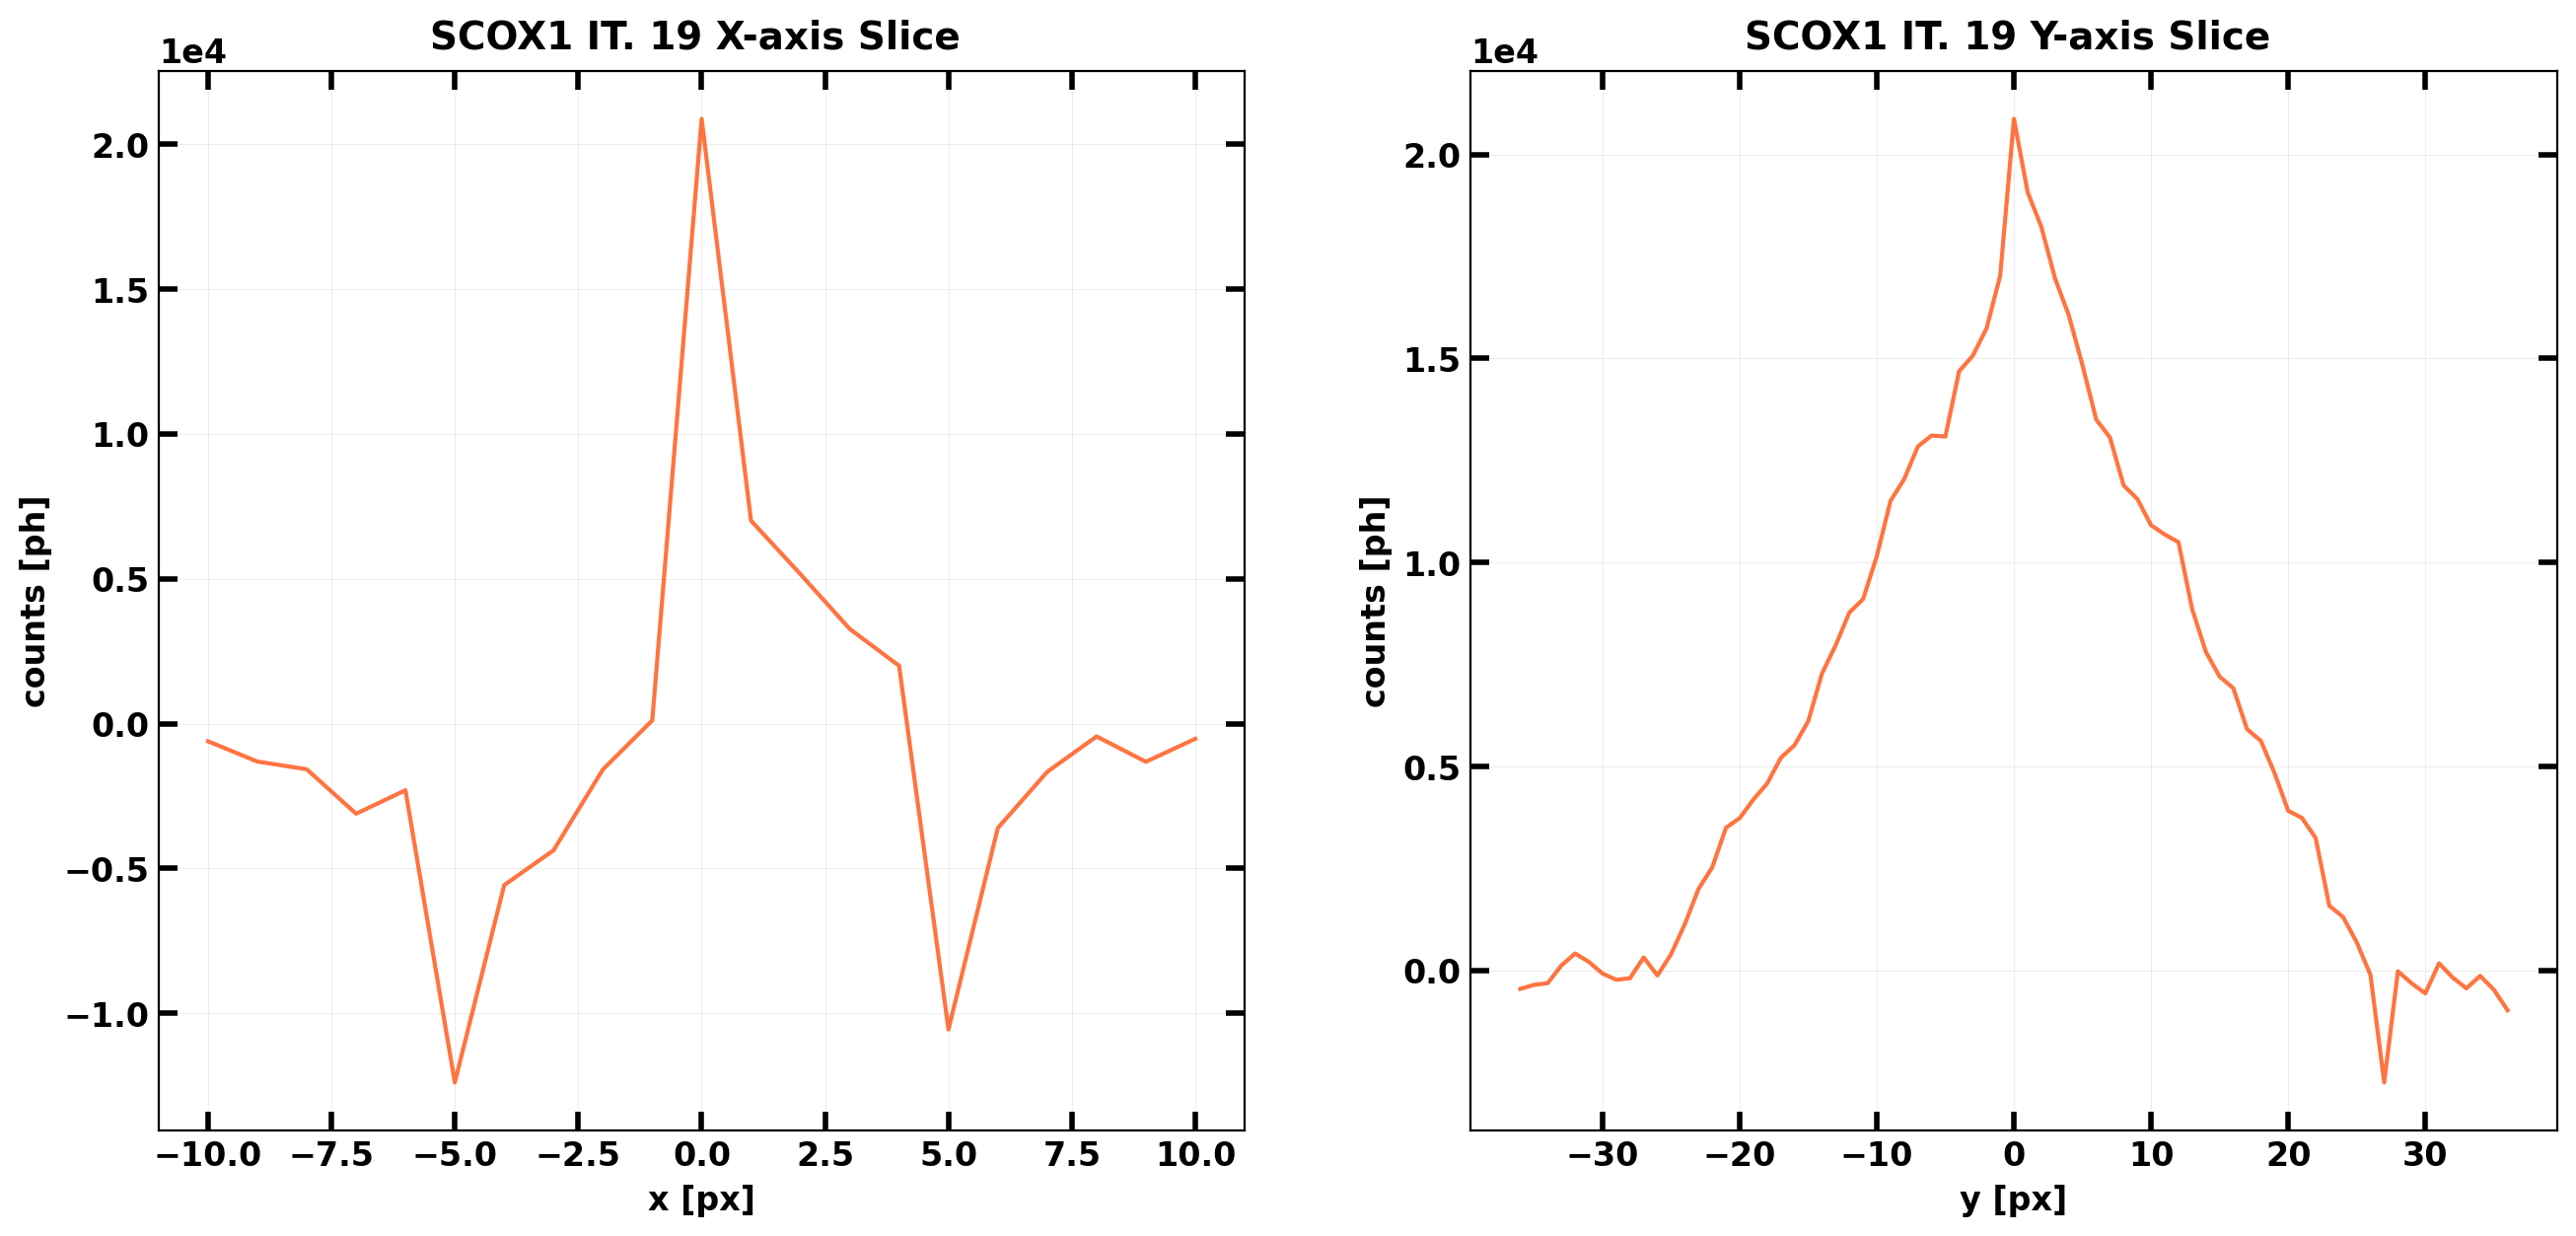

In [4]:
detector = count(wfm, sdlA.DLdata)[0]
varmap = sky_variance(wfm, detector)

locked_sources = (
    Tag(f'{log_camA.log['ID'][0]}', log_camA.log['y'][0], log_camA.log['x'][0]),
    Tag(f'{log_camA.log['ID'][-1]}', log_camA.log['y'][-1], log_camA.log['x'][-1]),
)

cropy, cropx = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)

source_profile_during_IROS(
    candidates=candidates,
    true_sky=simul_sky_camA,
    variance=varmap,
    lock_source=locked_sources[0],
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)

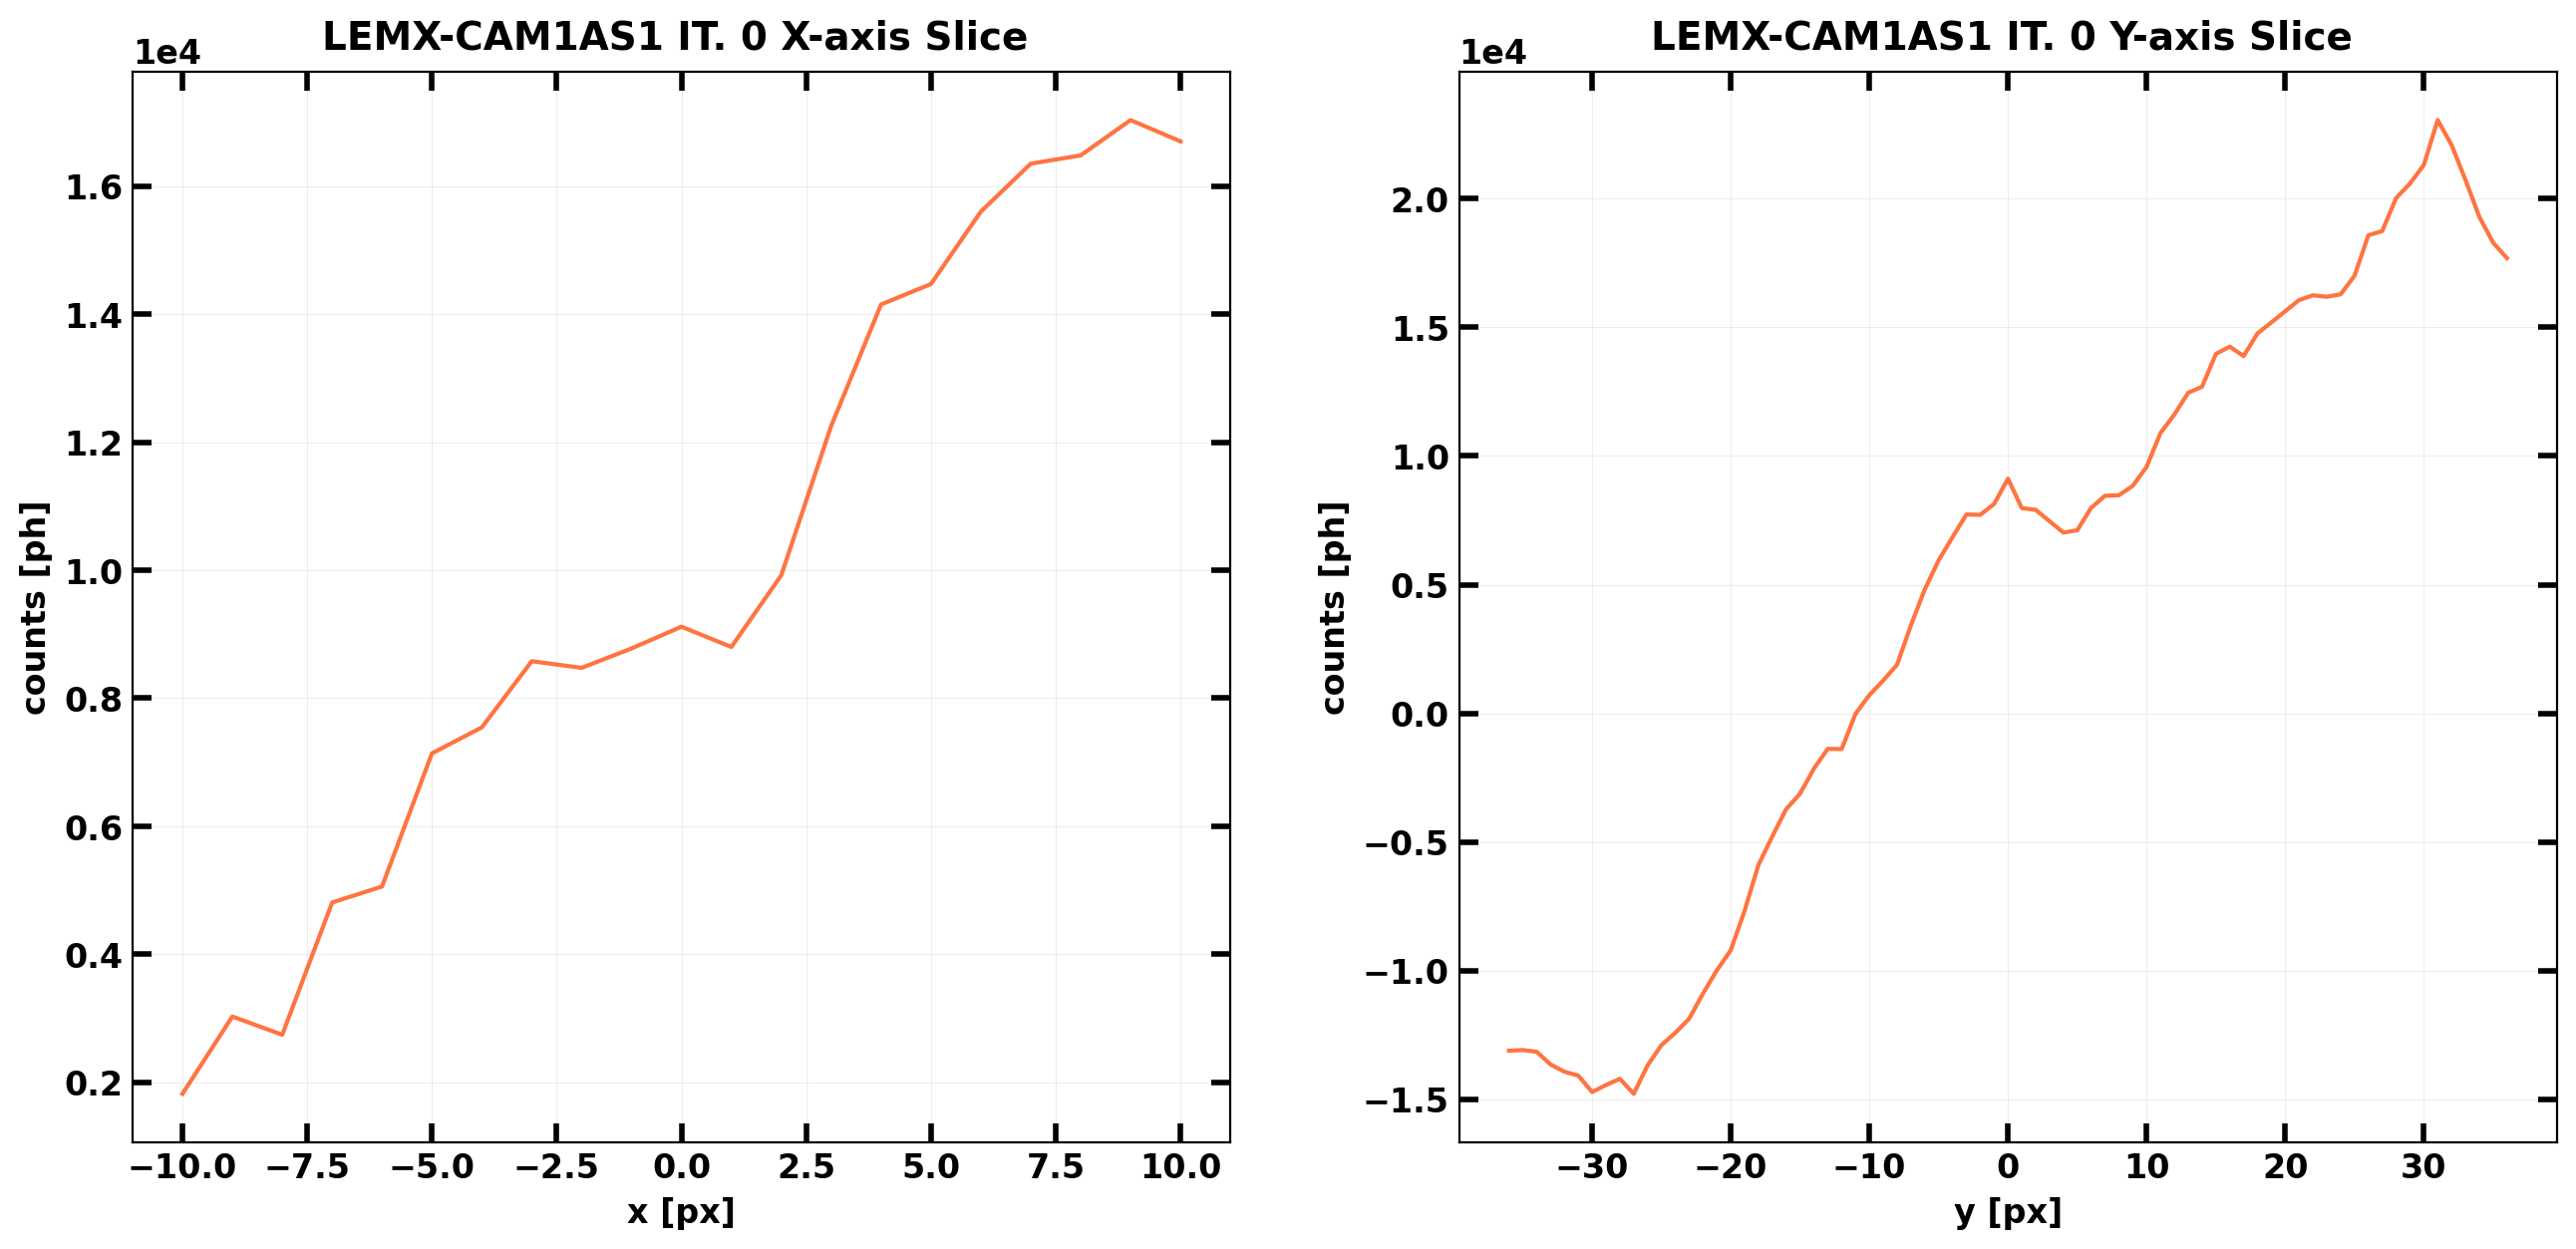

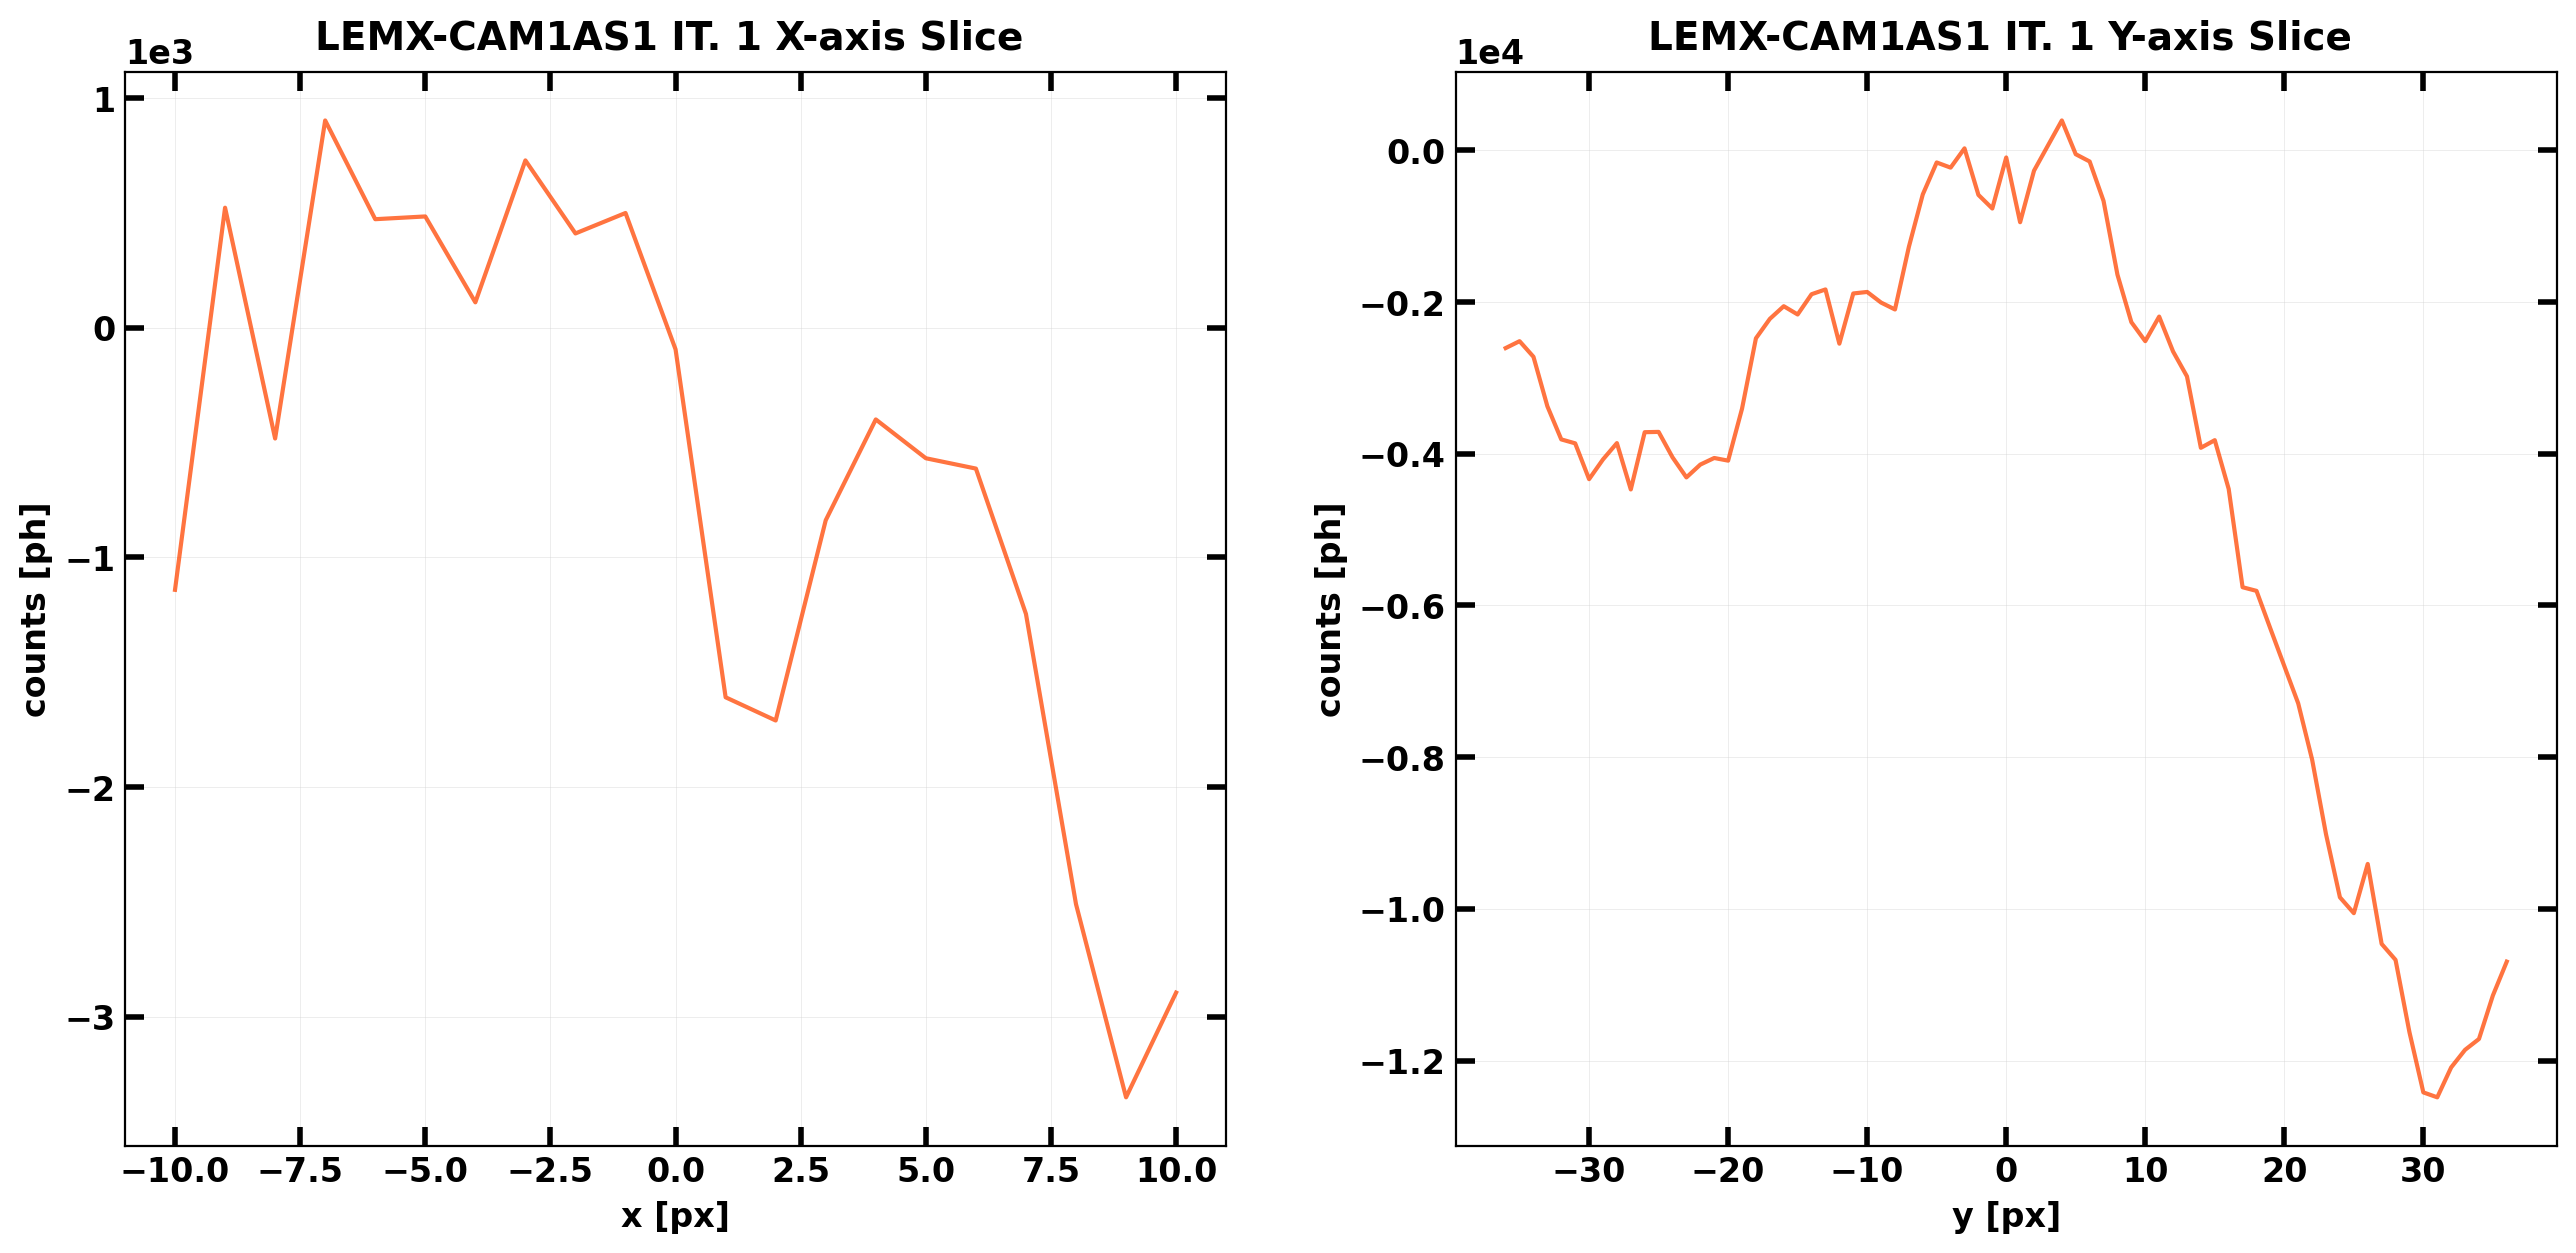

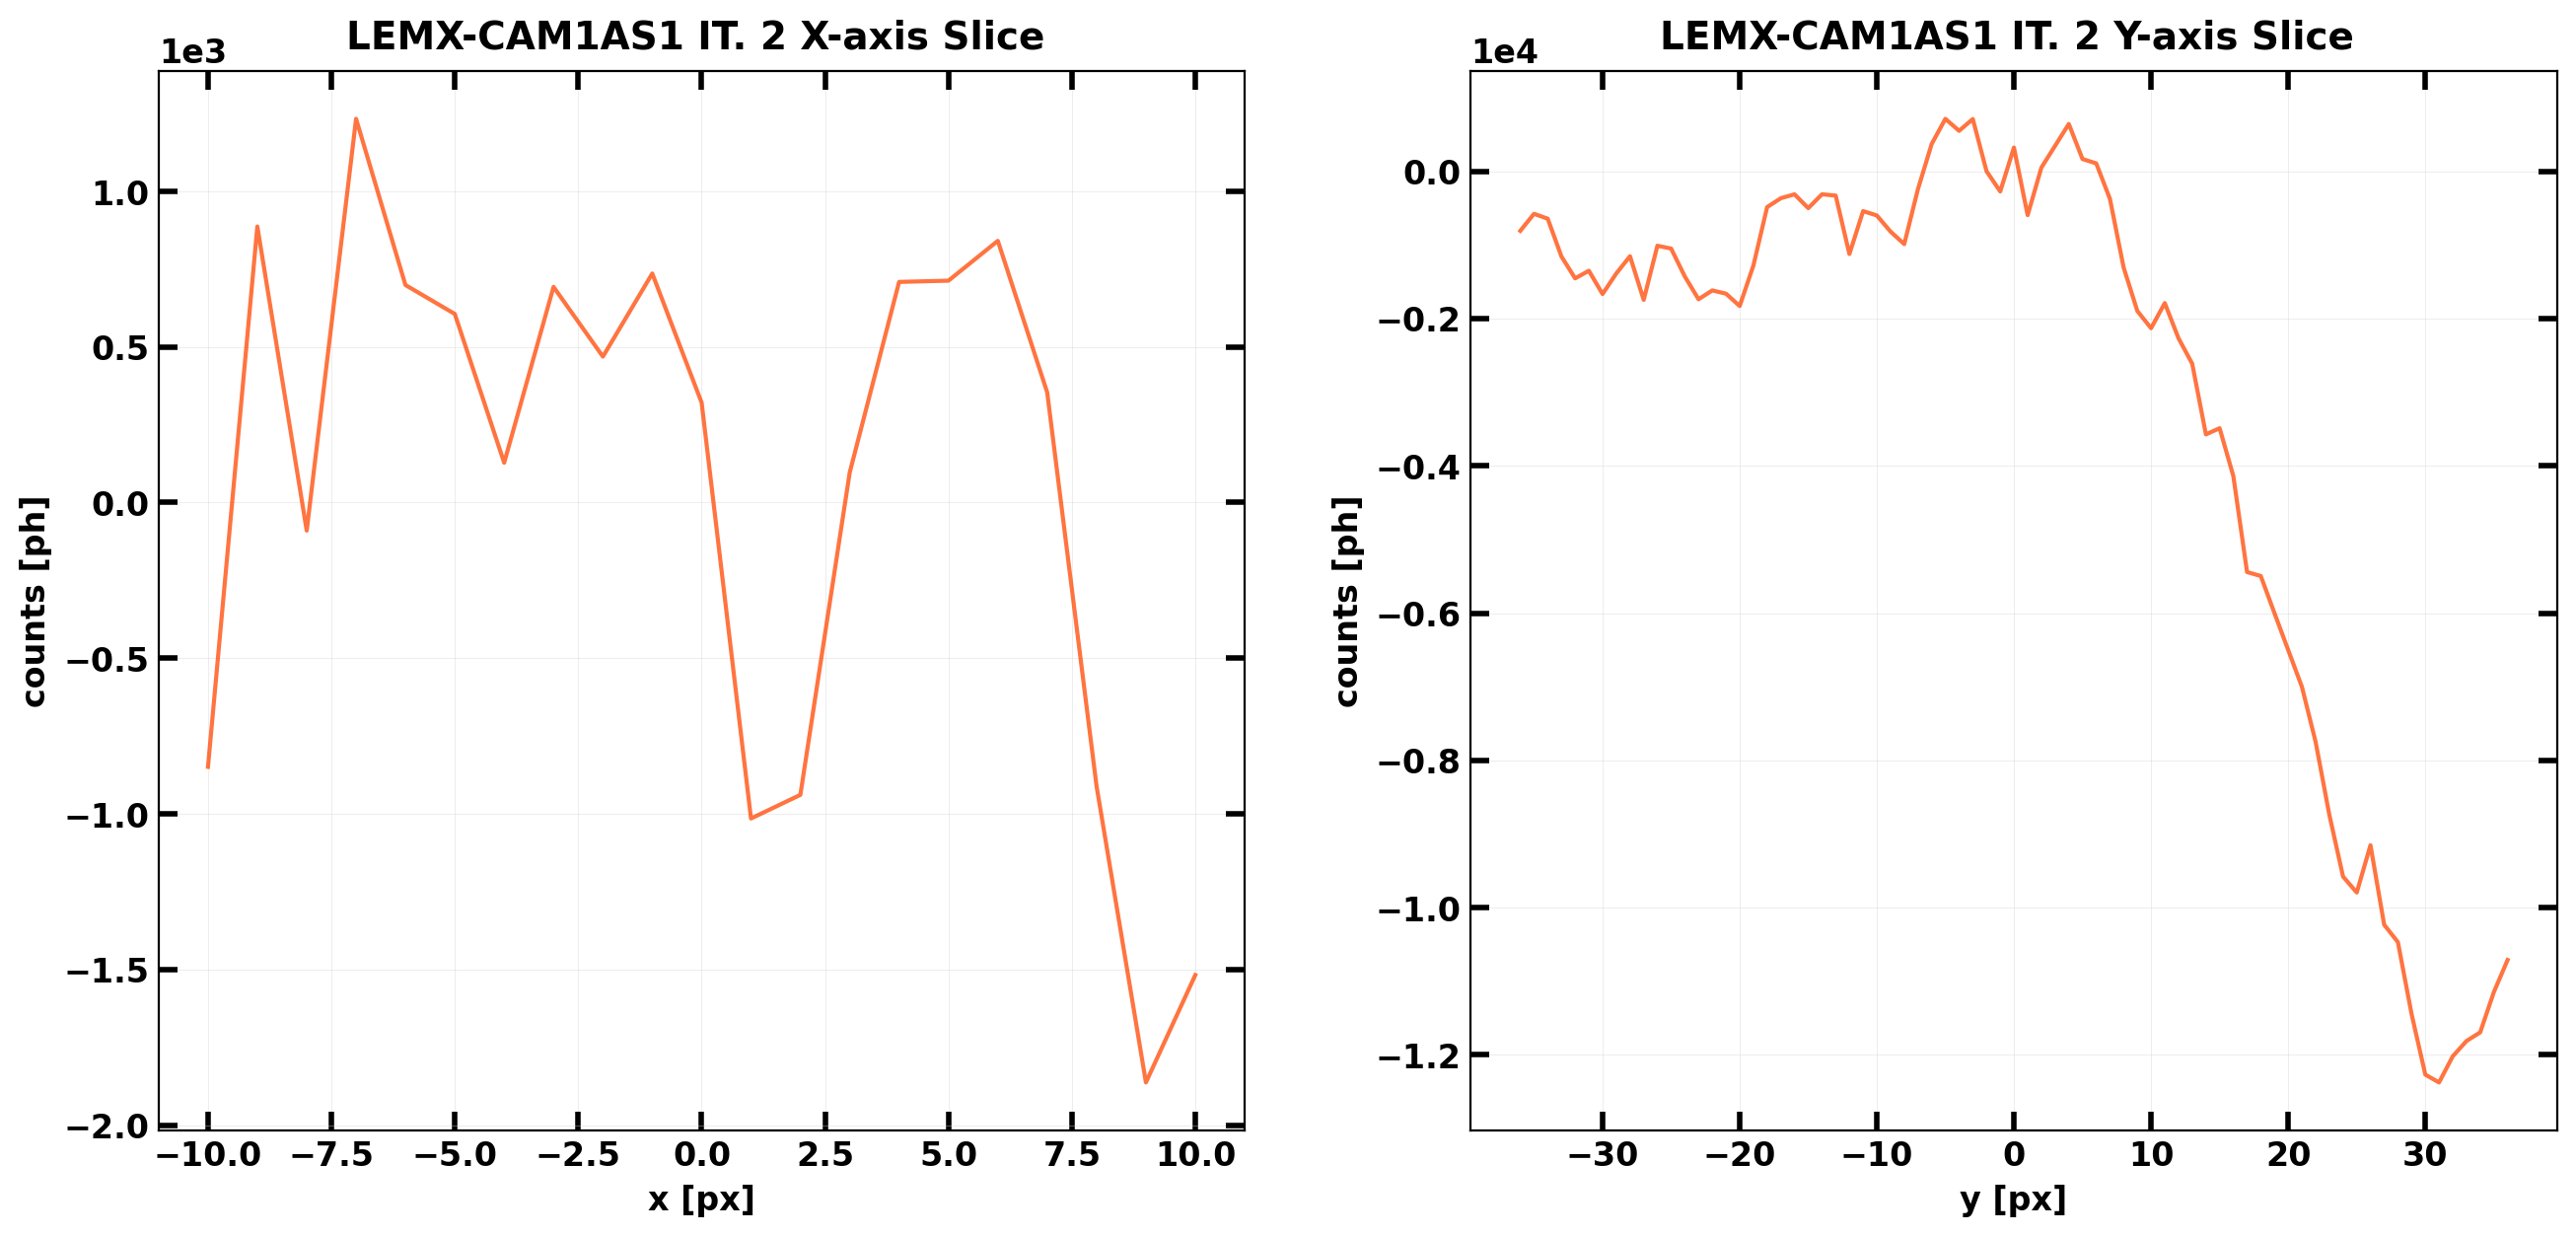

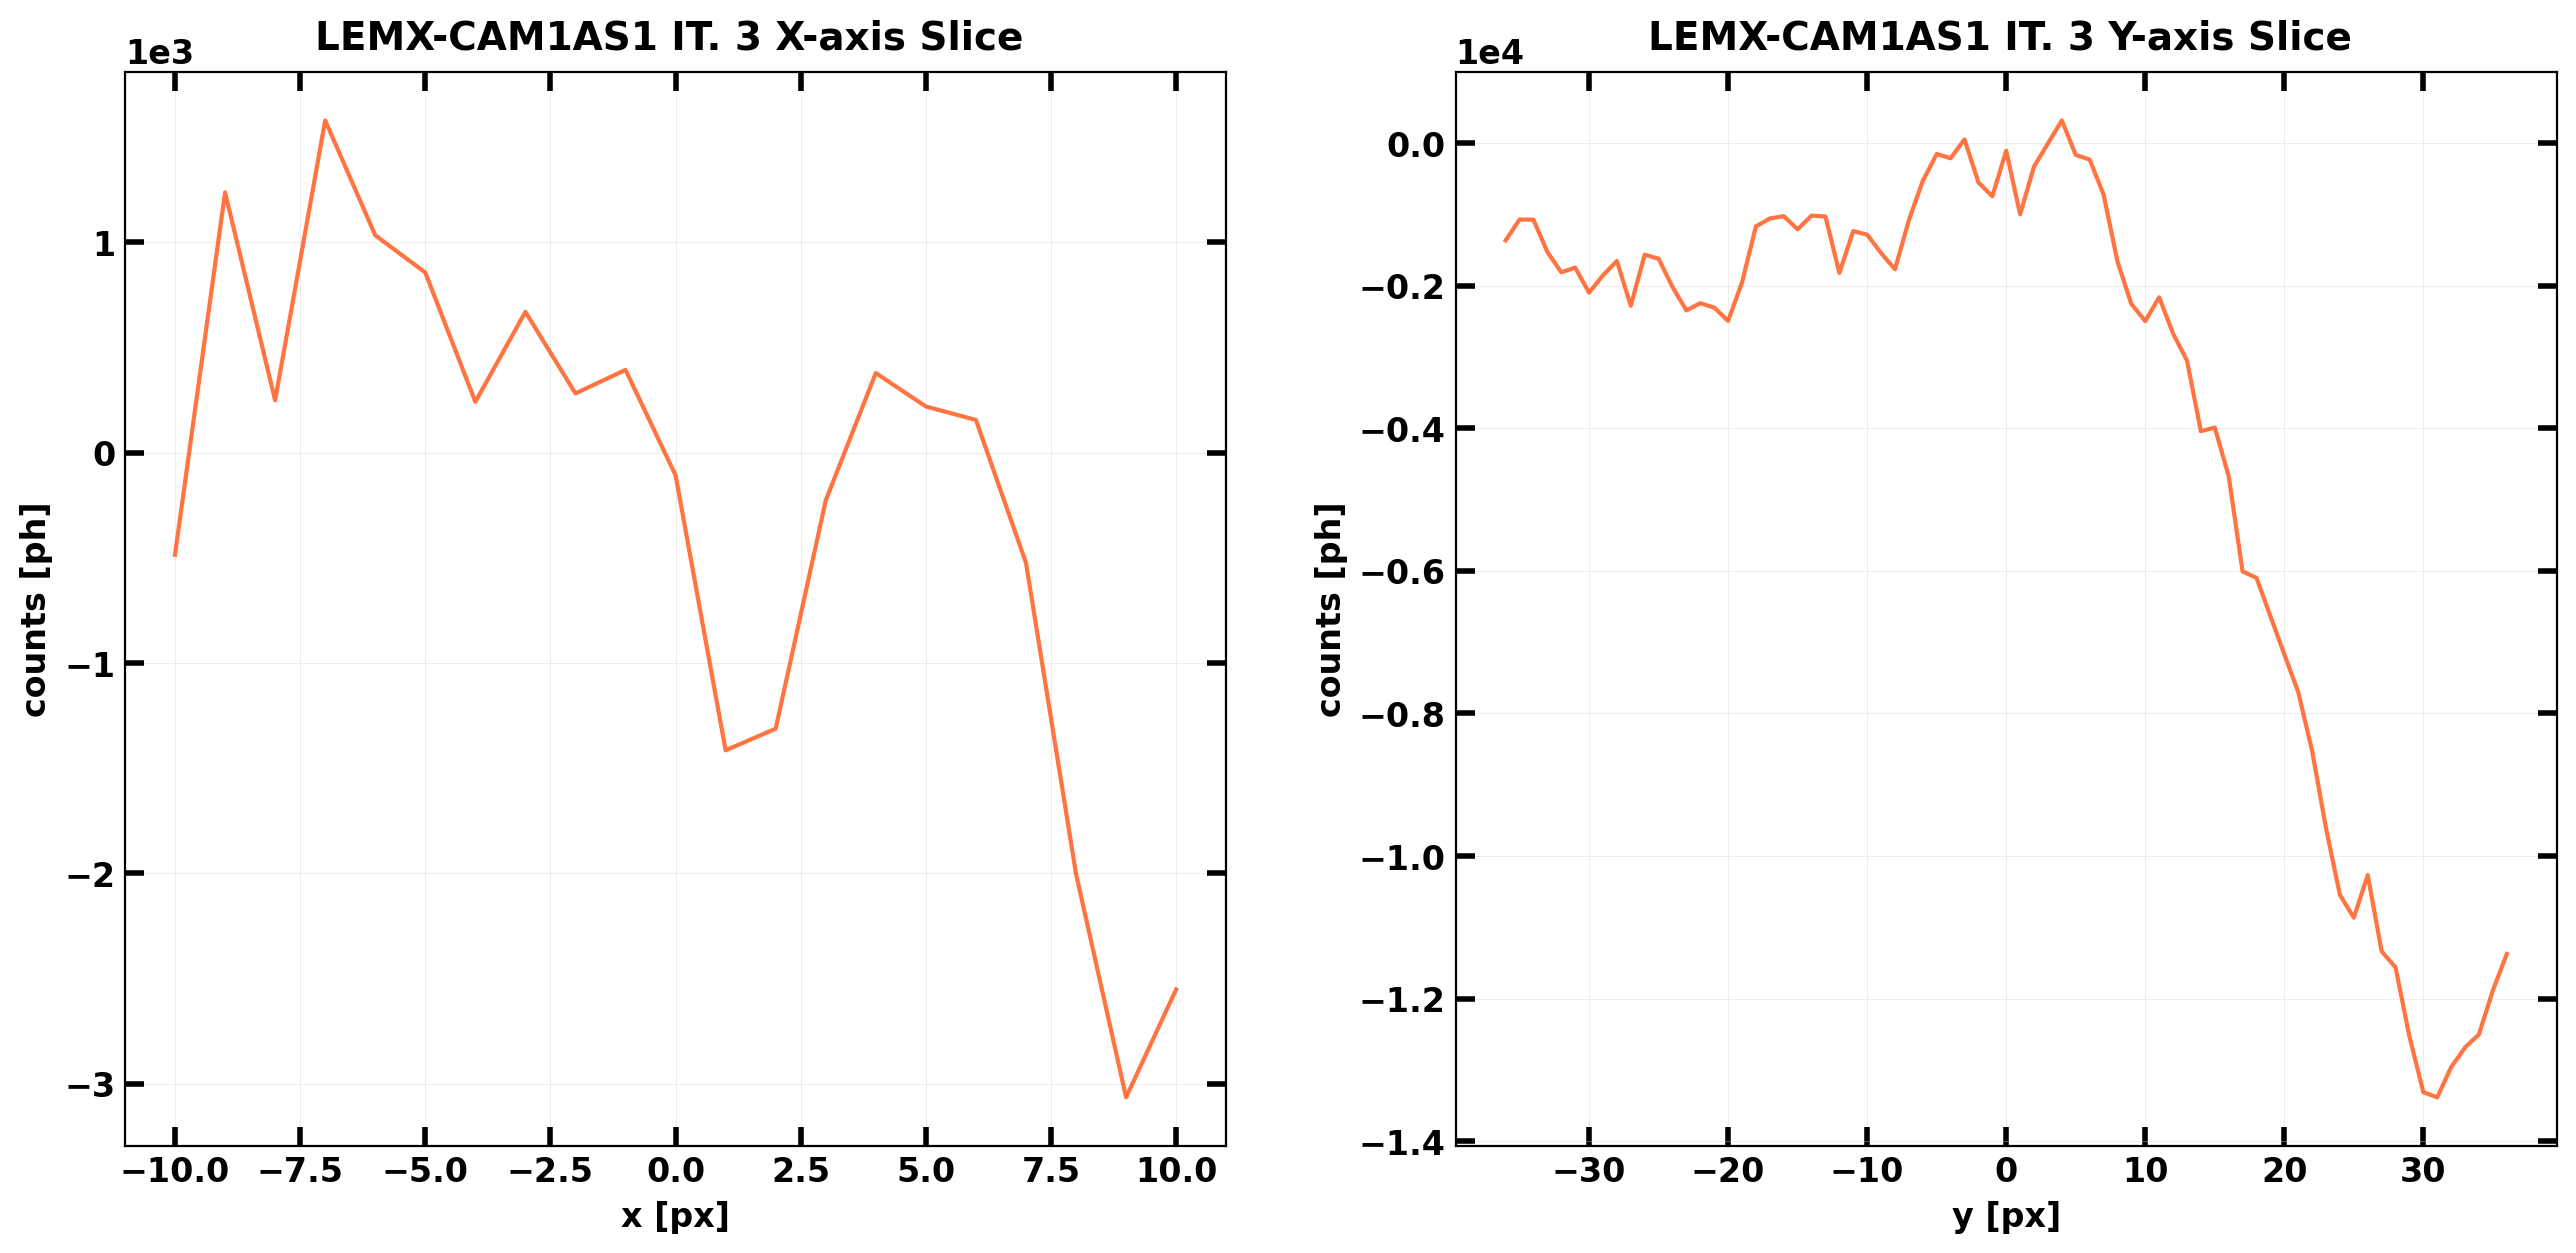

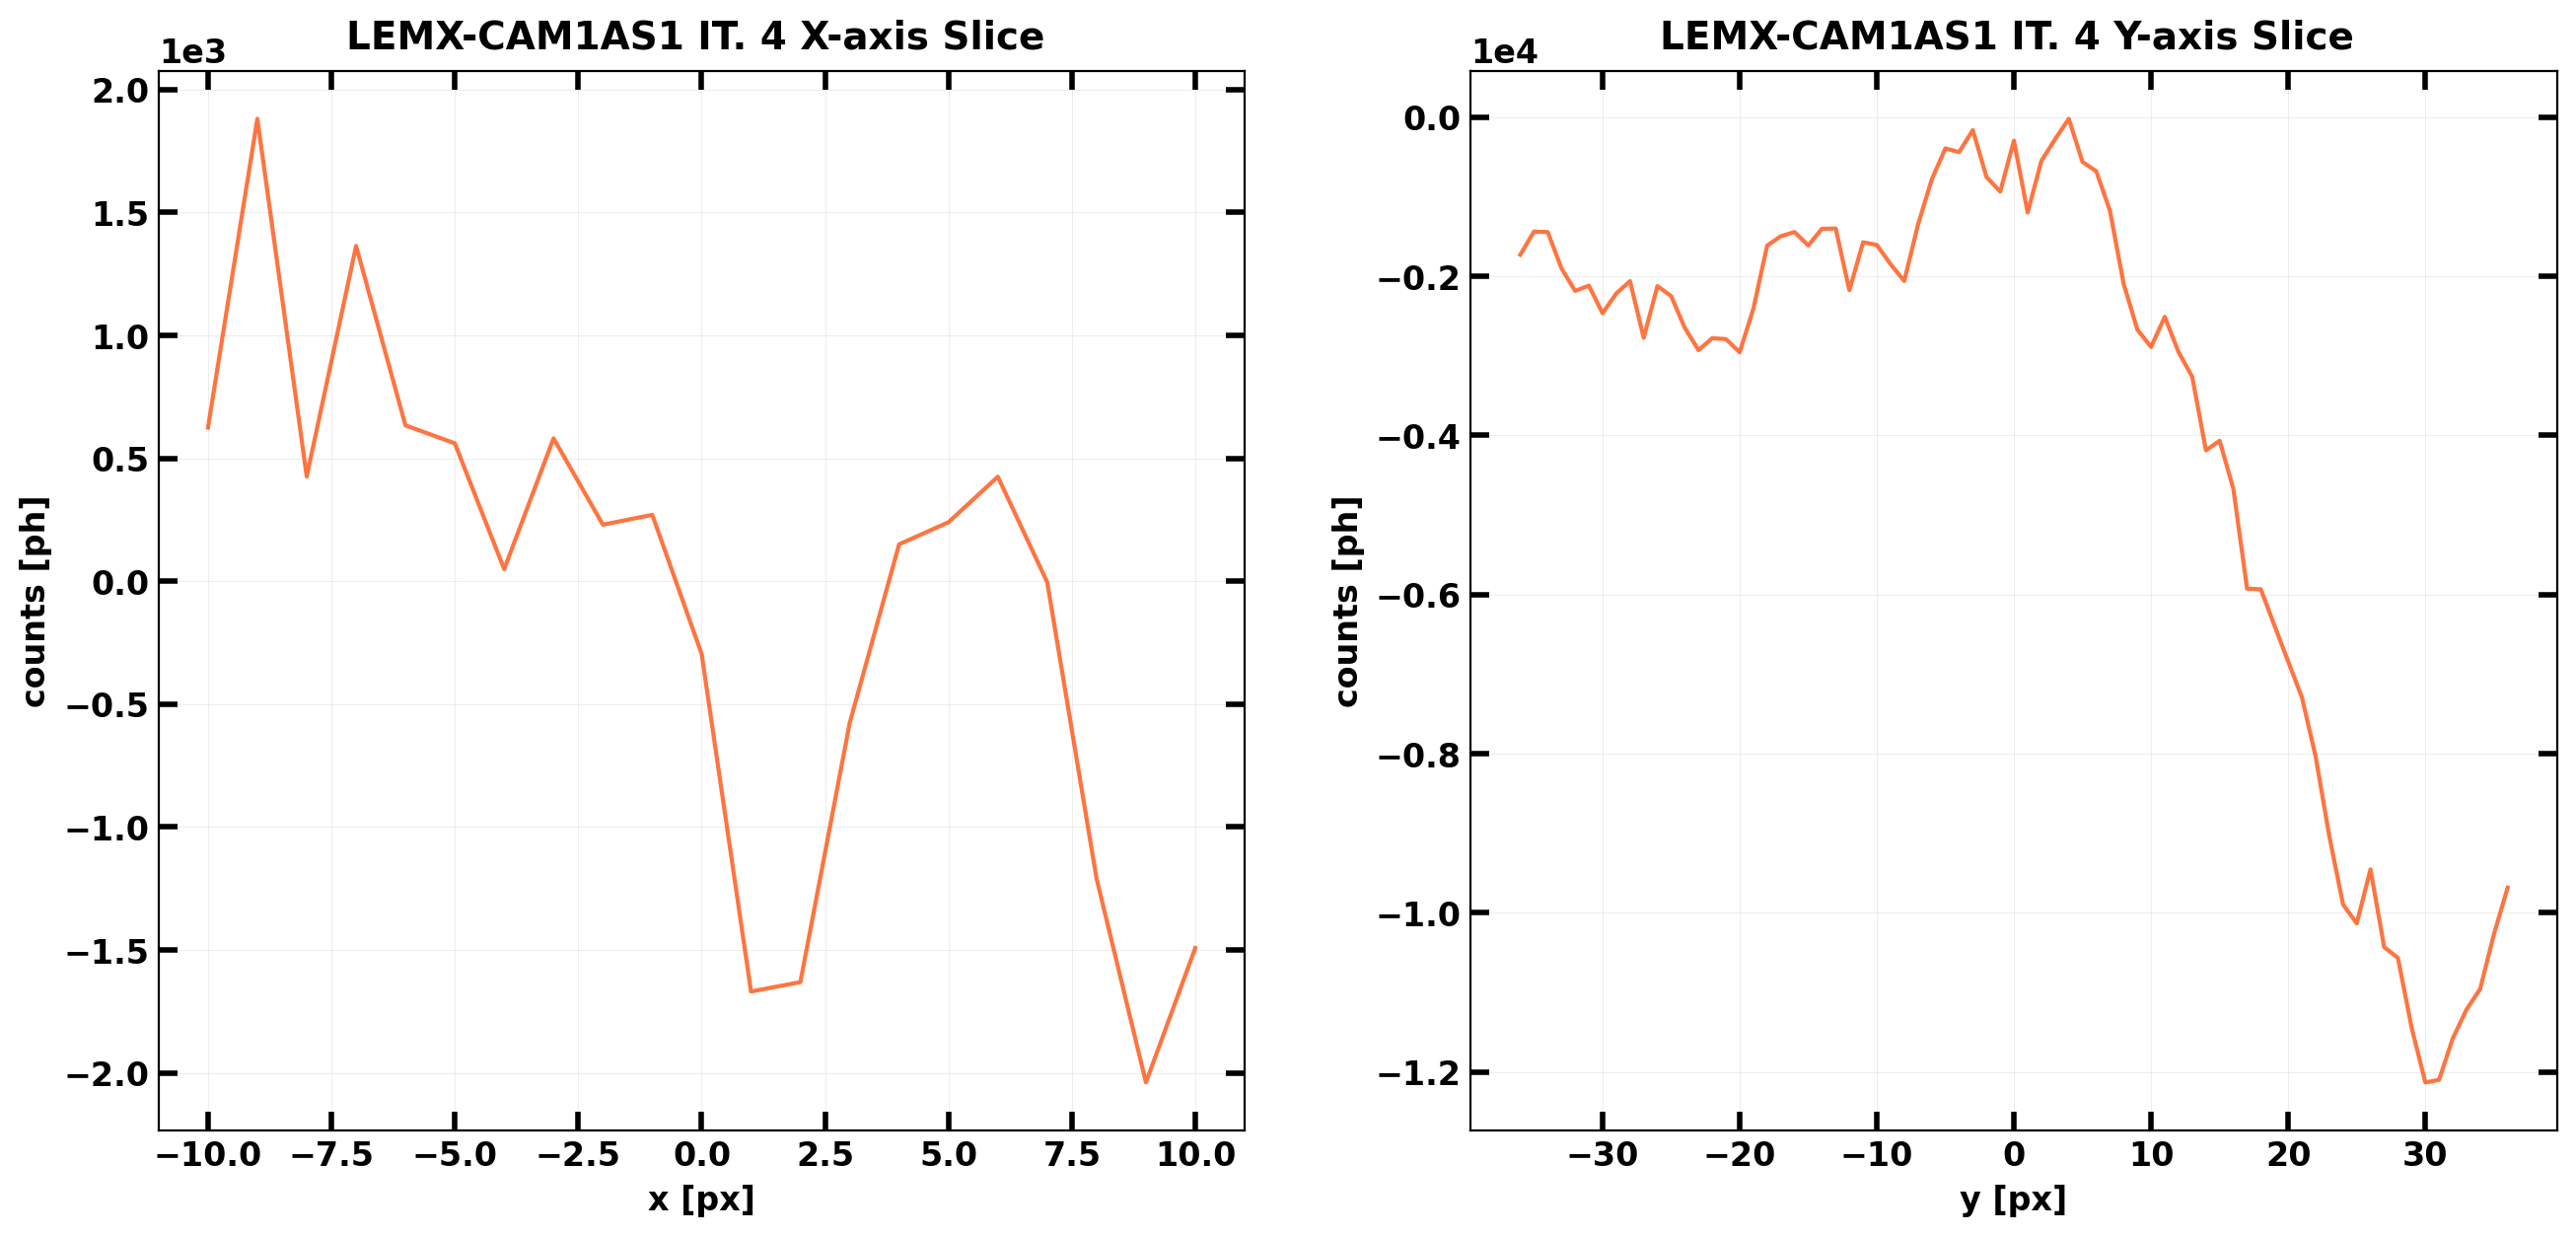

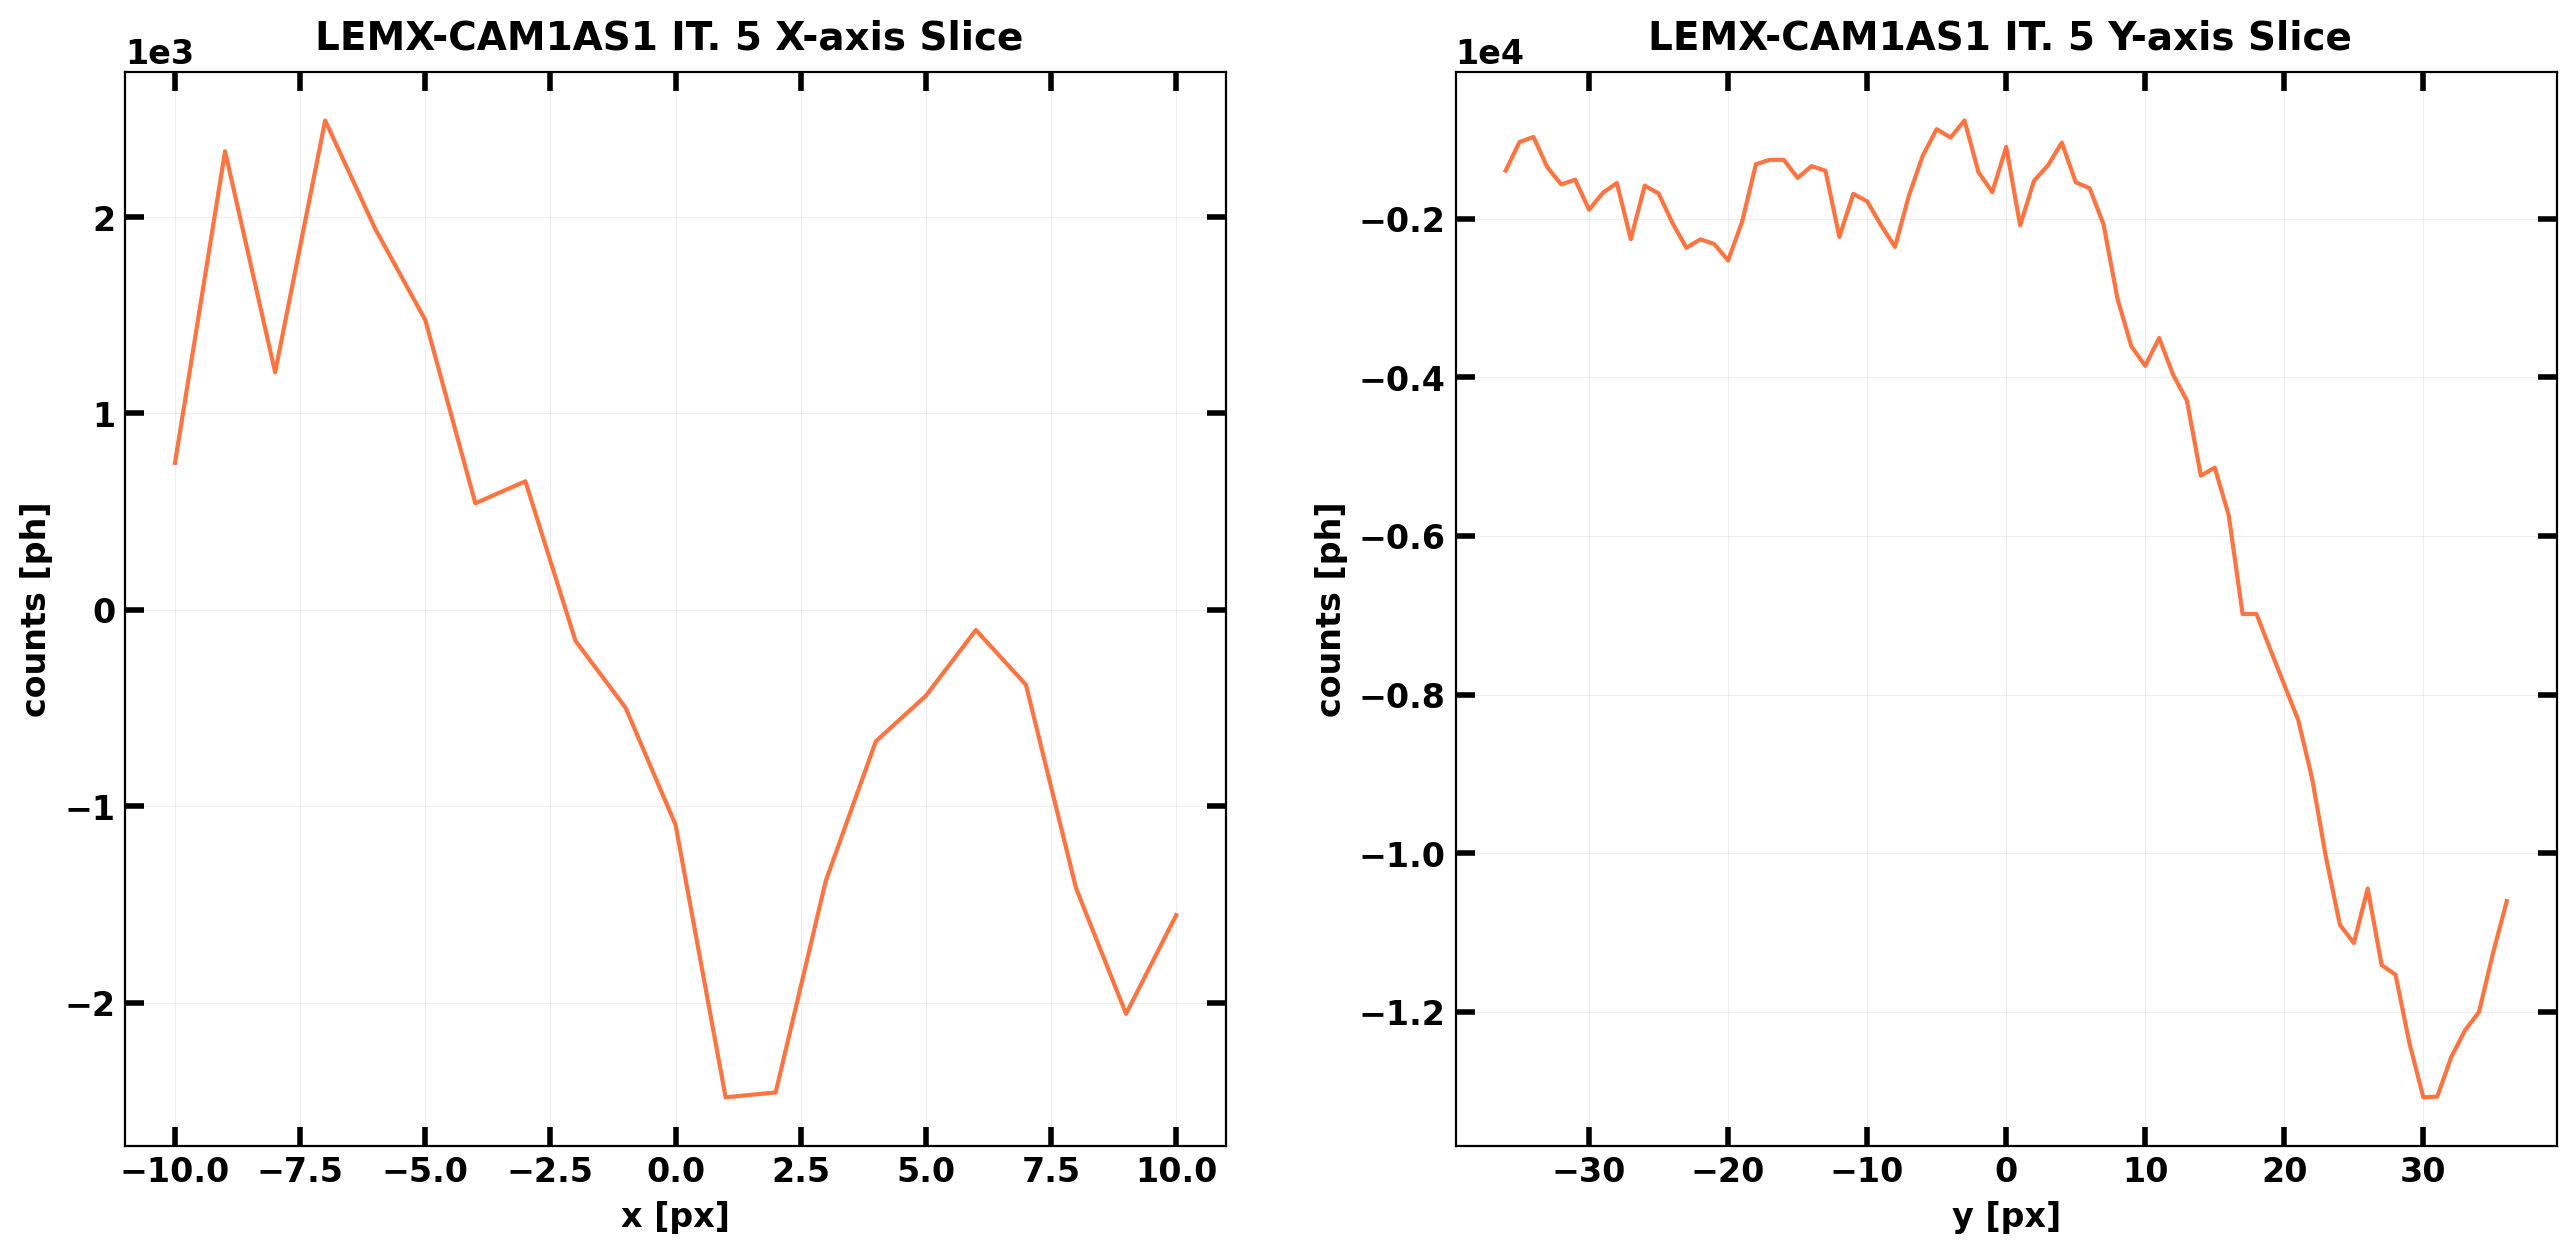

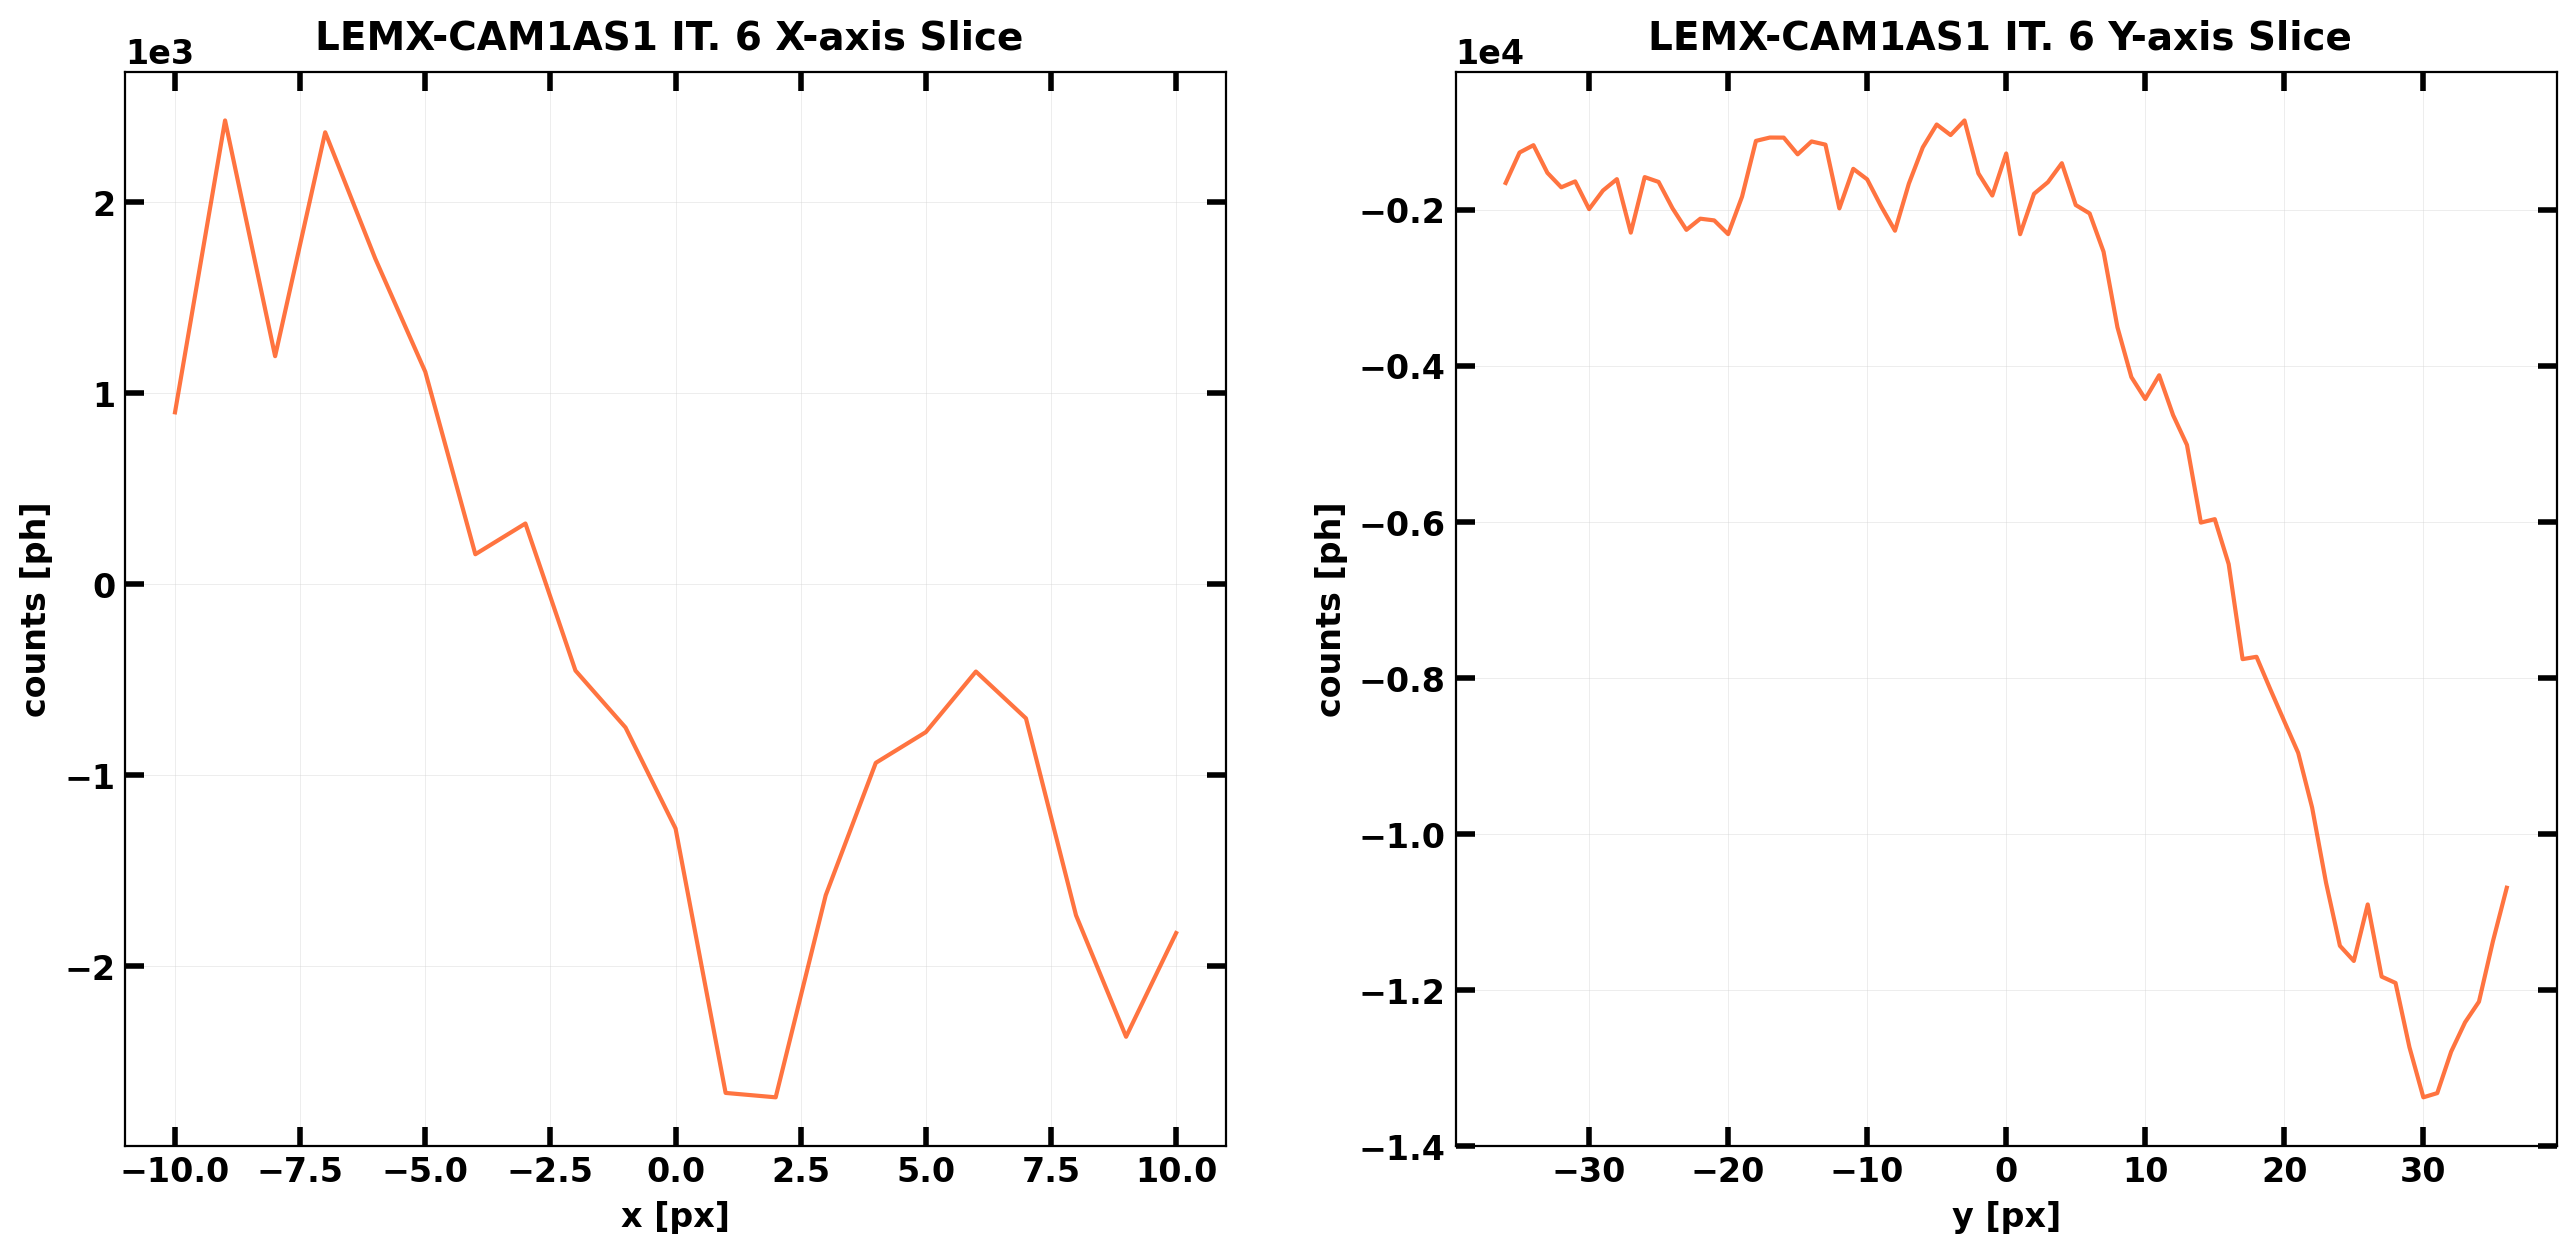

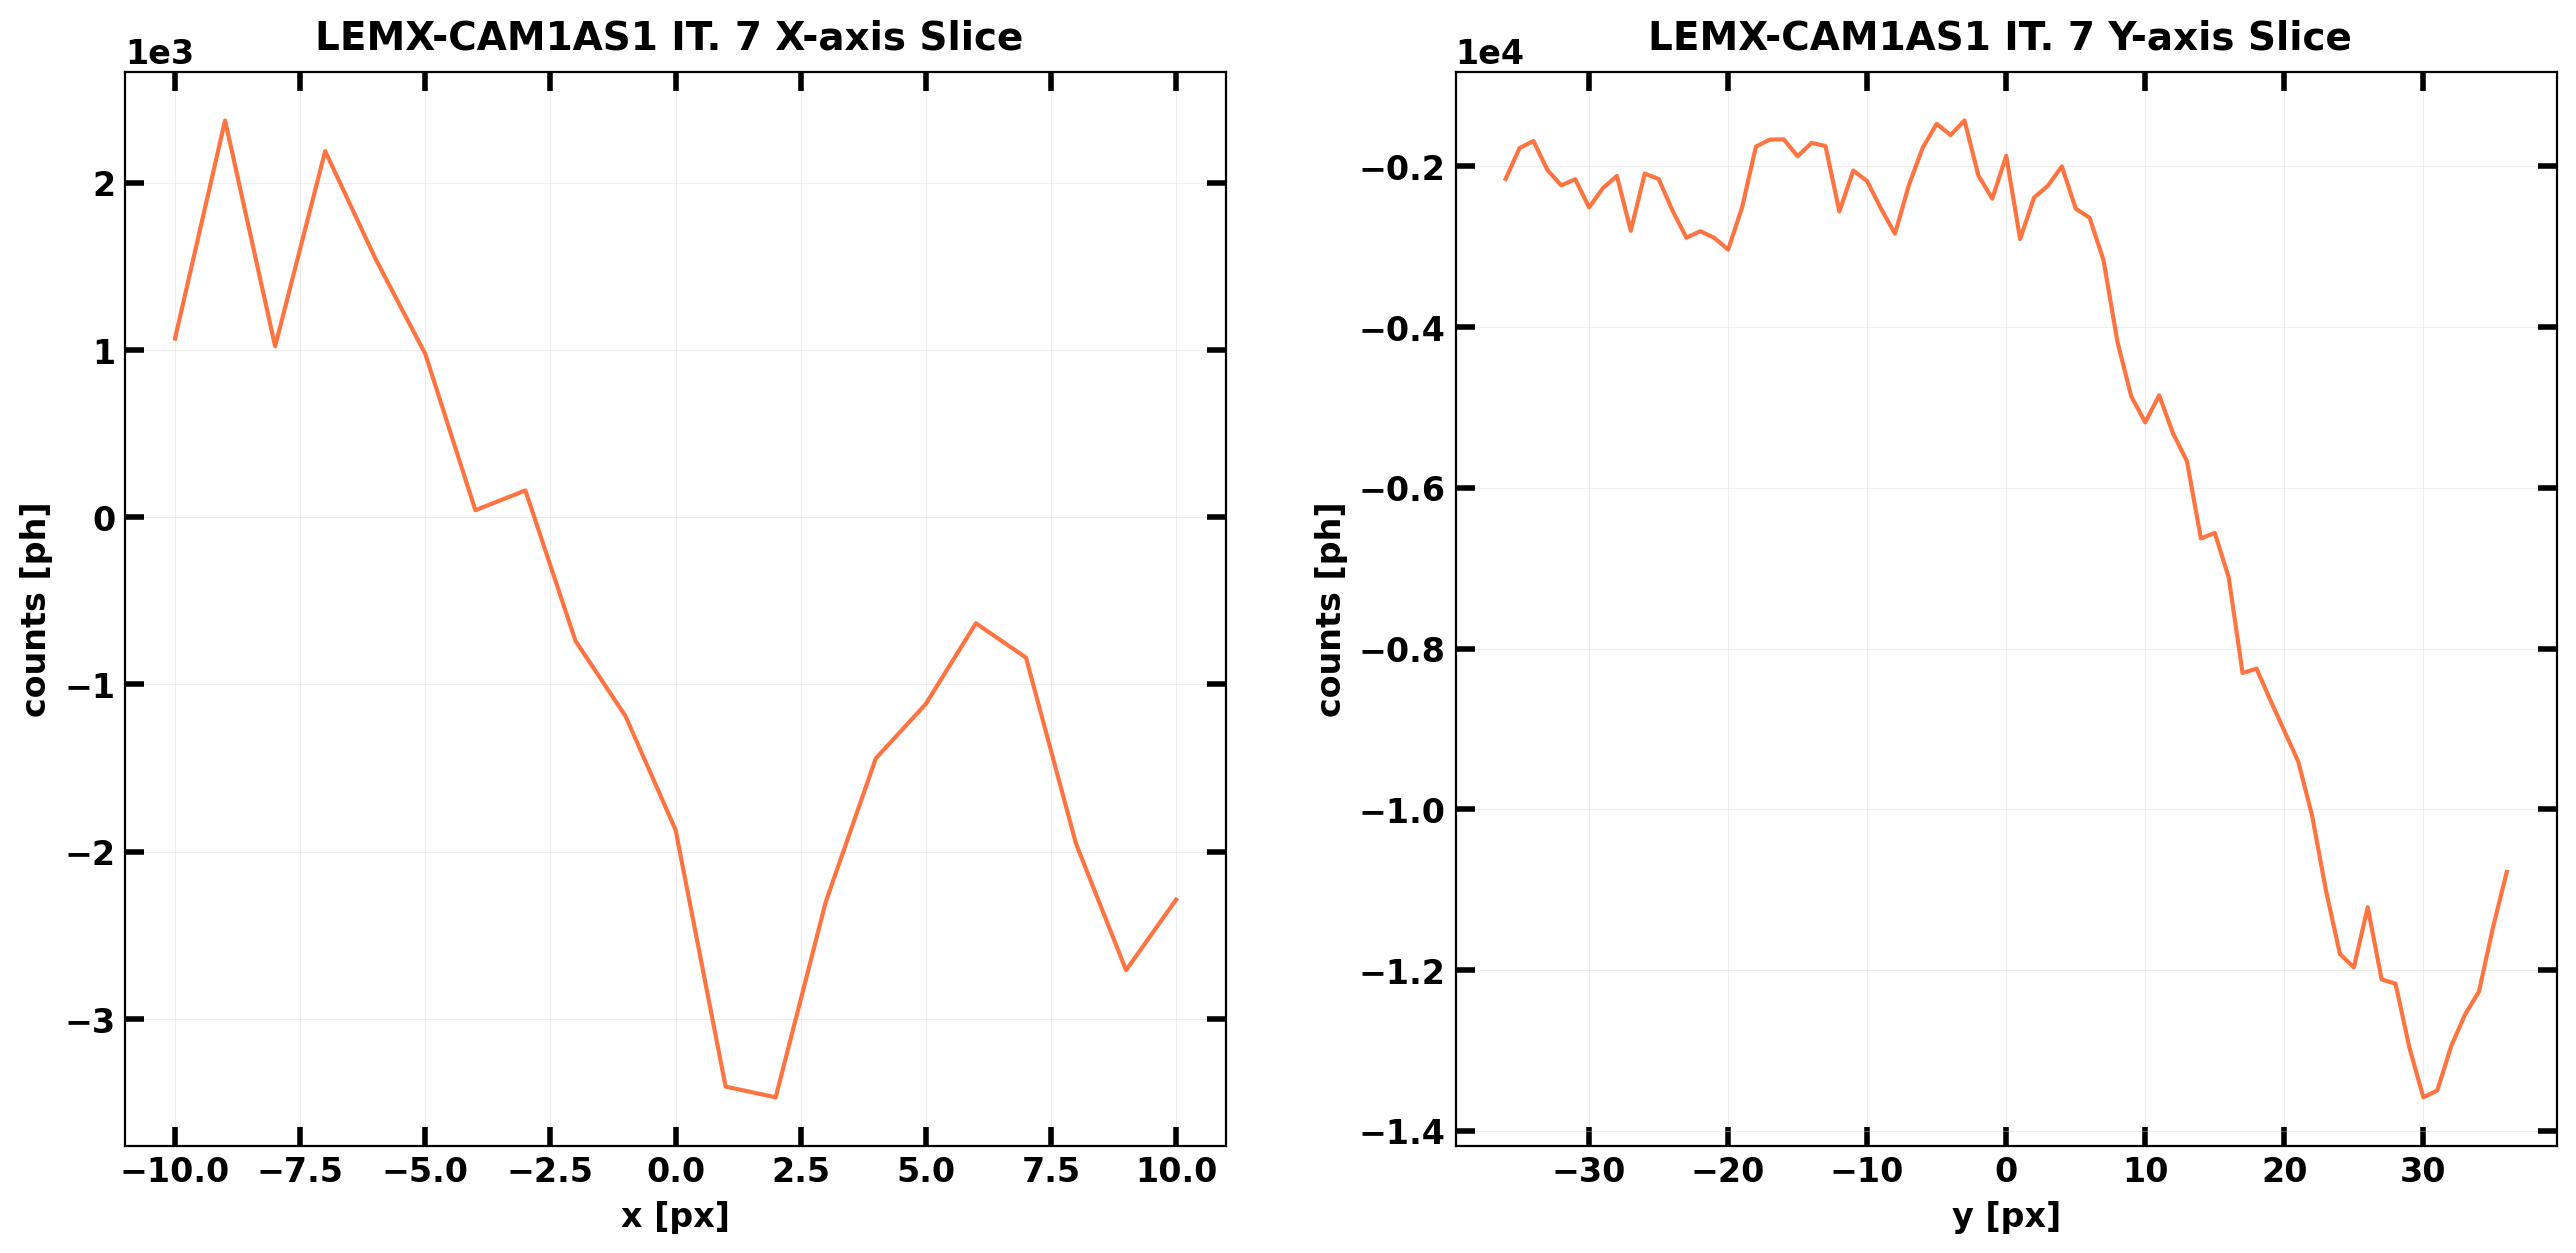

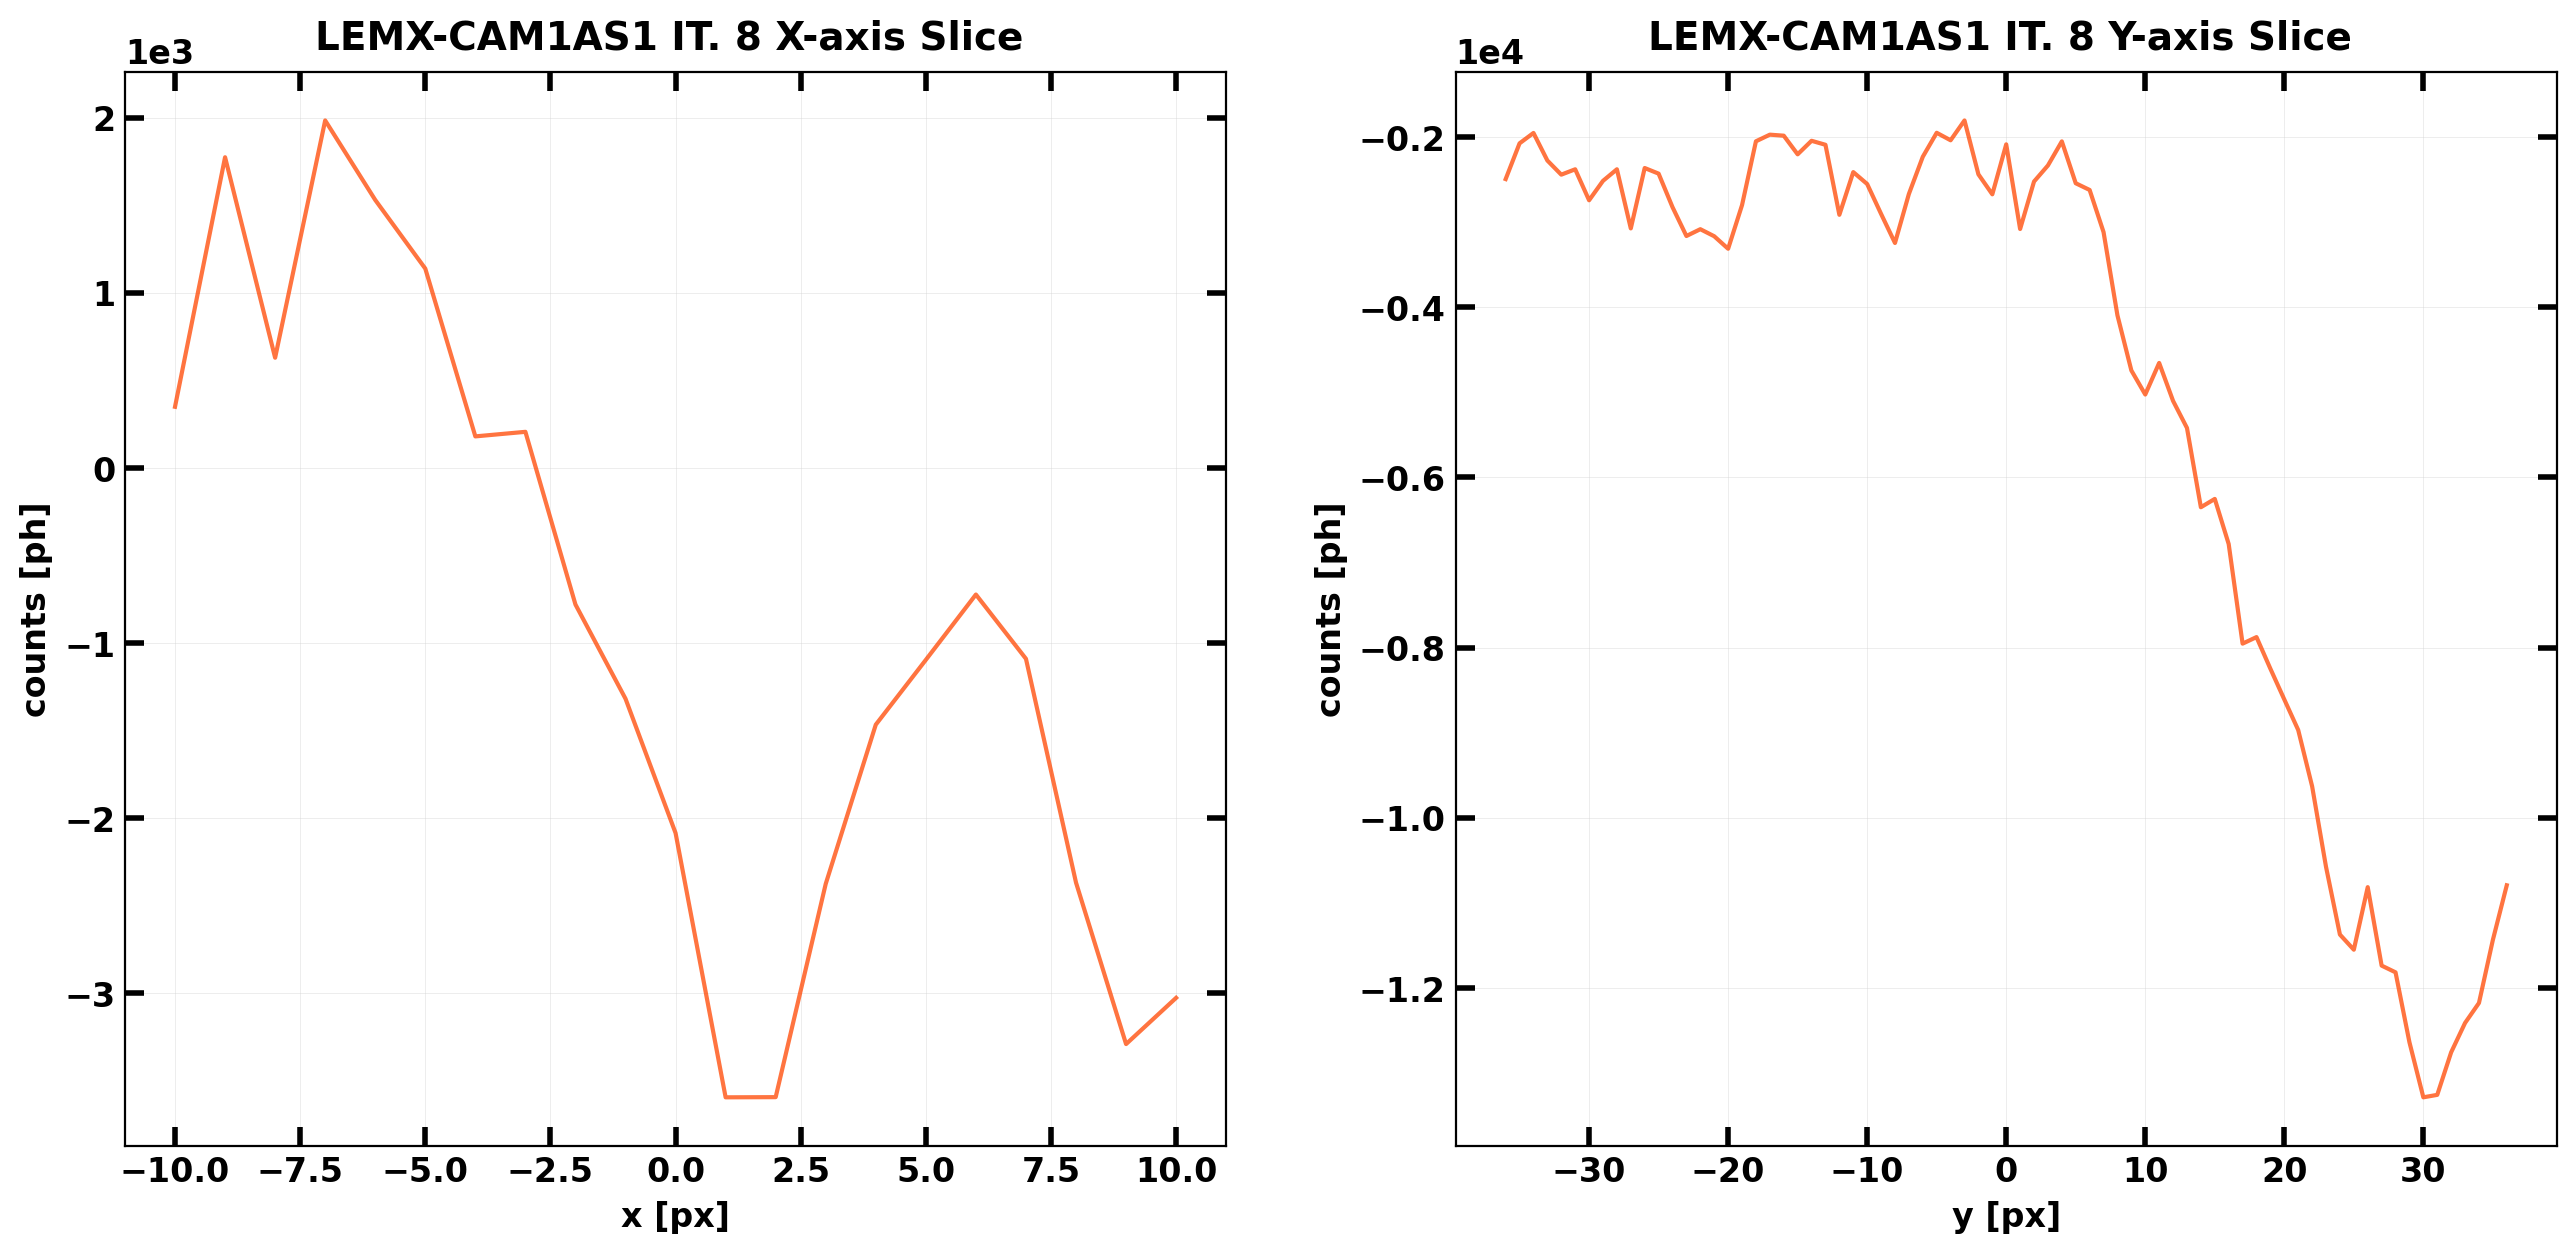

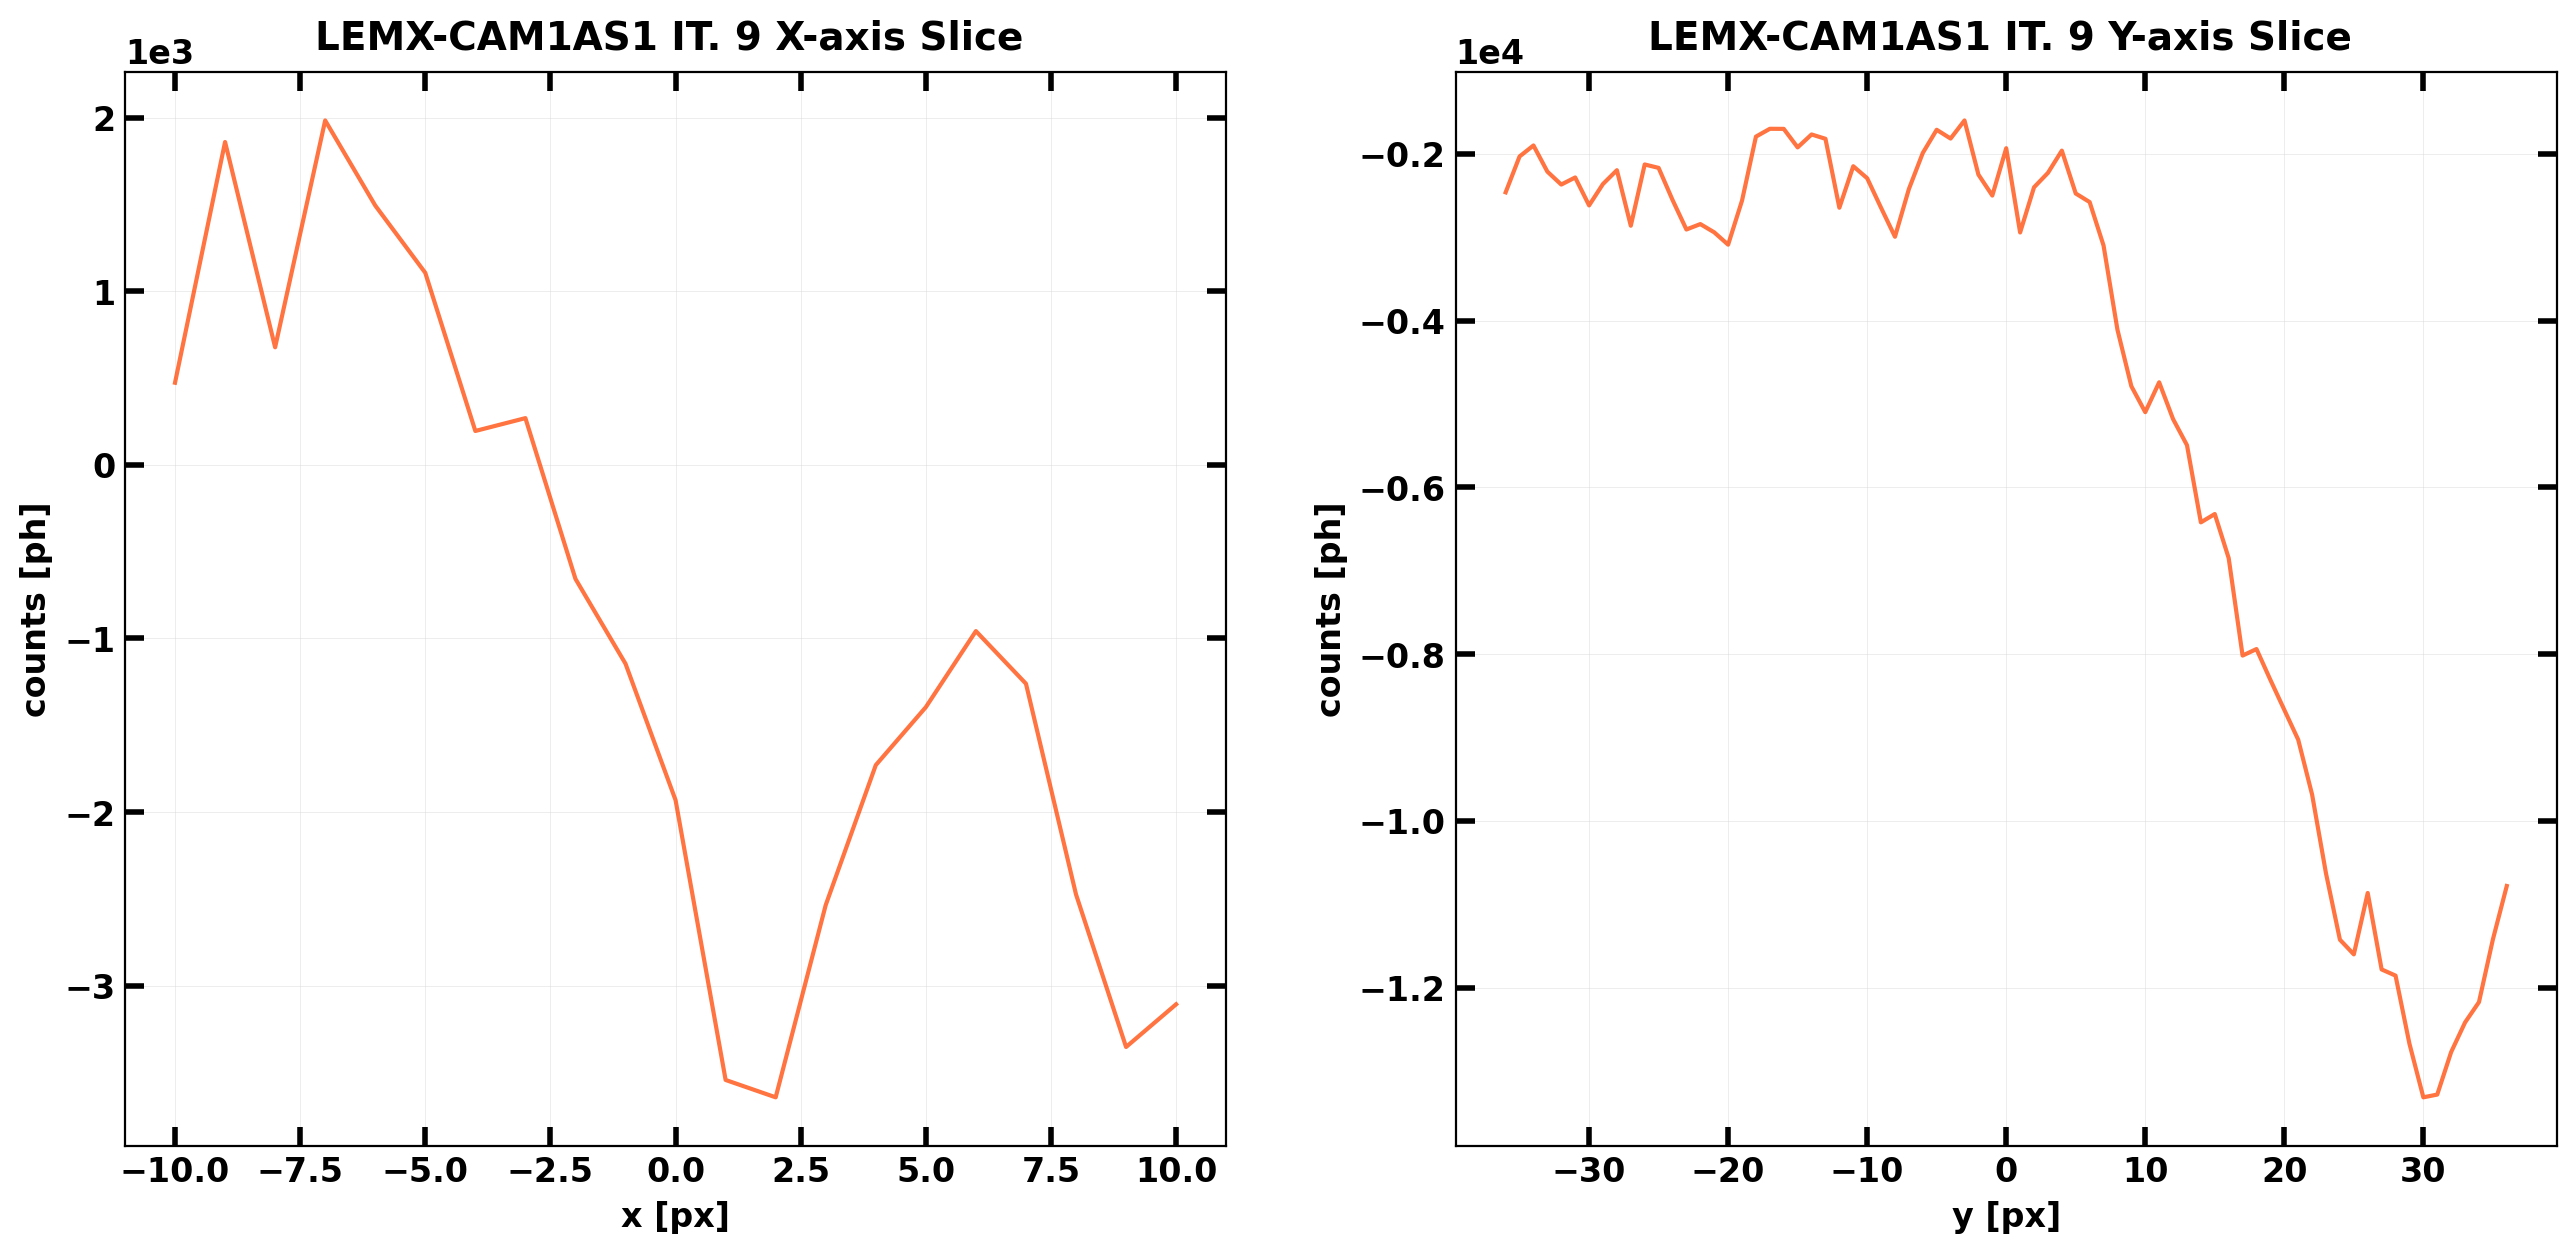

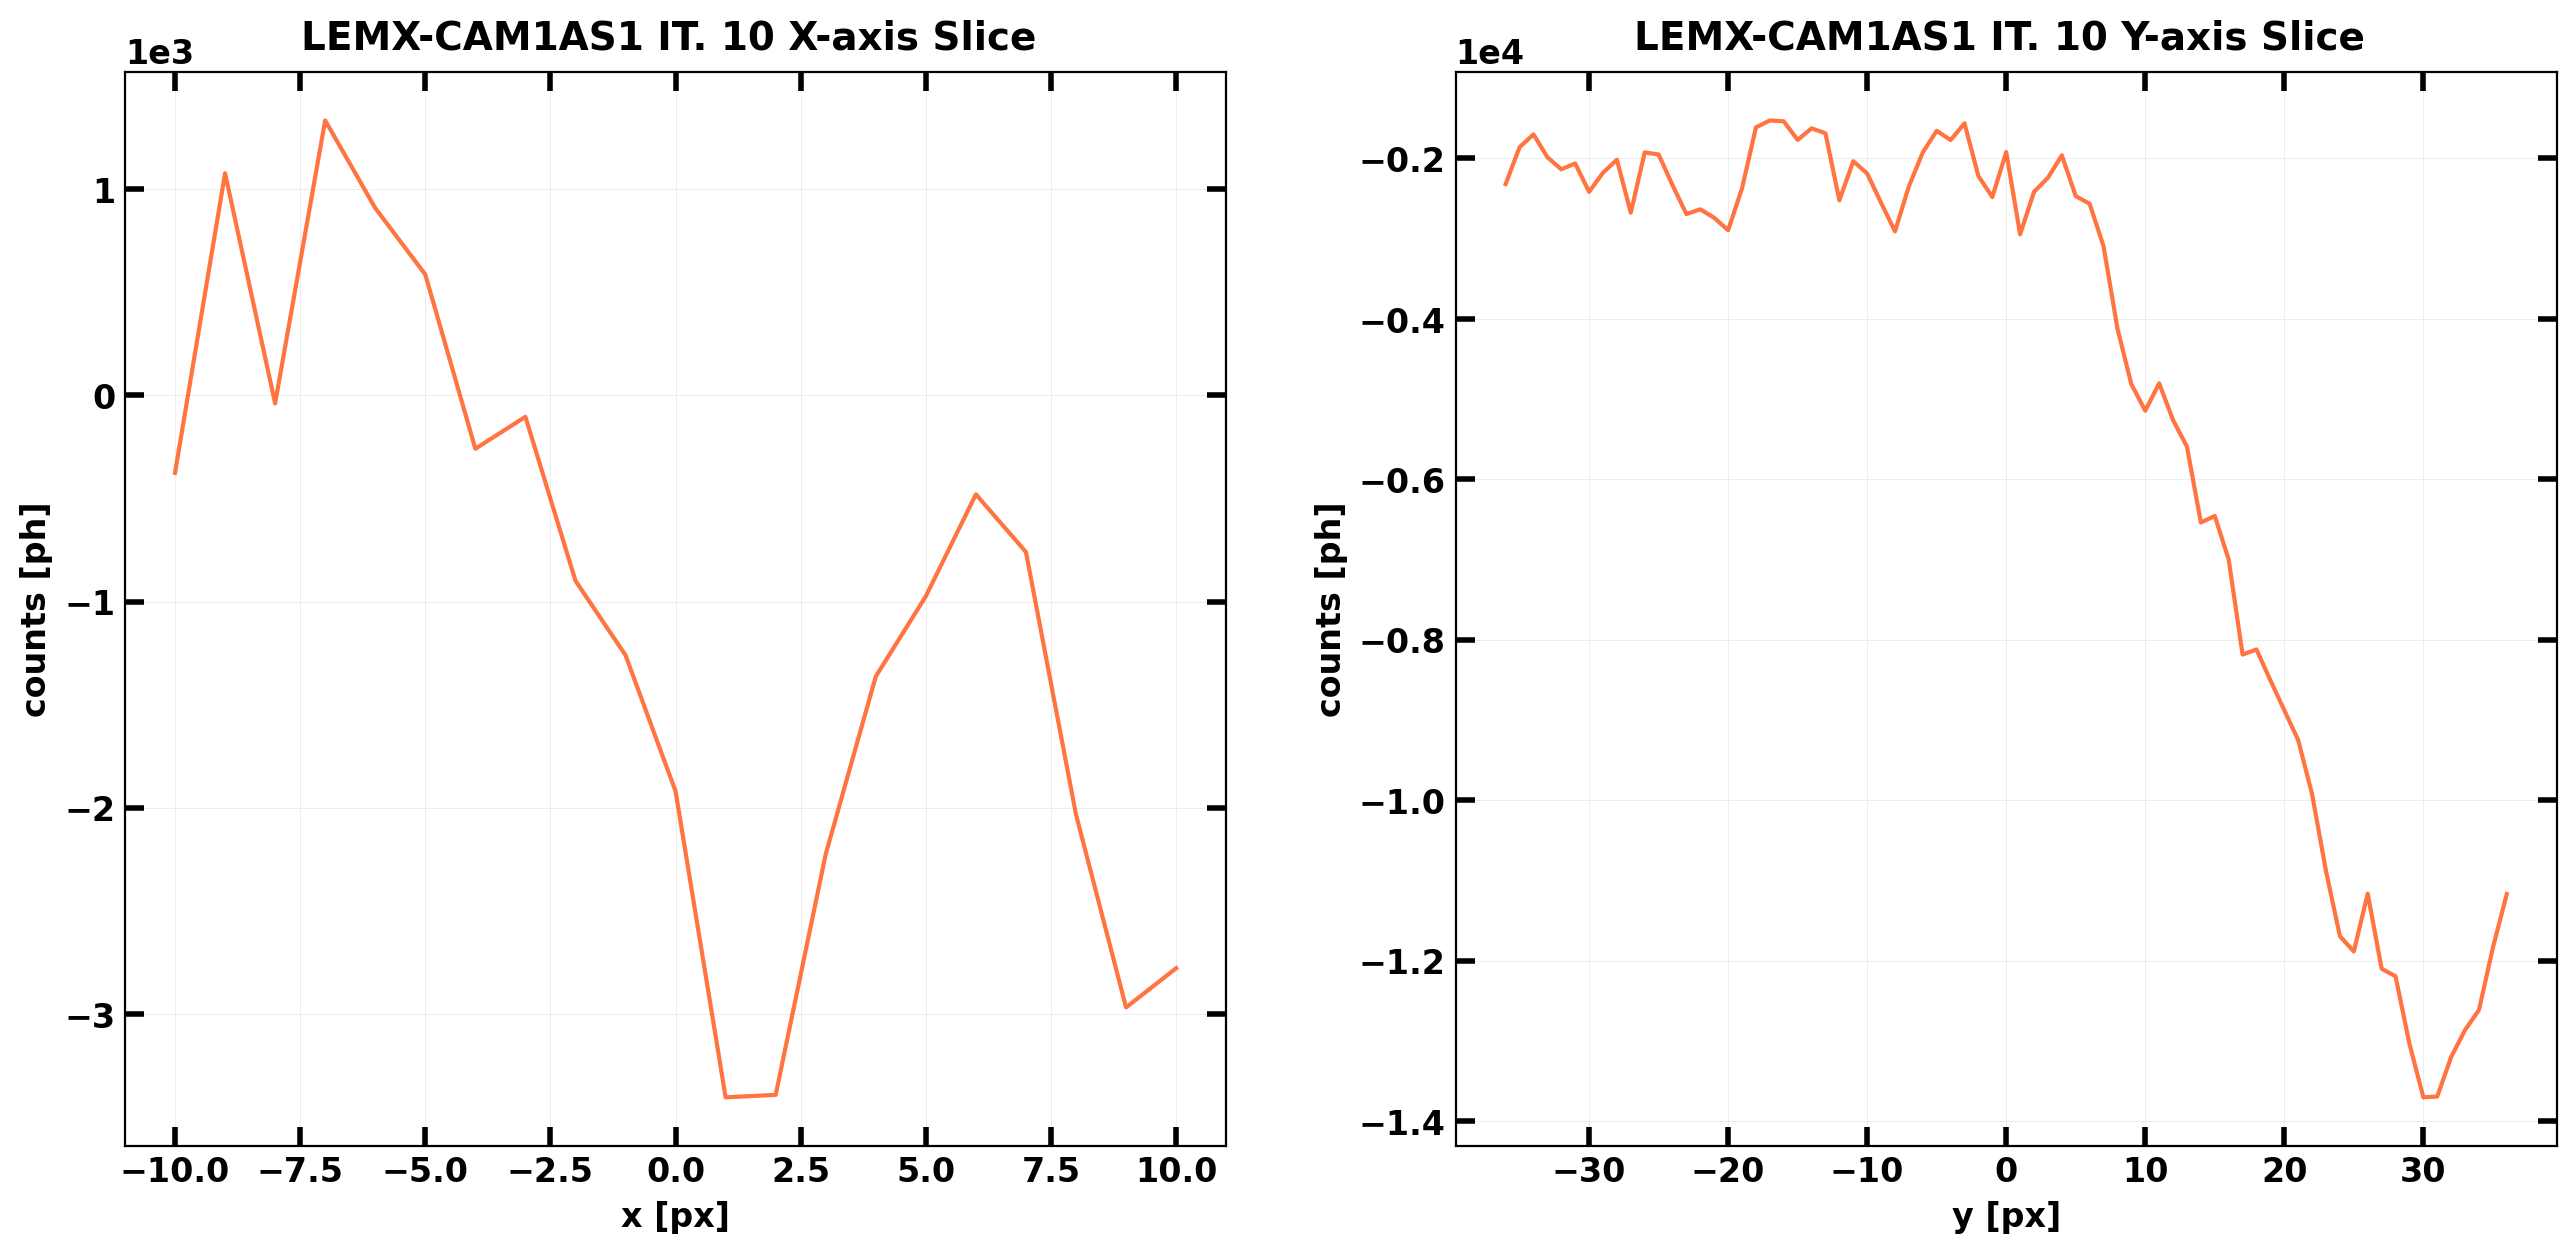

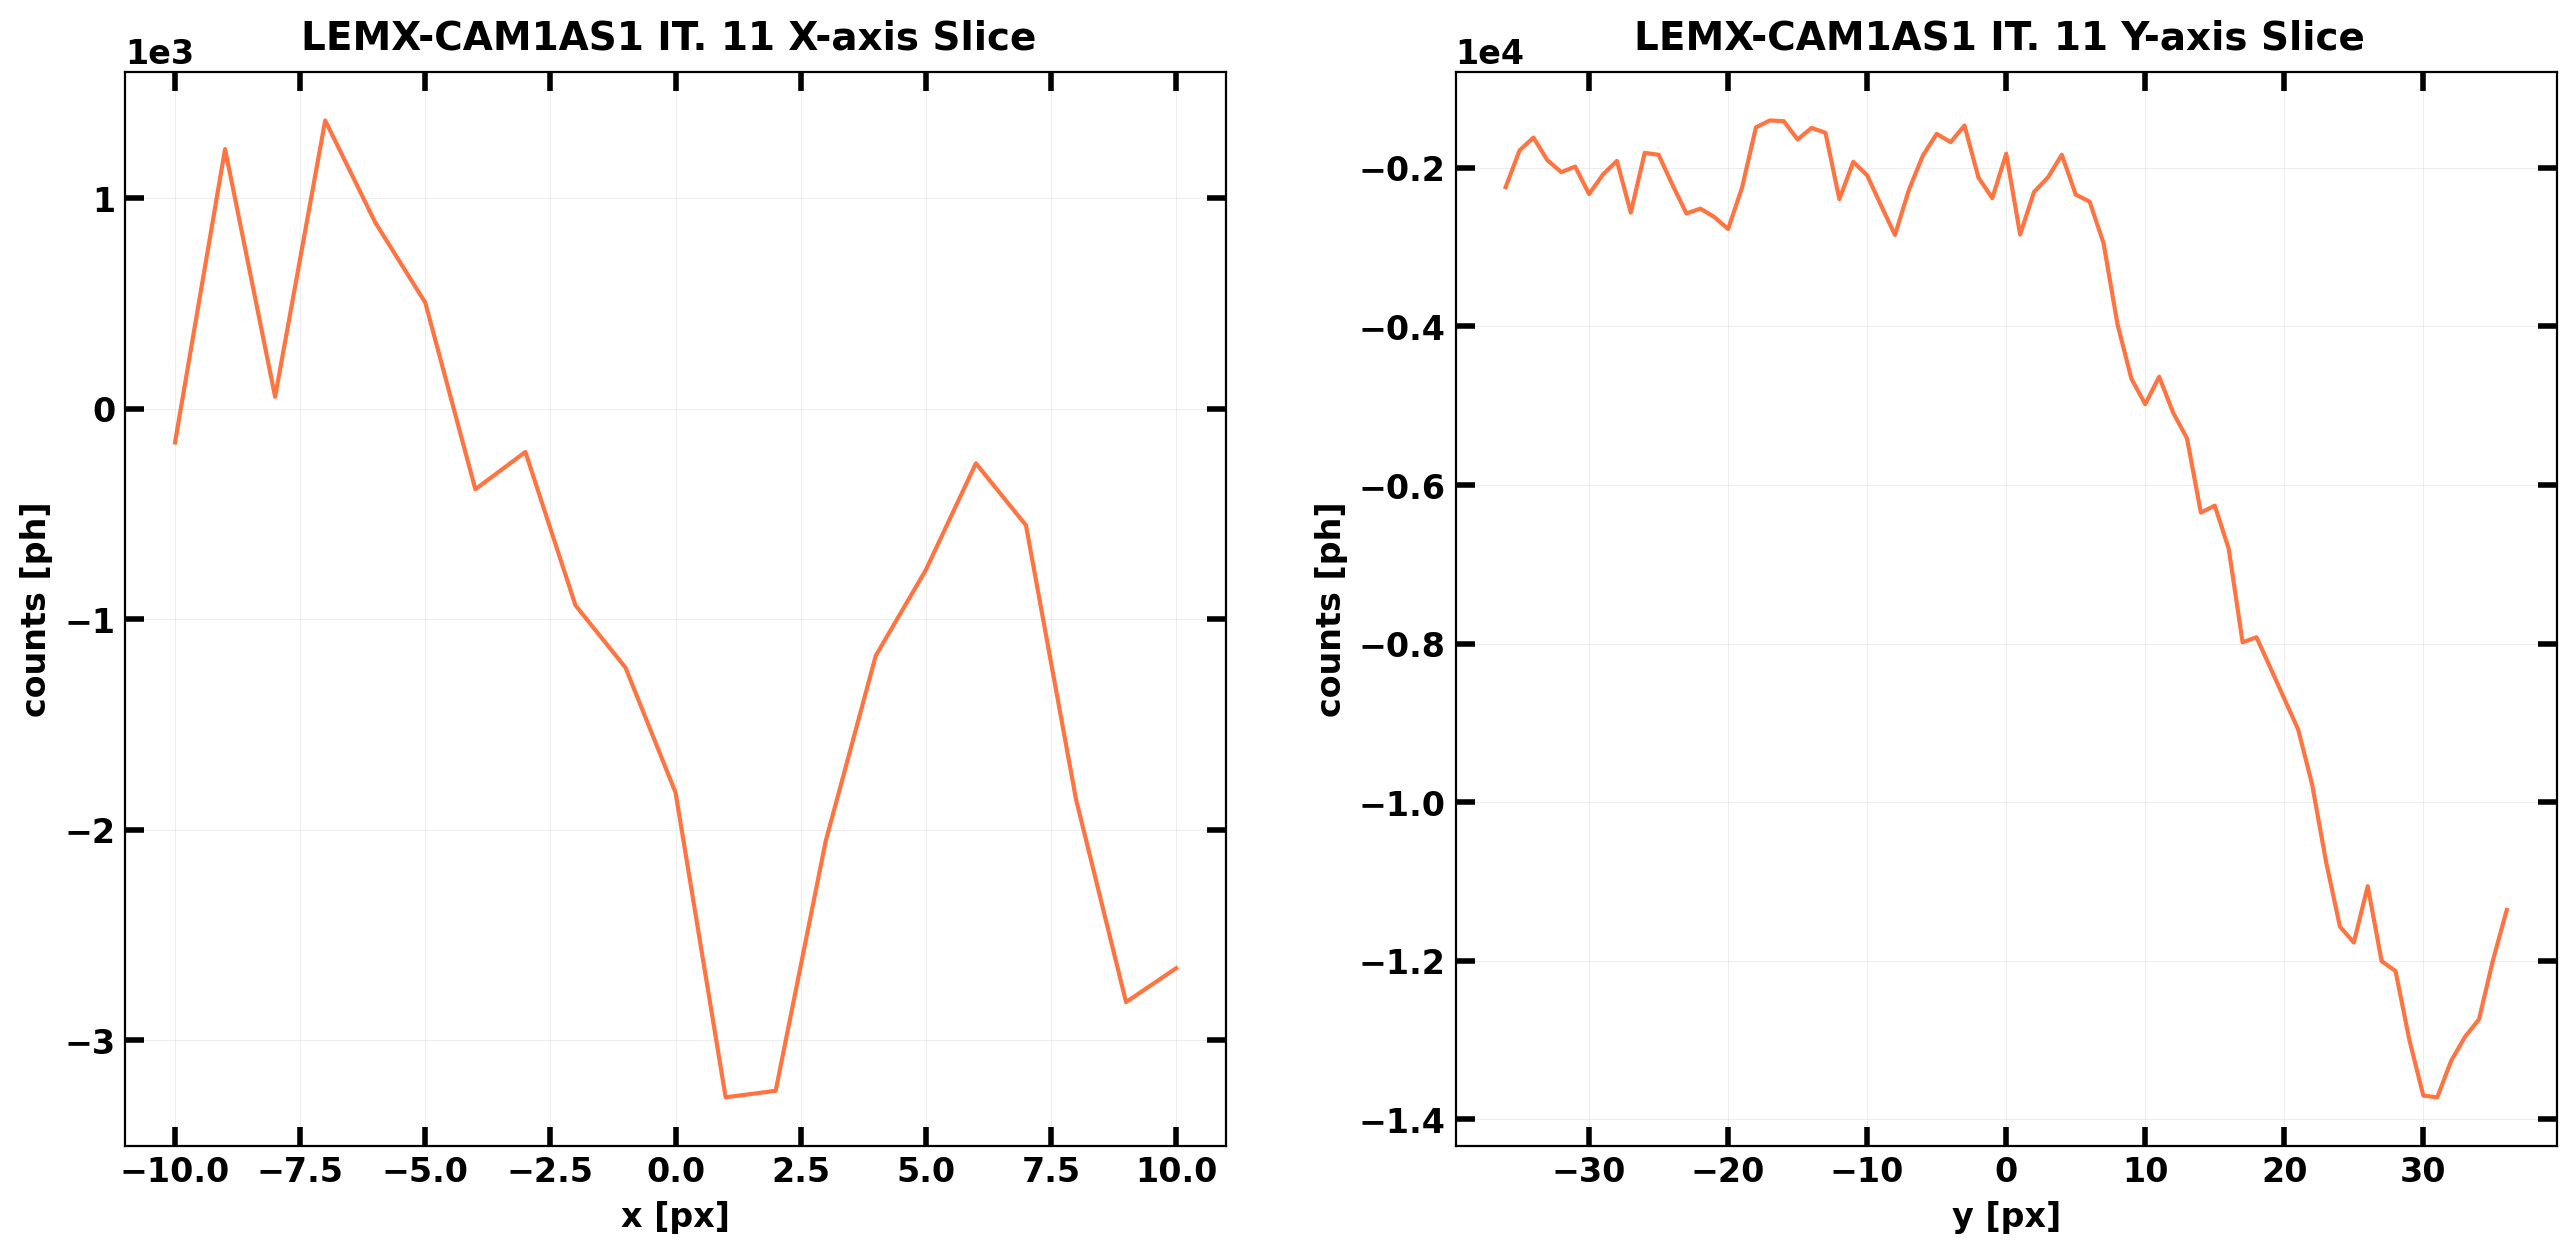

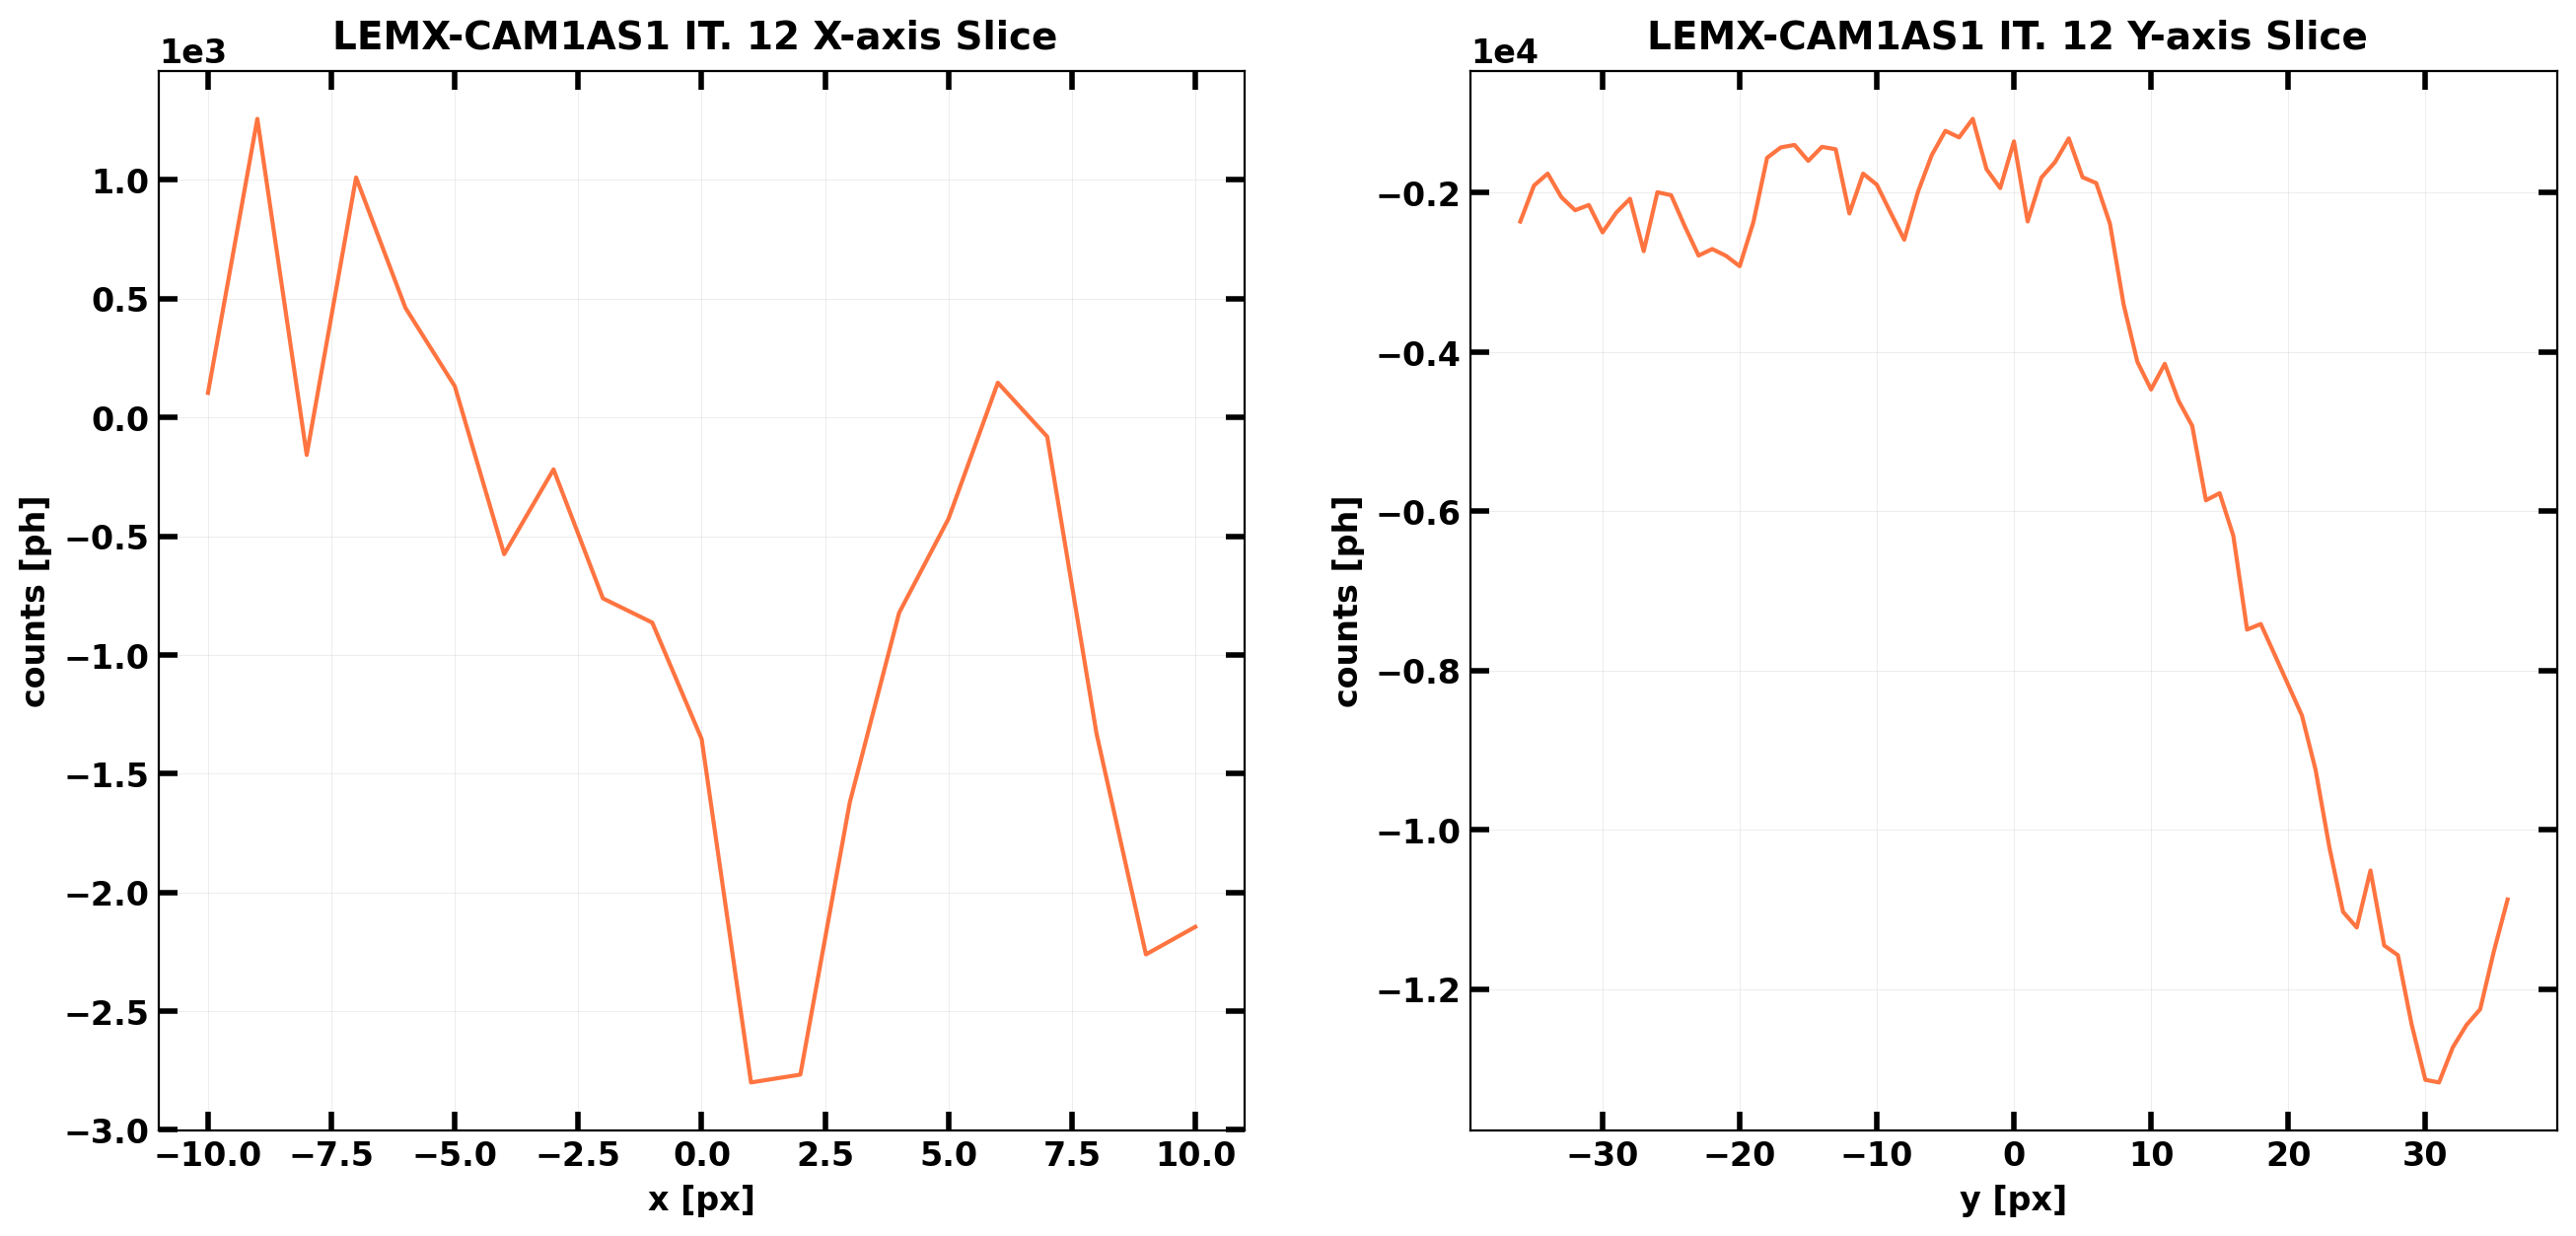

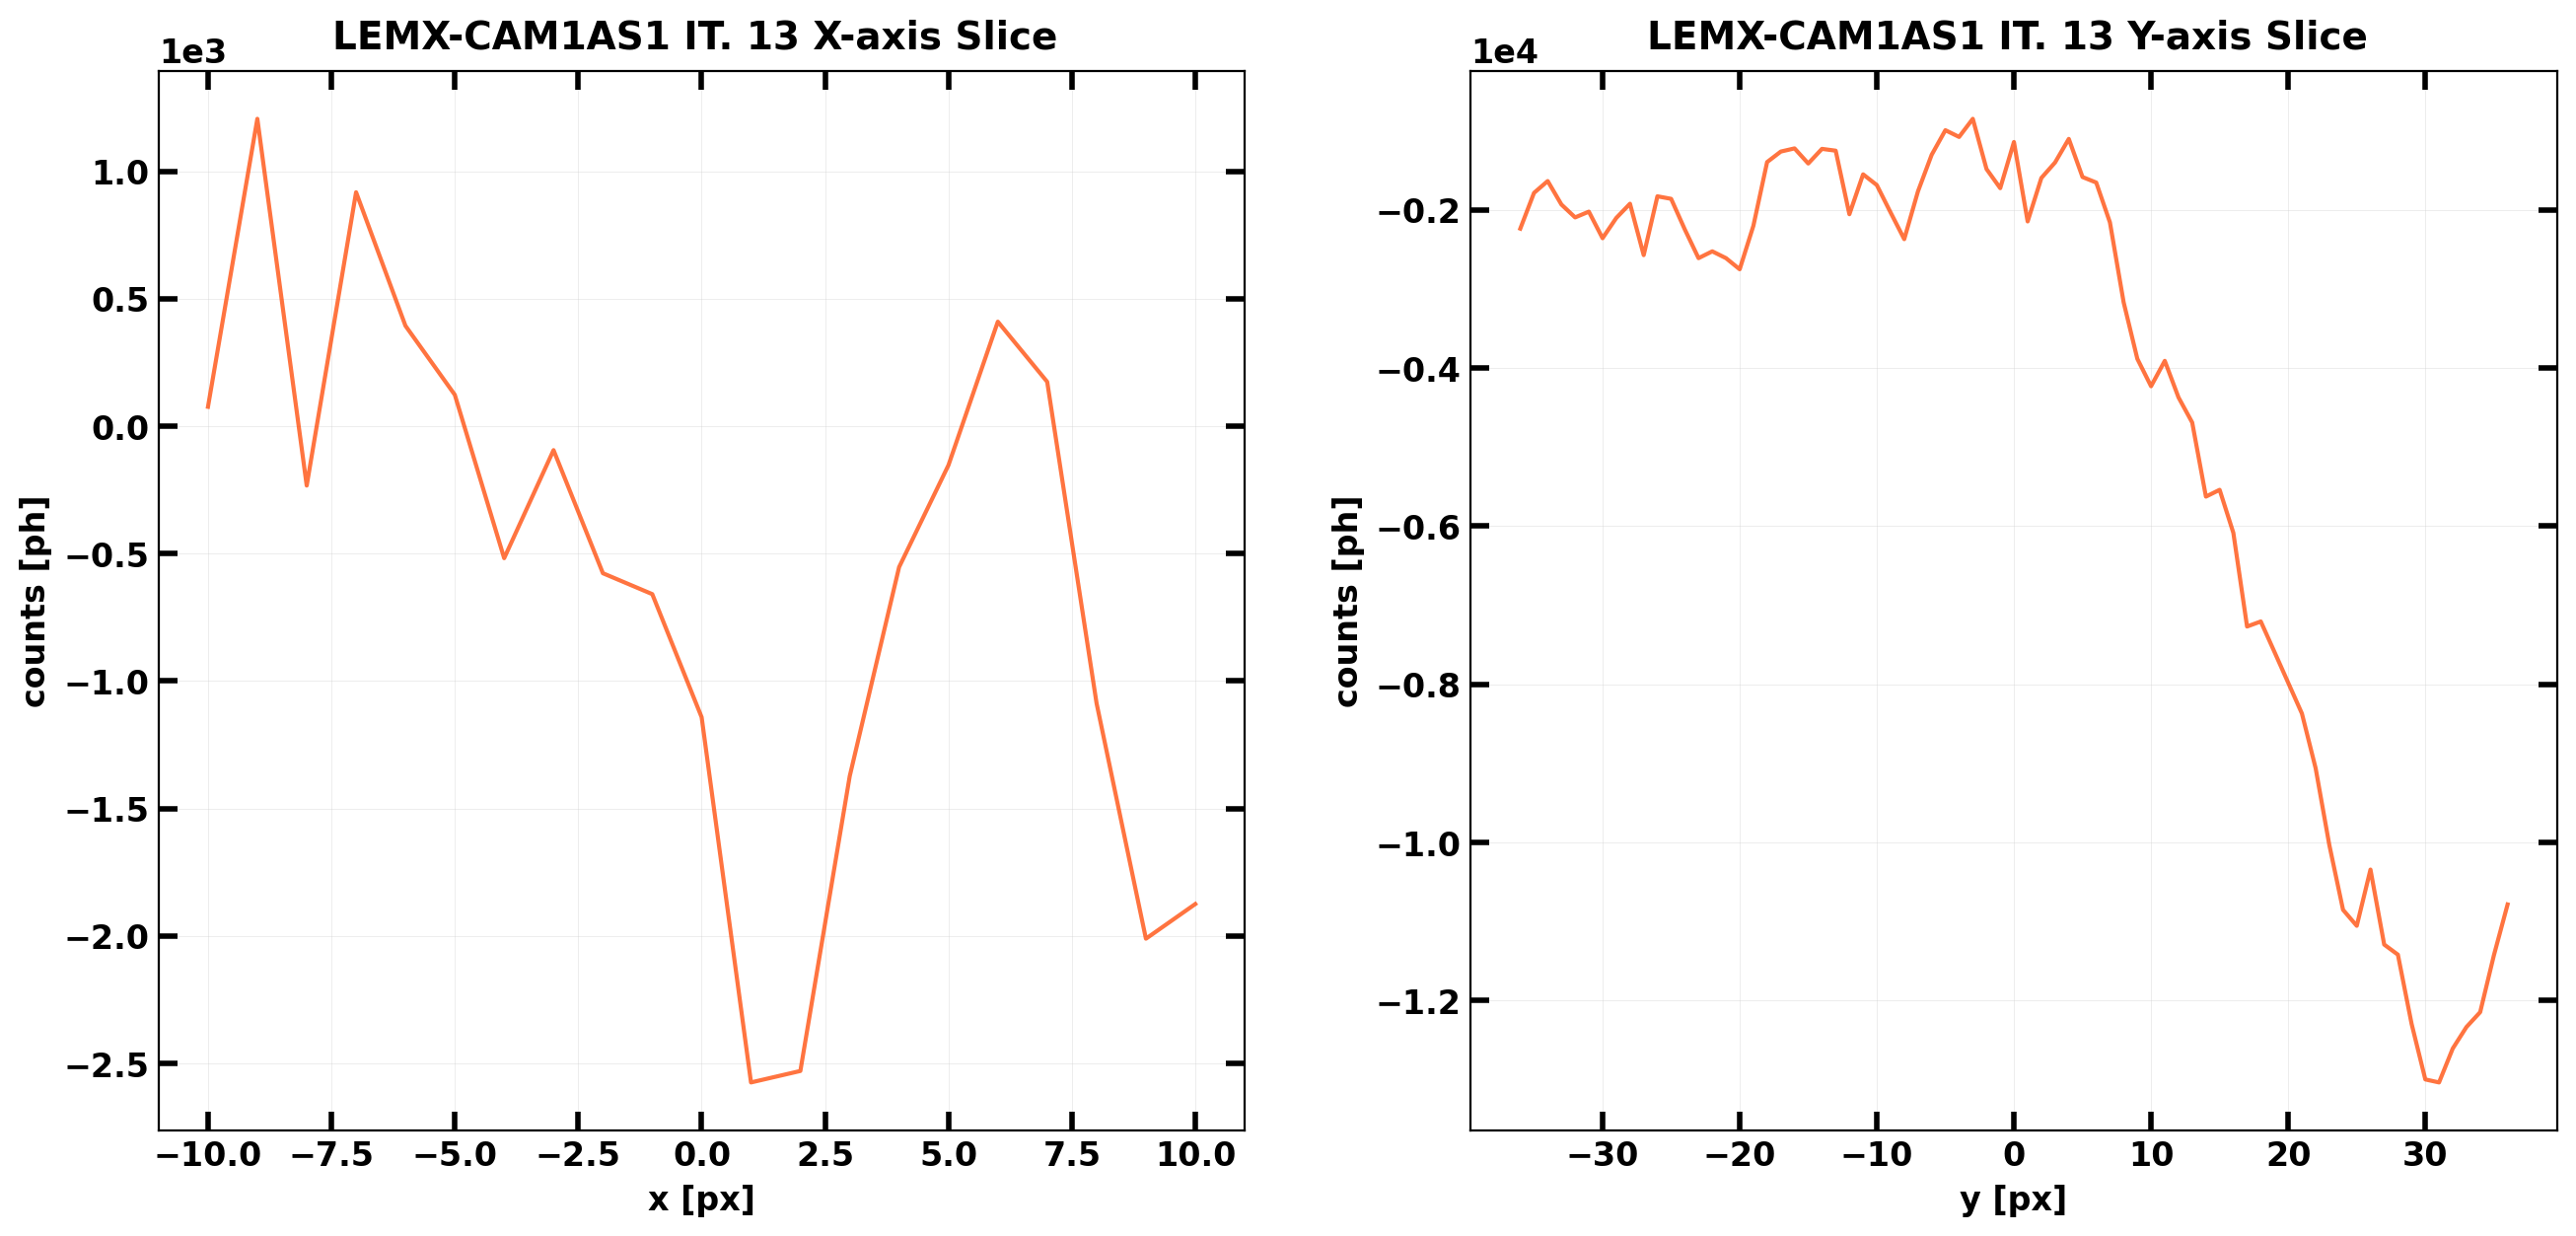

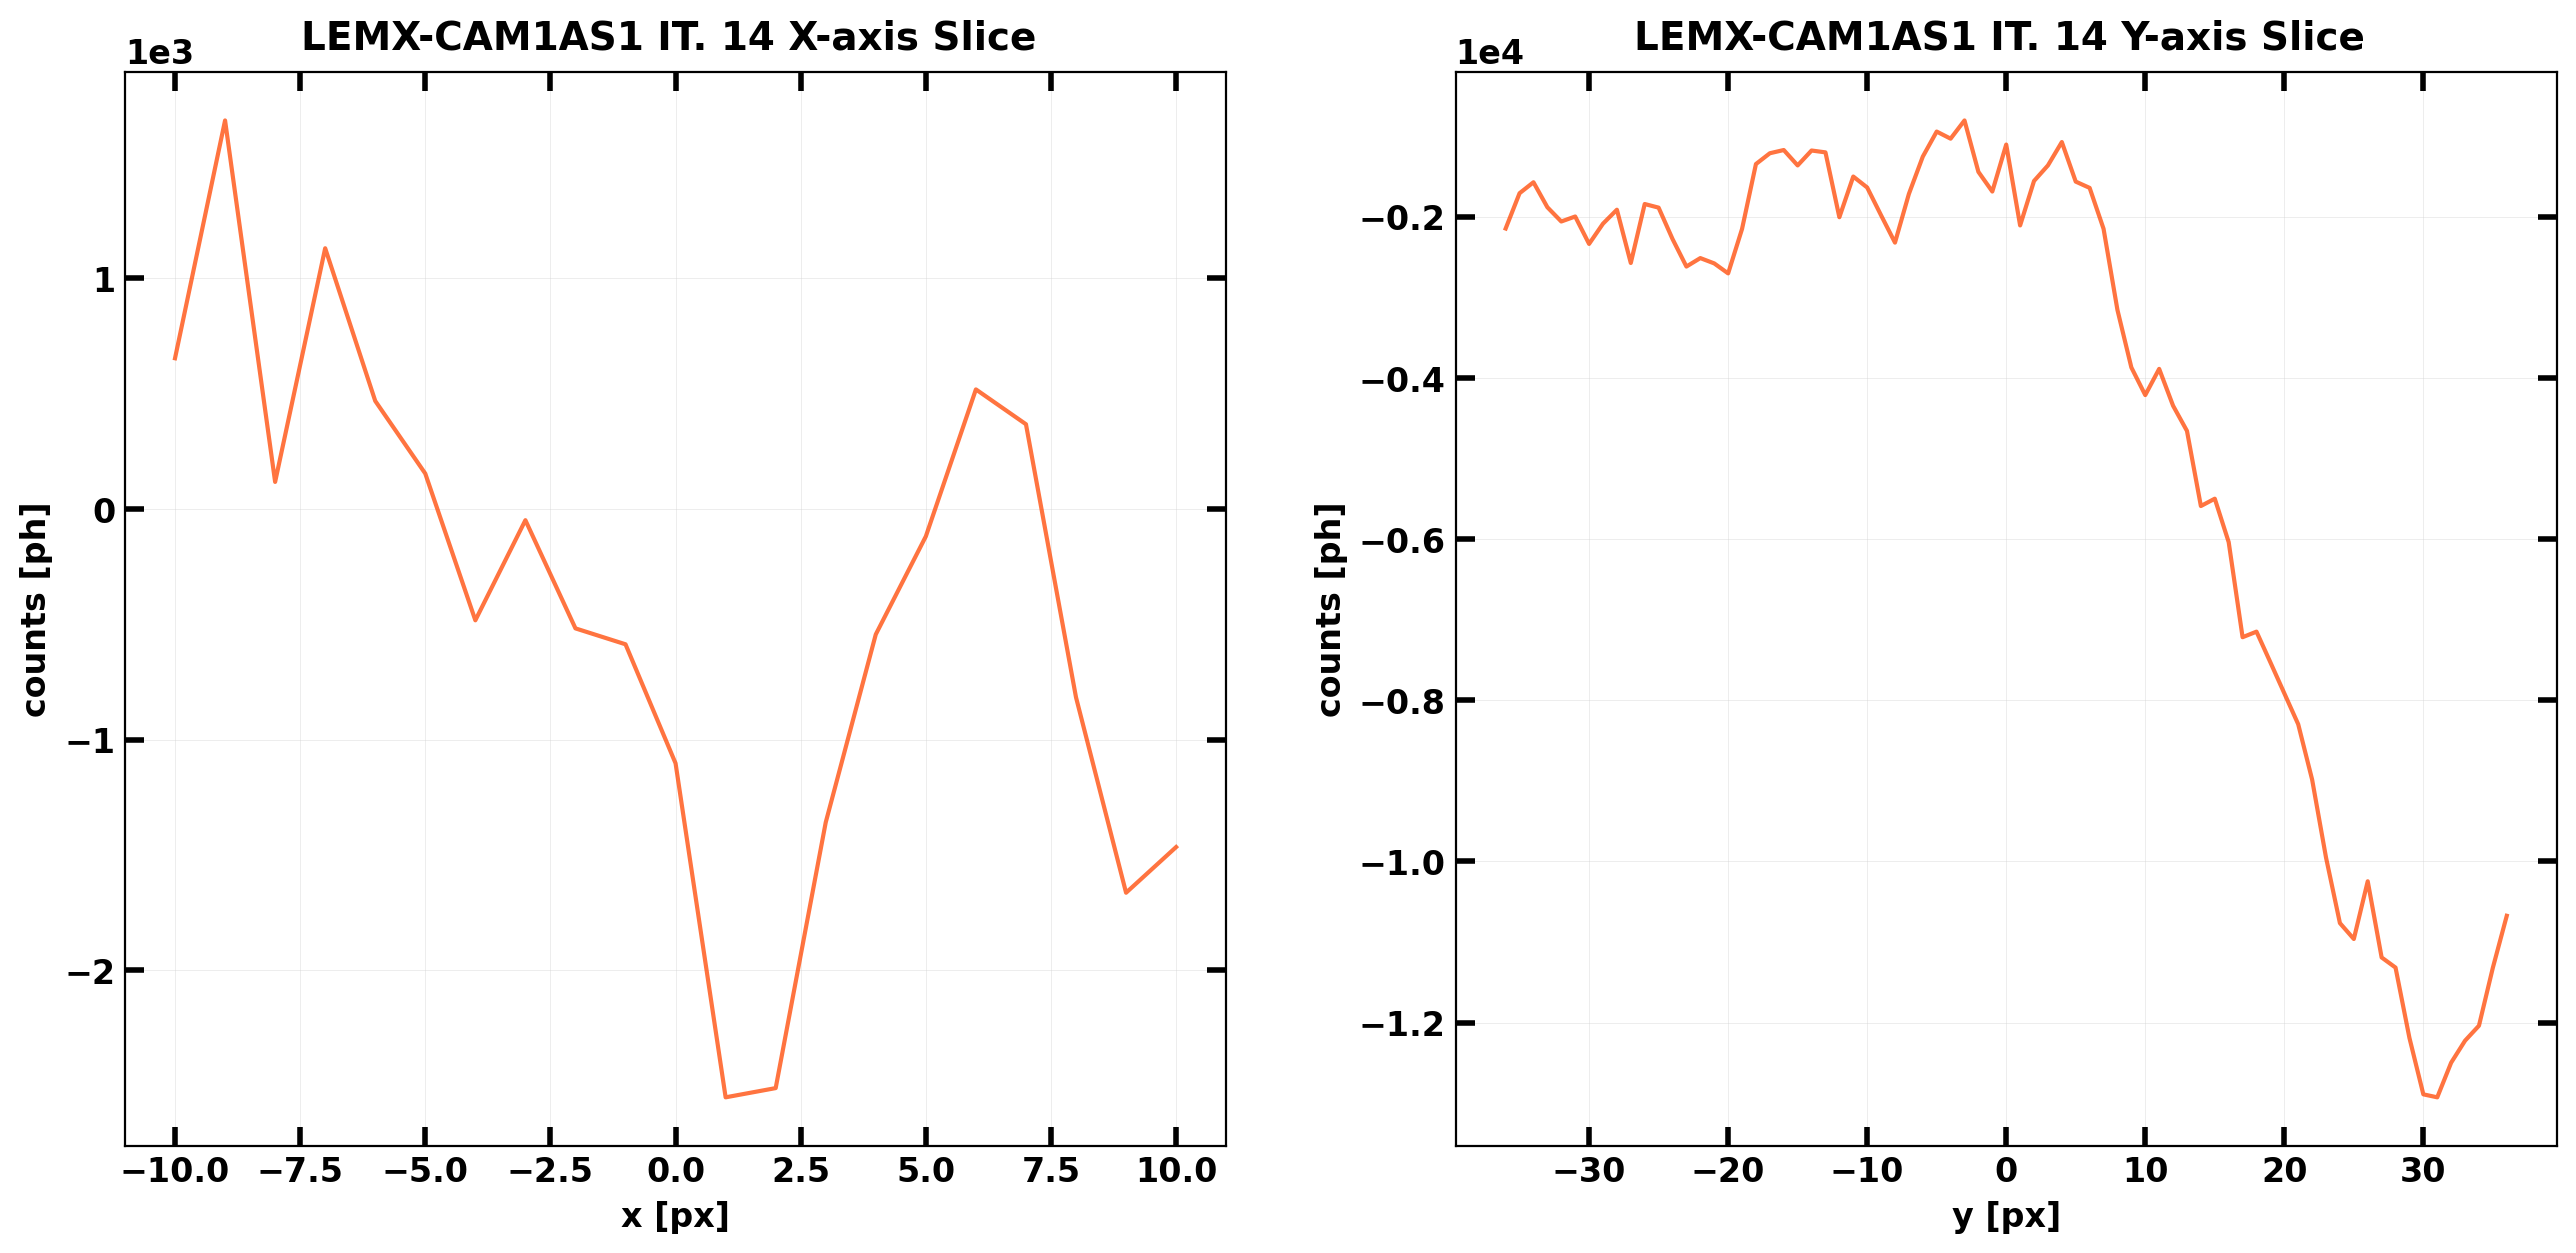

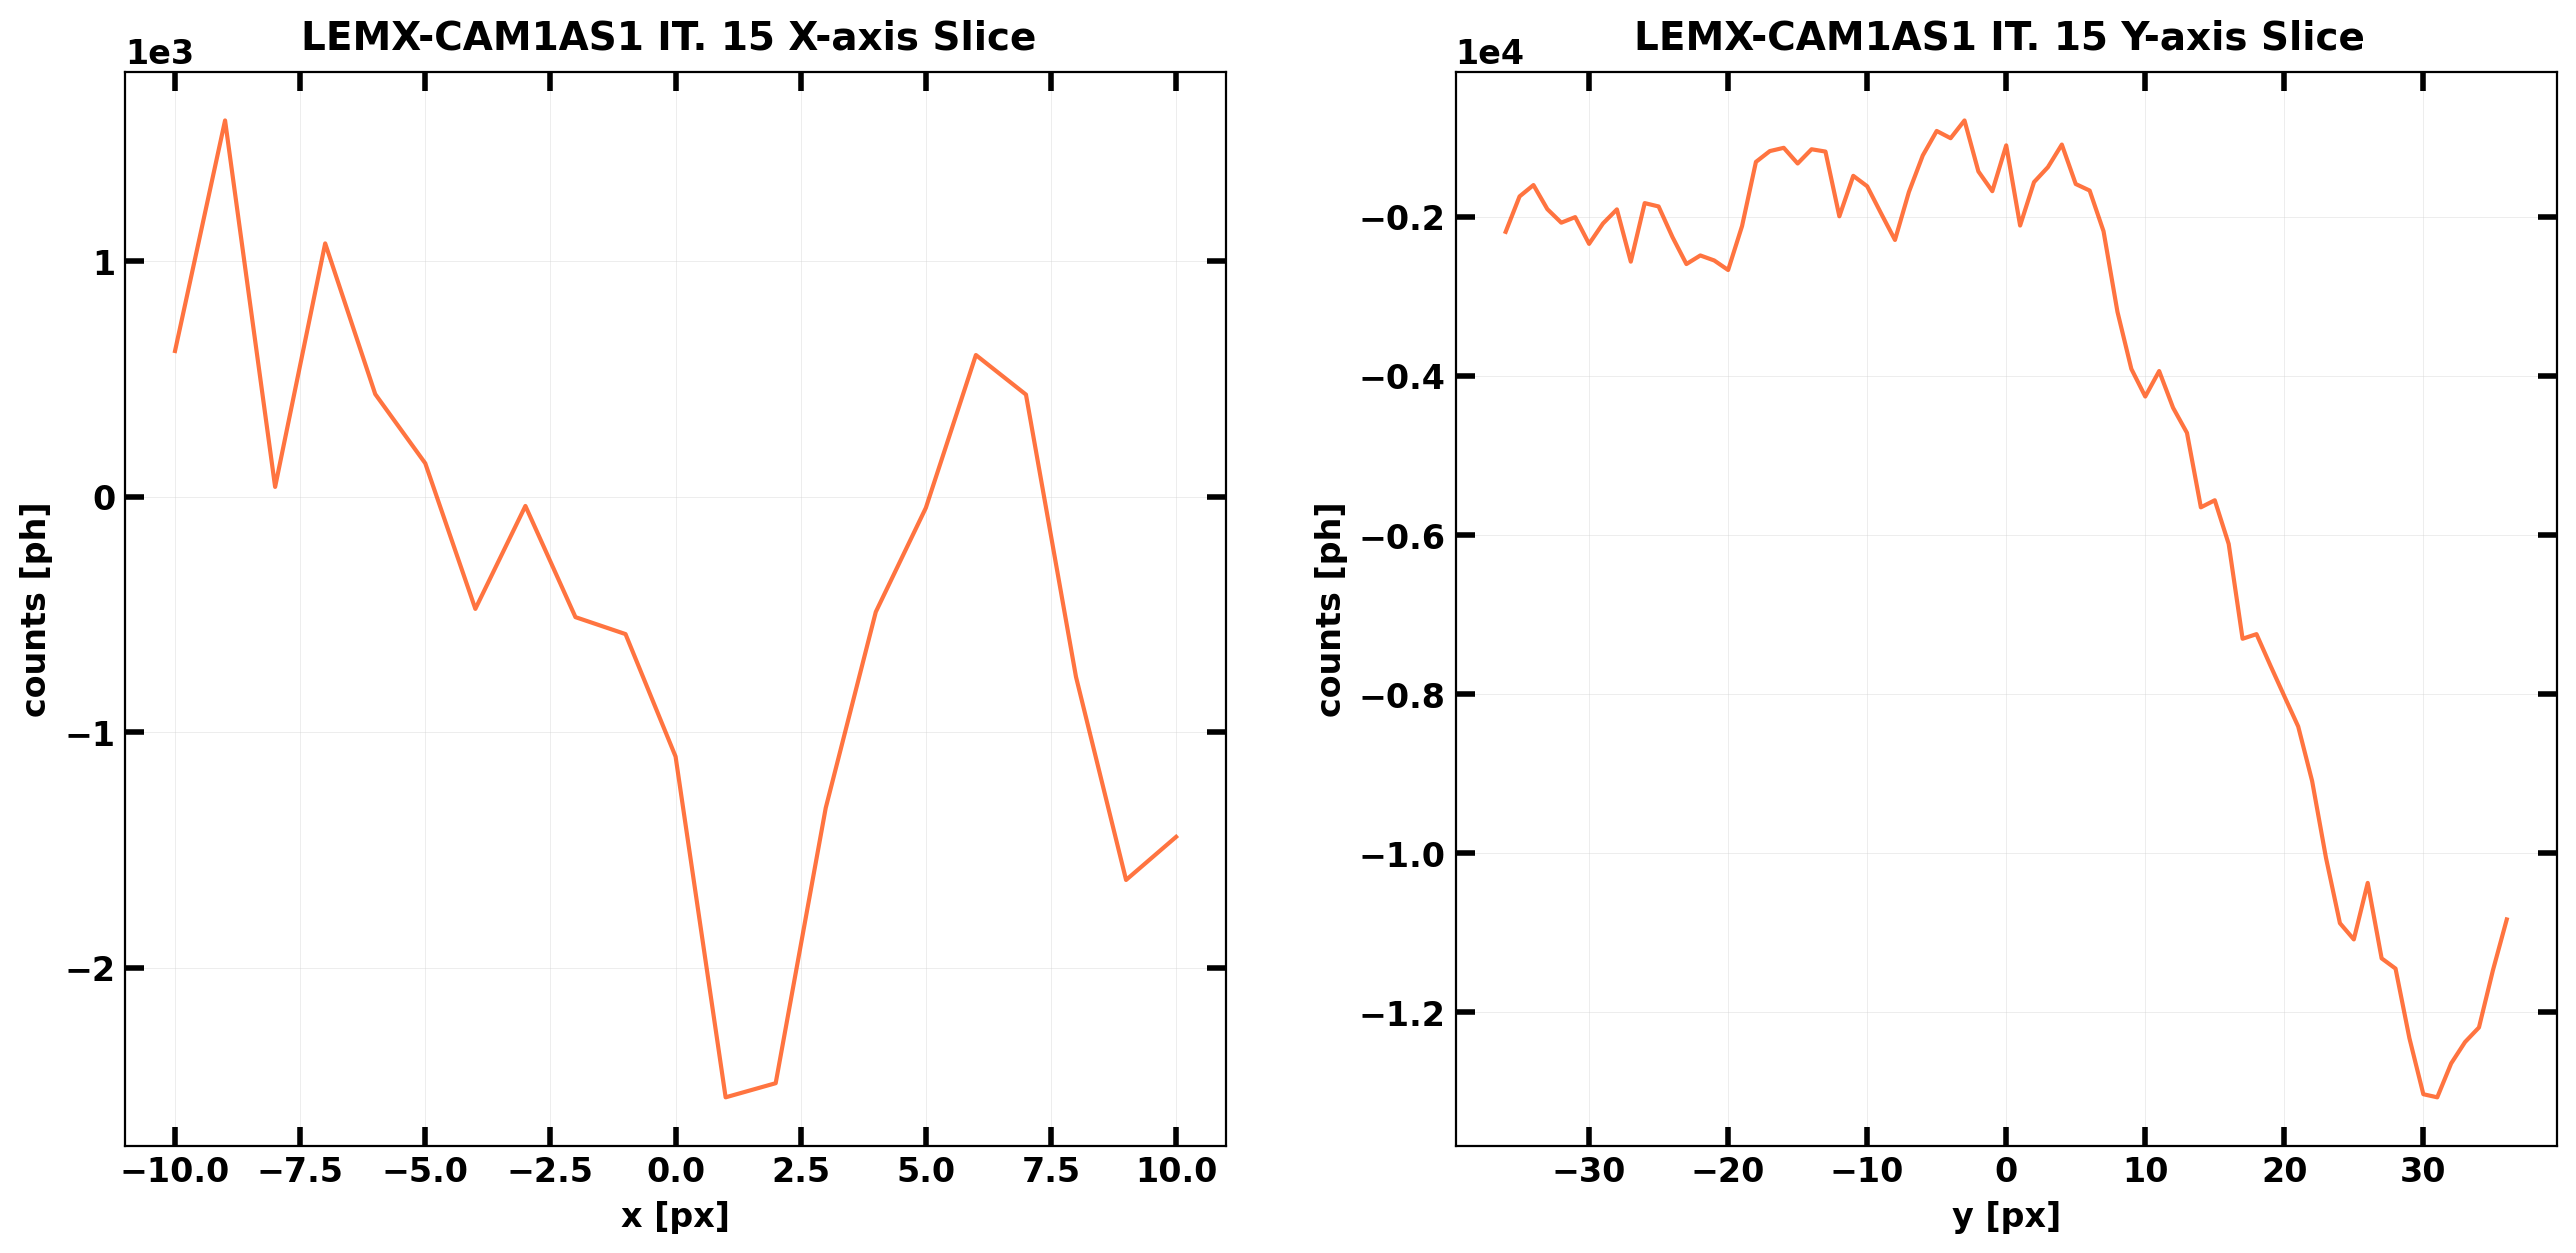

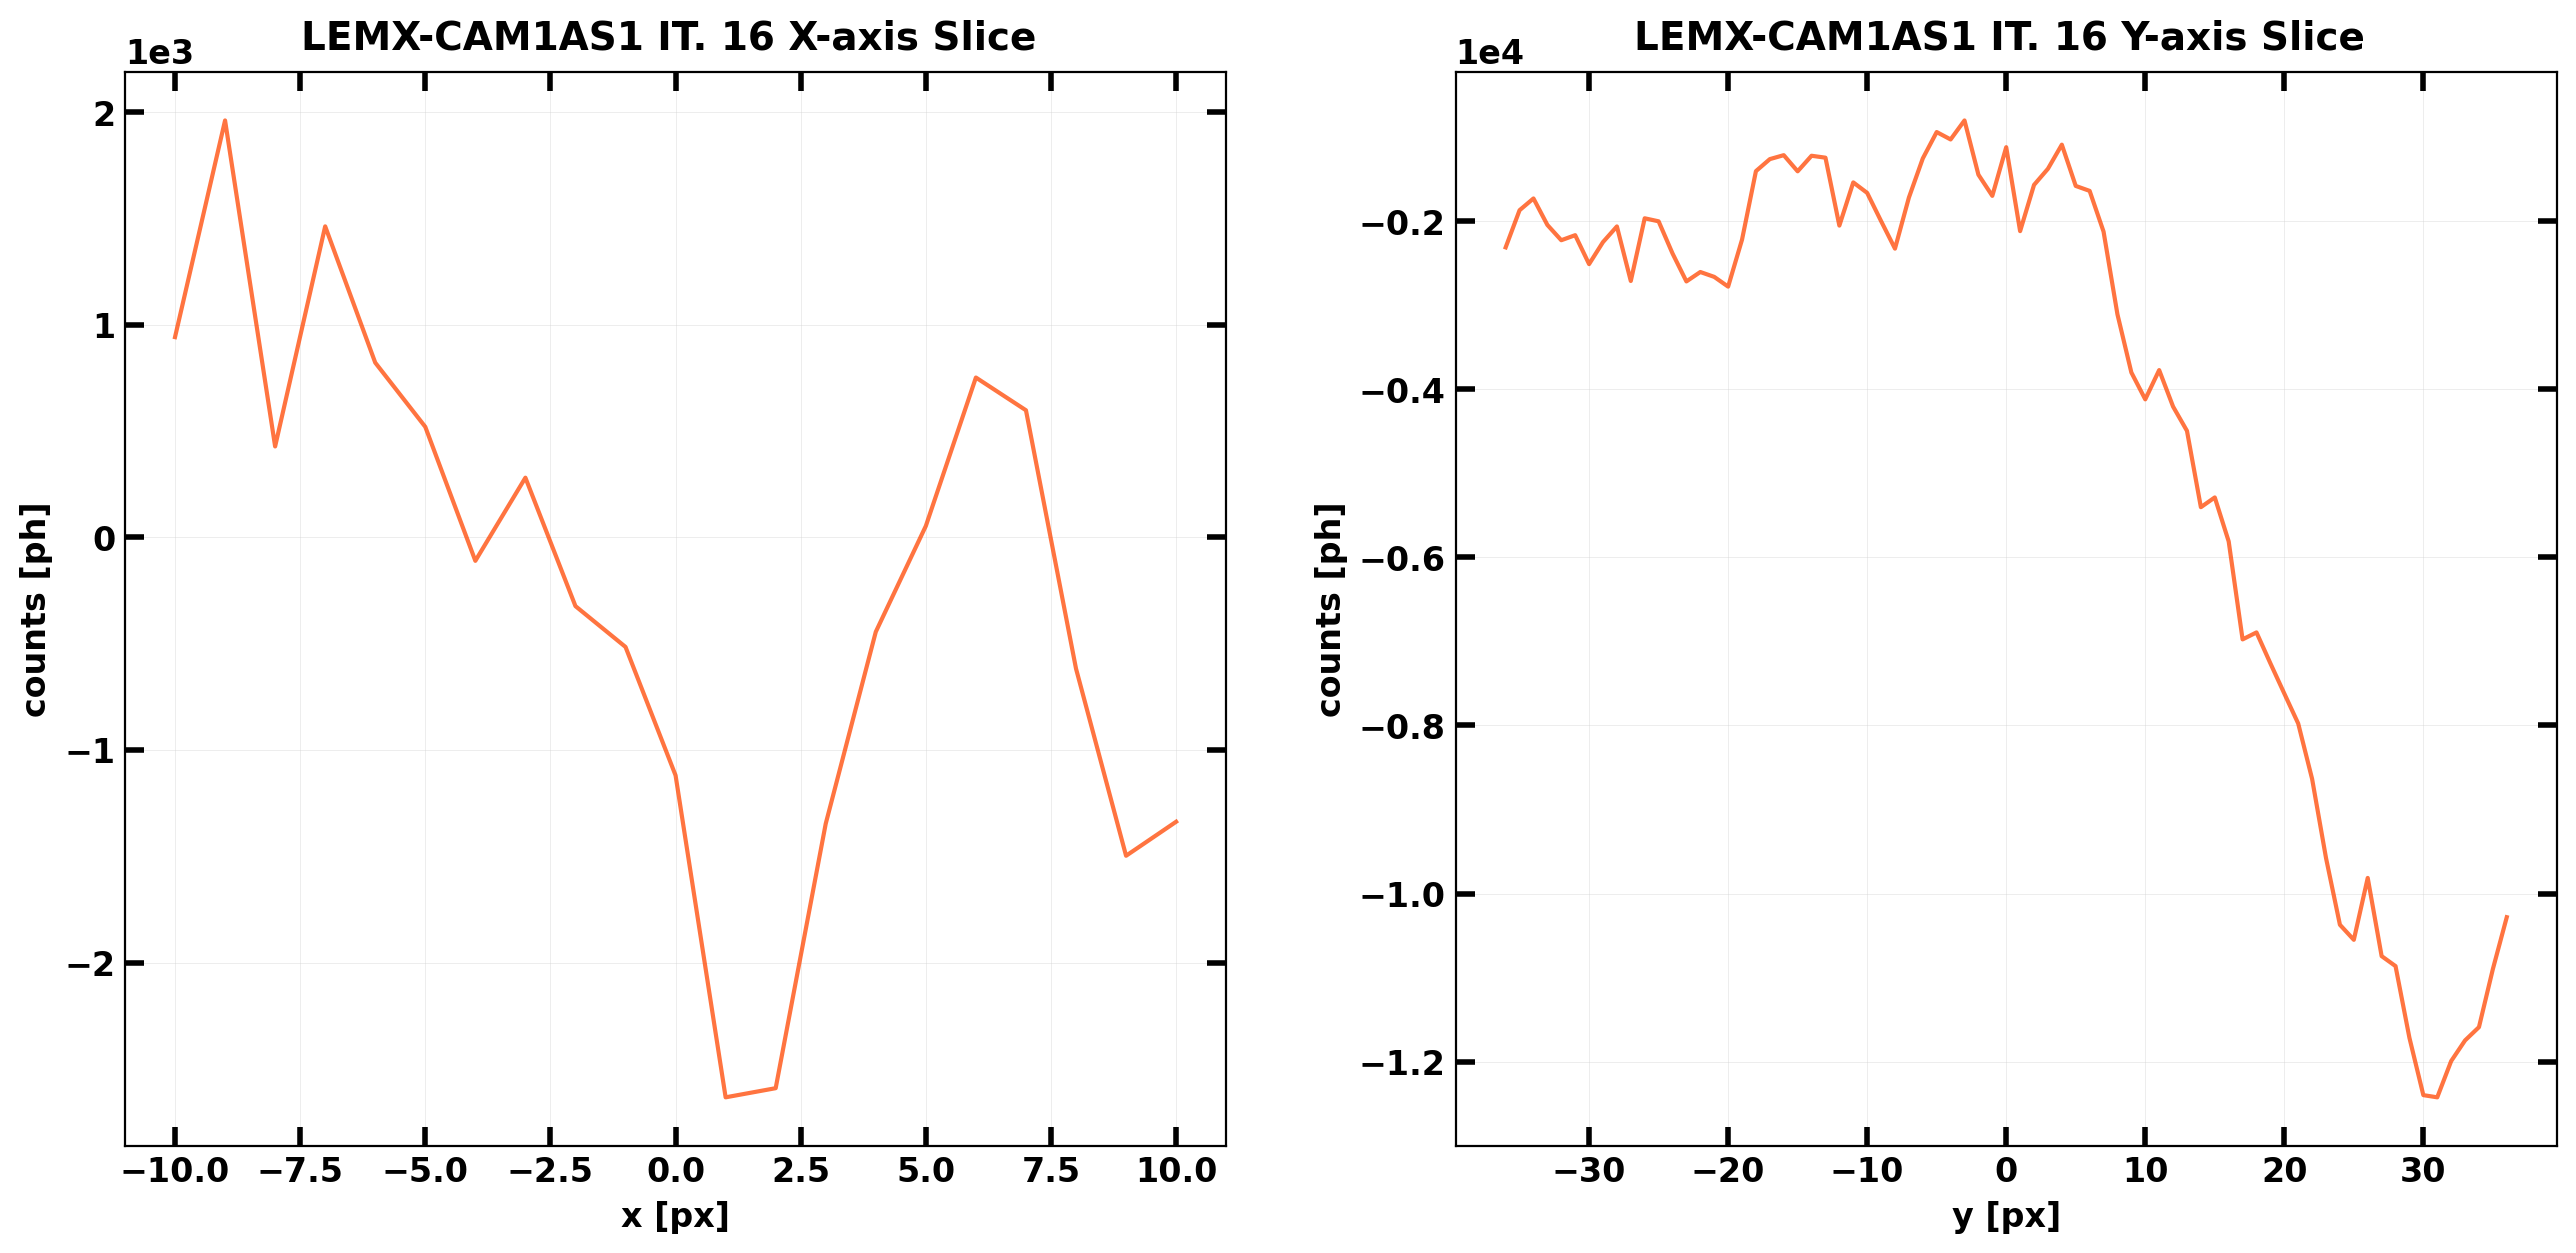

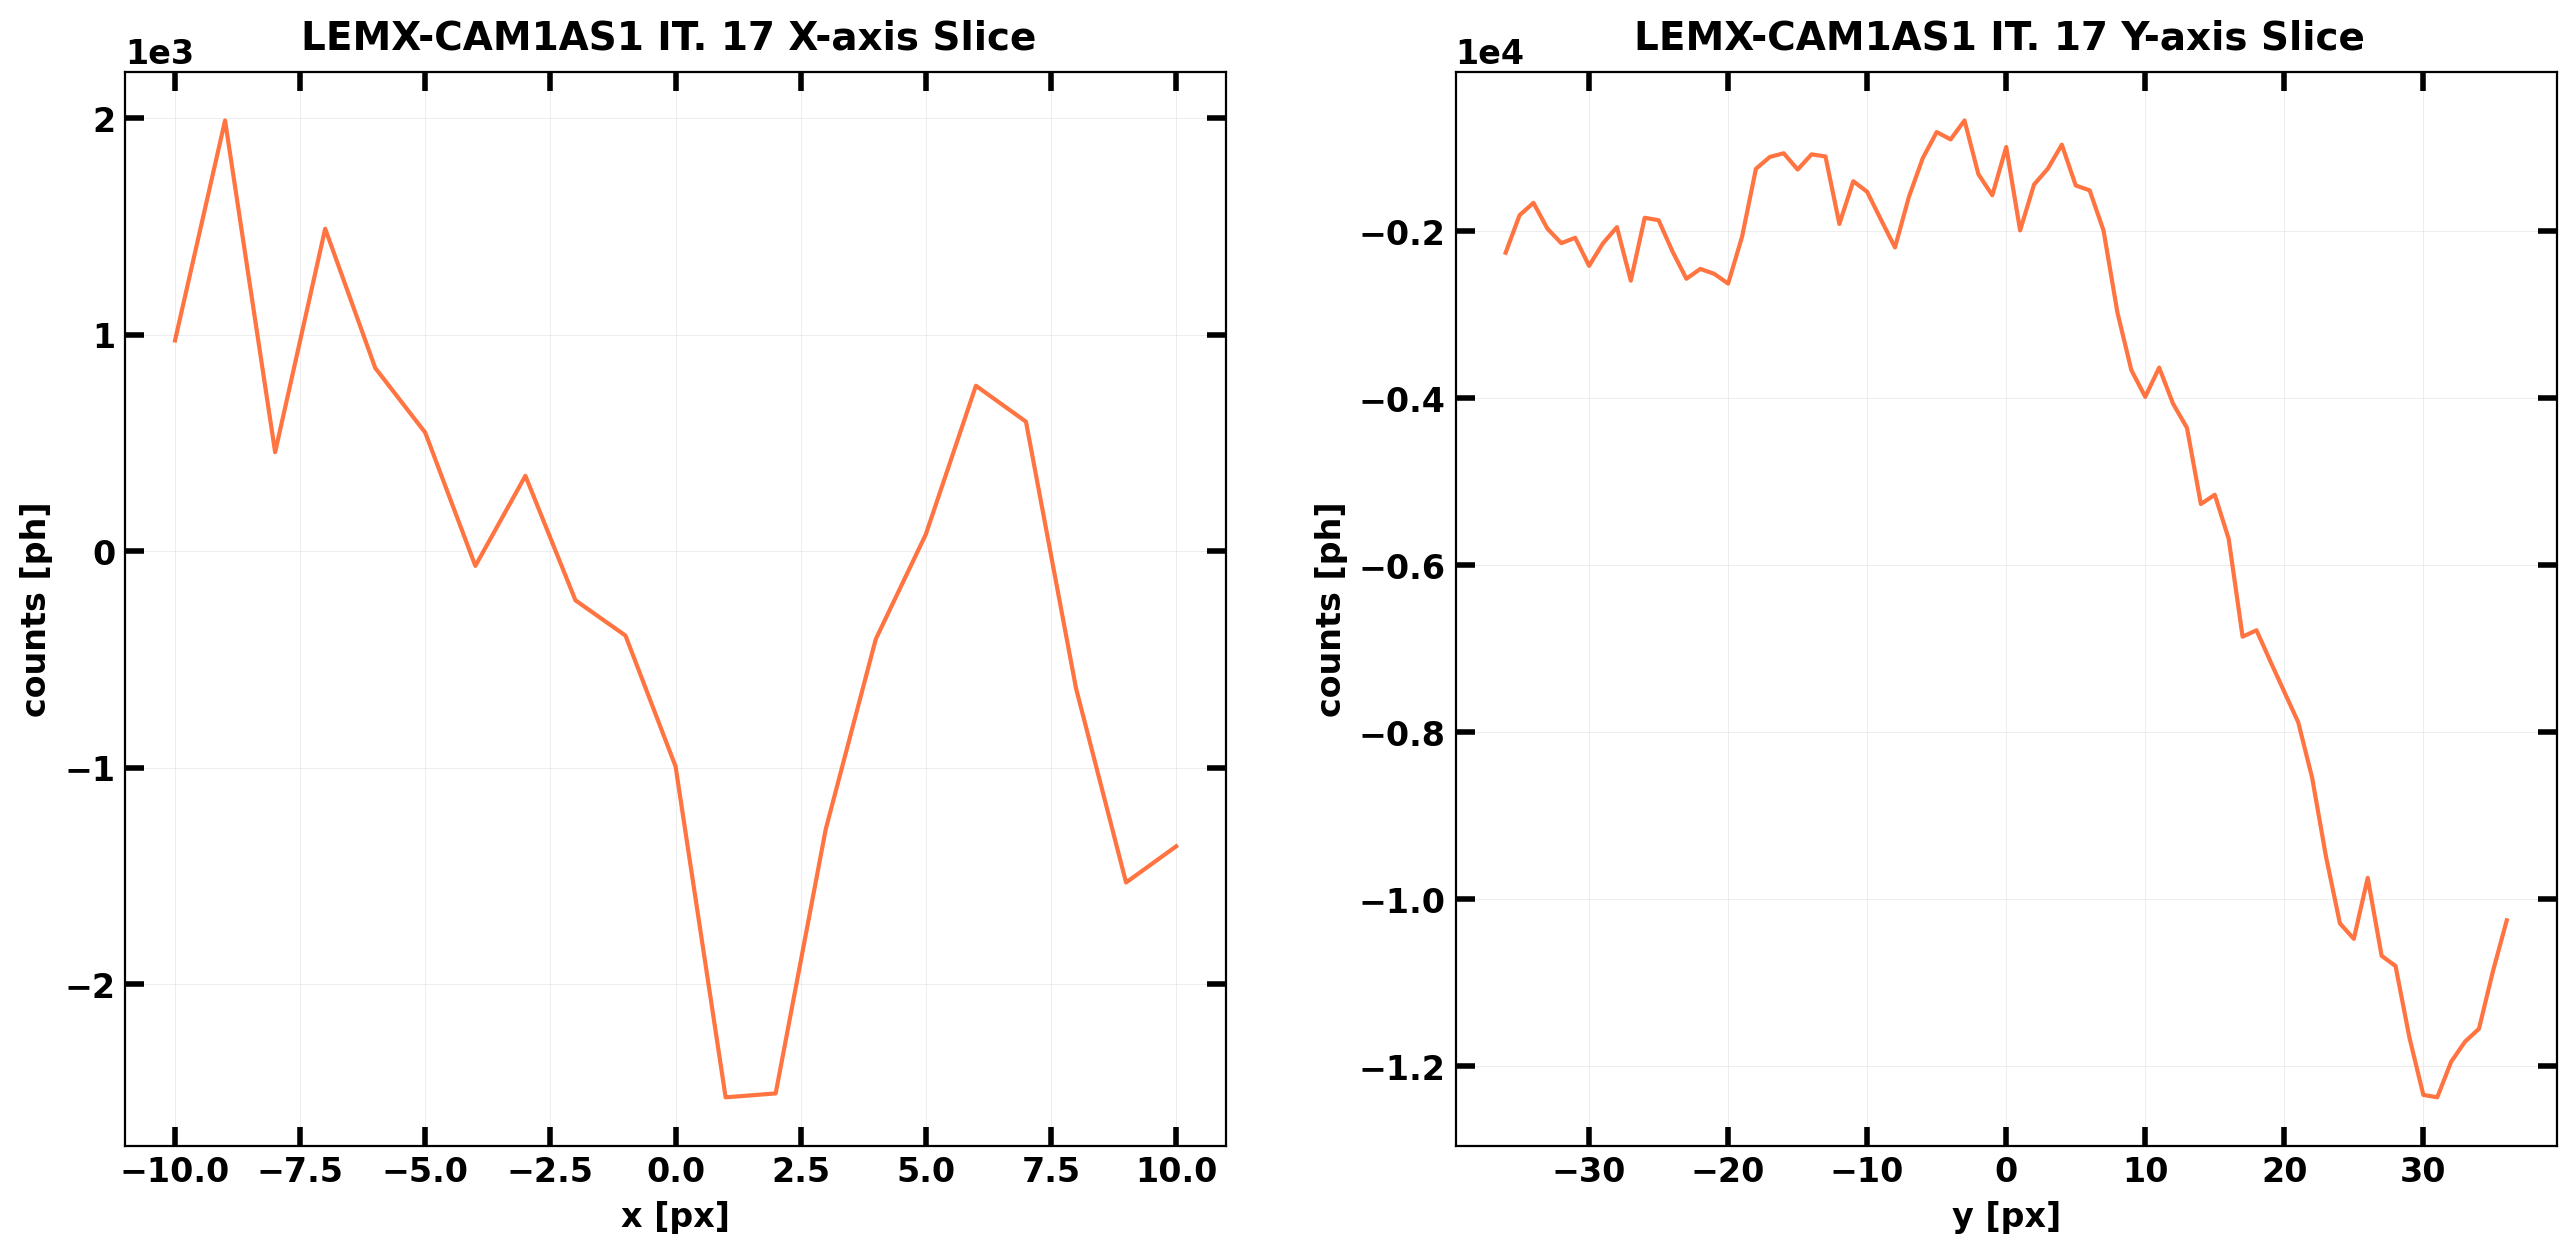

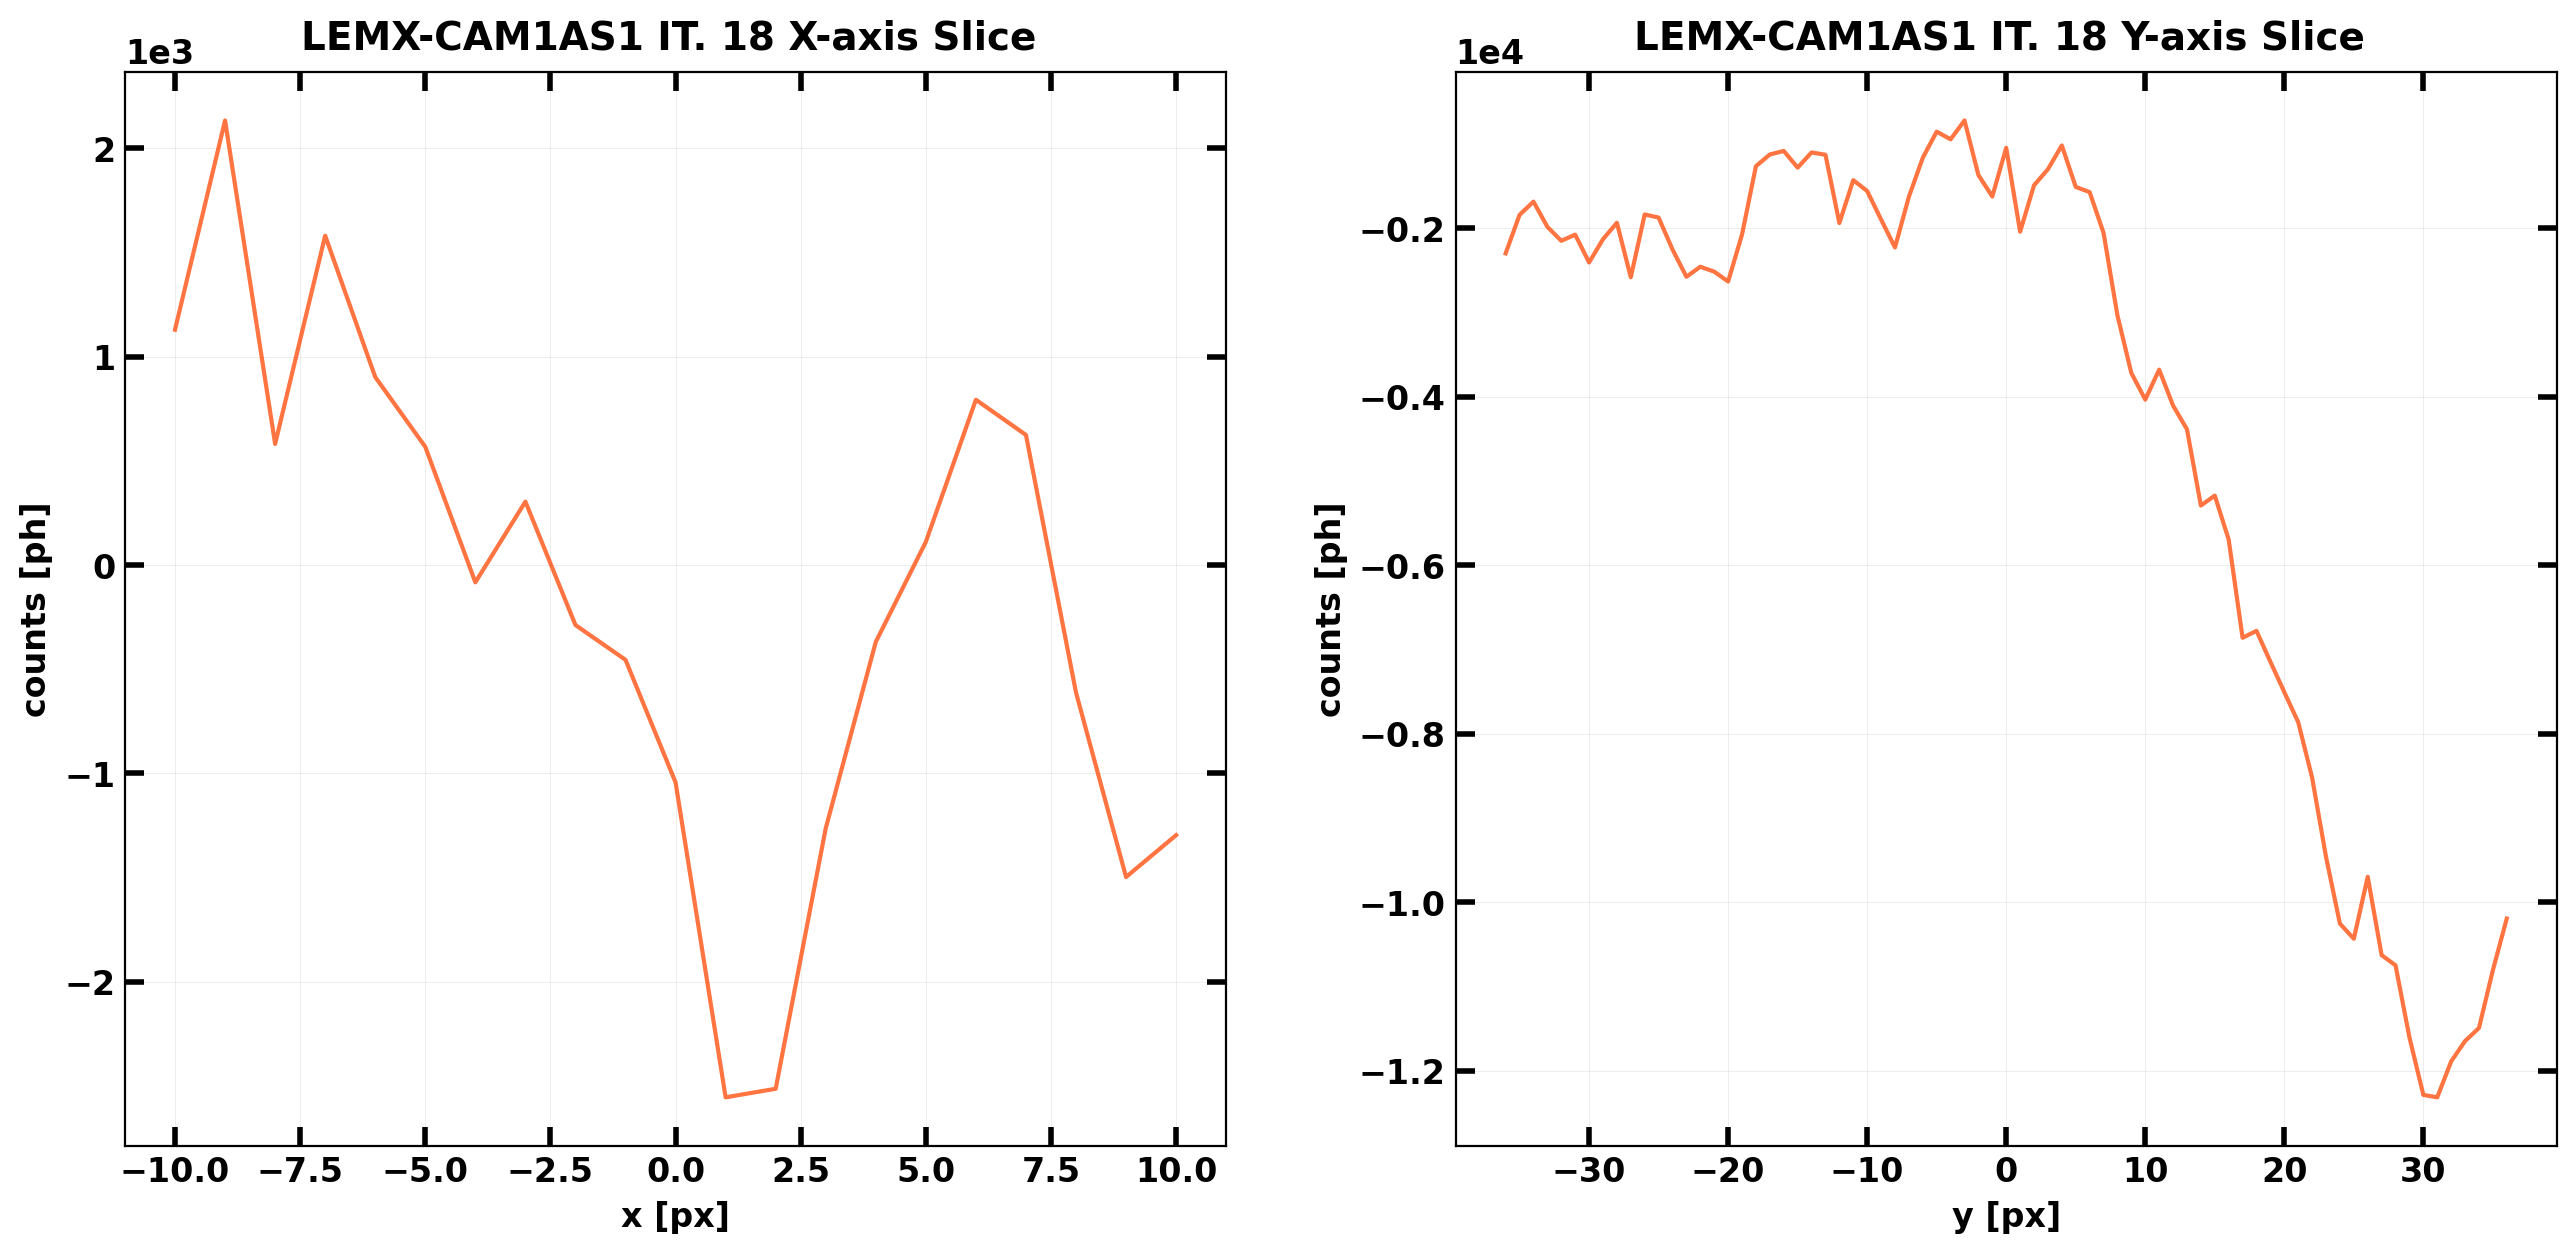

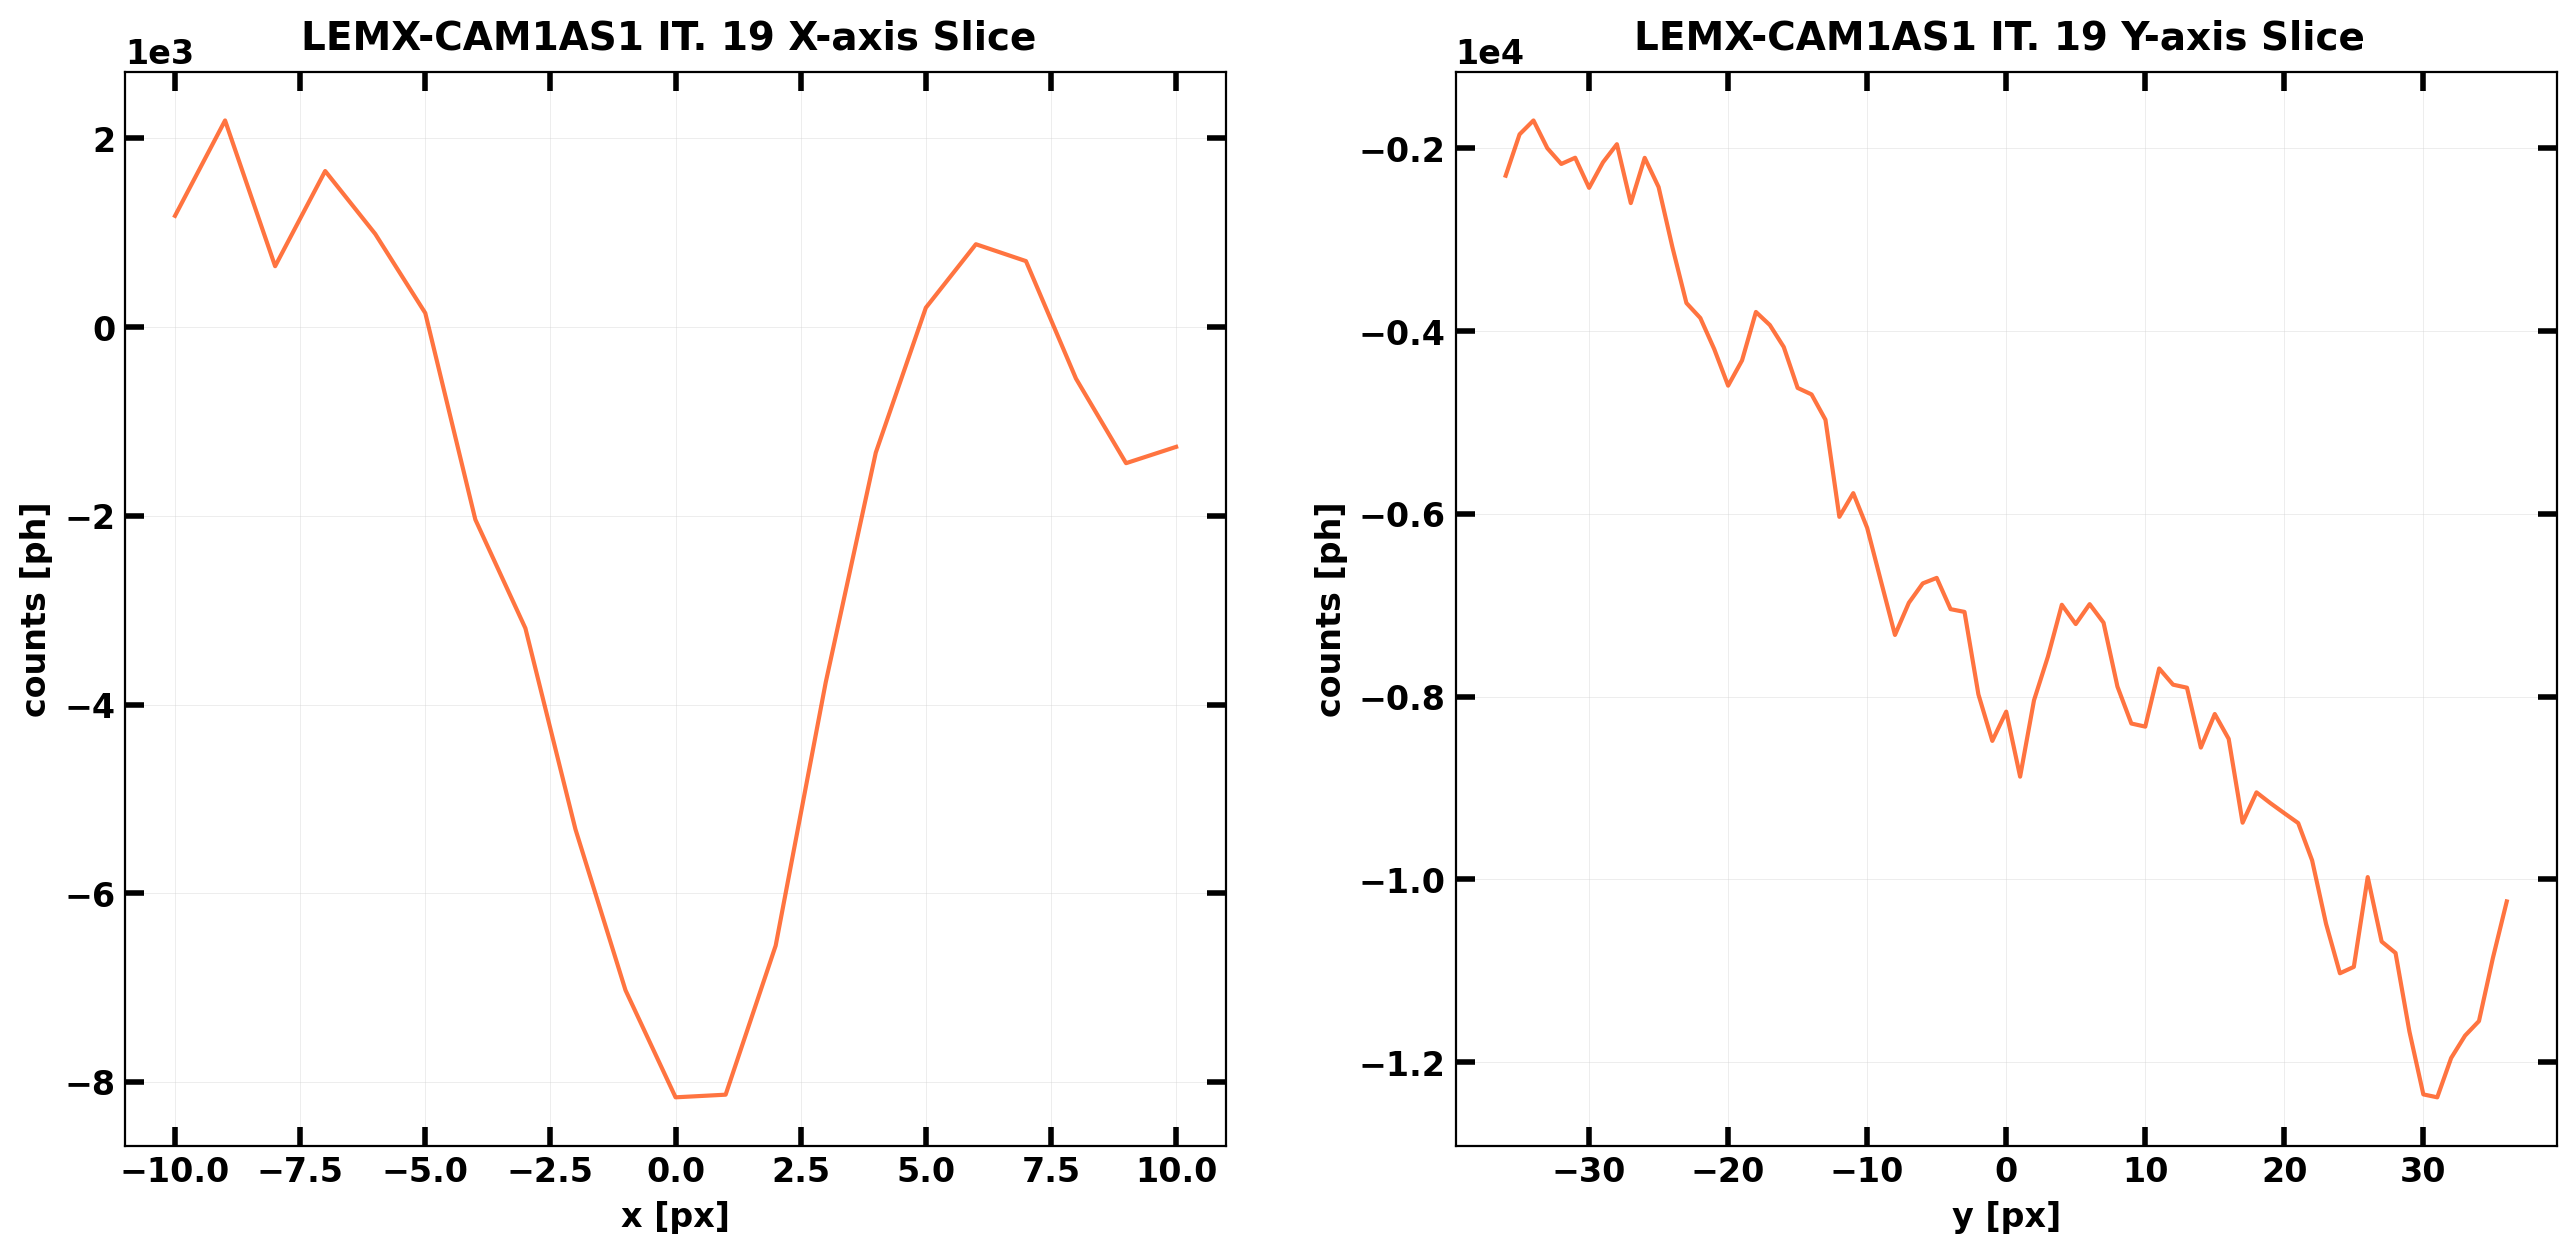

In [5]:
source_profile_during_IROS(
    candidates=candidates,
    true_sky=simul_sky_camA,
    variance=varmap,
    lock_source=locked_sources[1],
    crp=(cropy, cropx),
    camera=wfm,
    vignetting=VIGNETTING,
    psfy=PSFY,
)